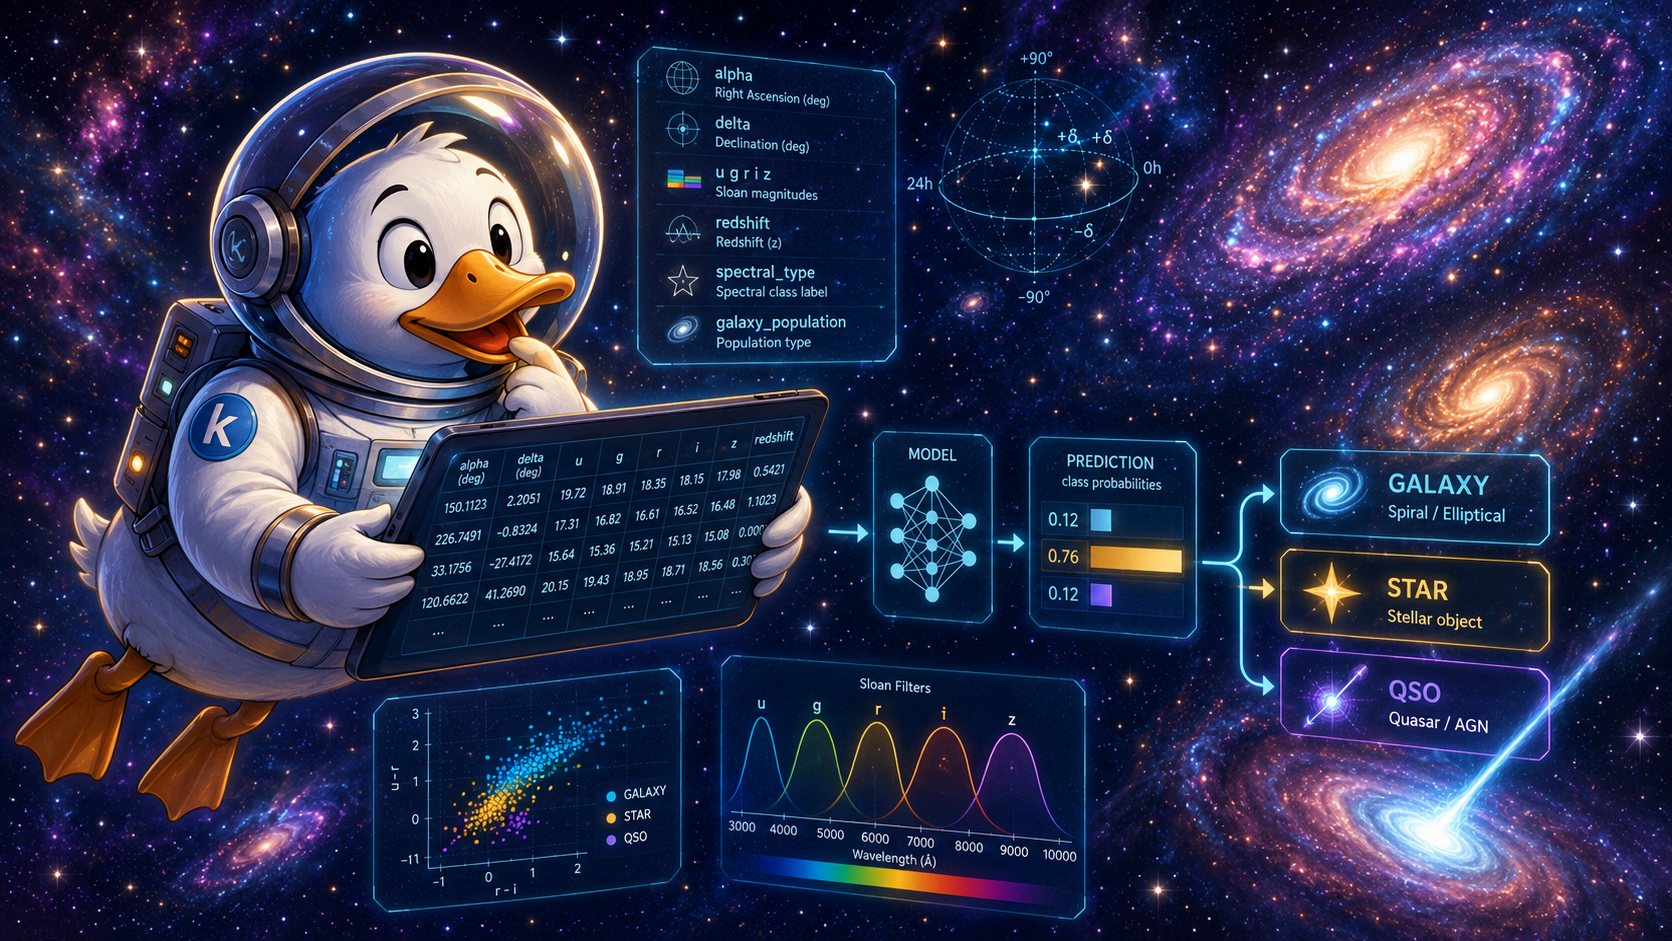

In [1]:
from pathlib import Path
from IPython.display import Image, display

cover_image_path = Path("/kaggle/input/datasets/pilkwang/pilkwang-public-dataset-for-notebooks-figures/S6E6_main.png")
if cover_image_path.exists():
    display(Image(filename=str(cover_image_path)))

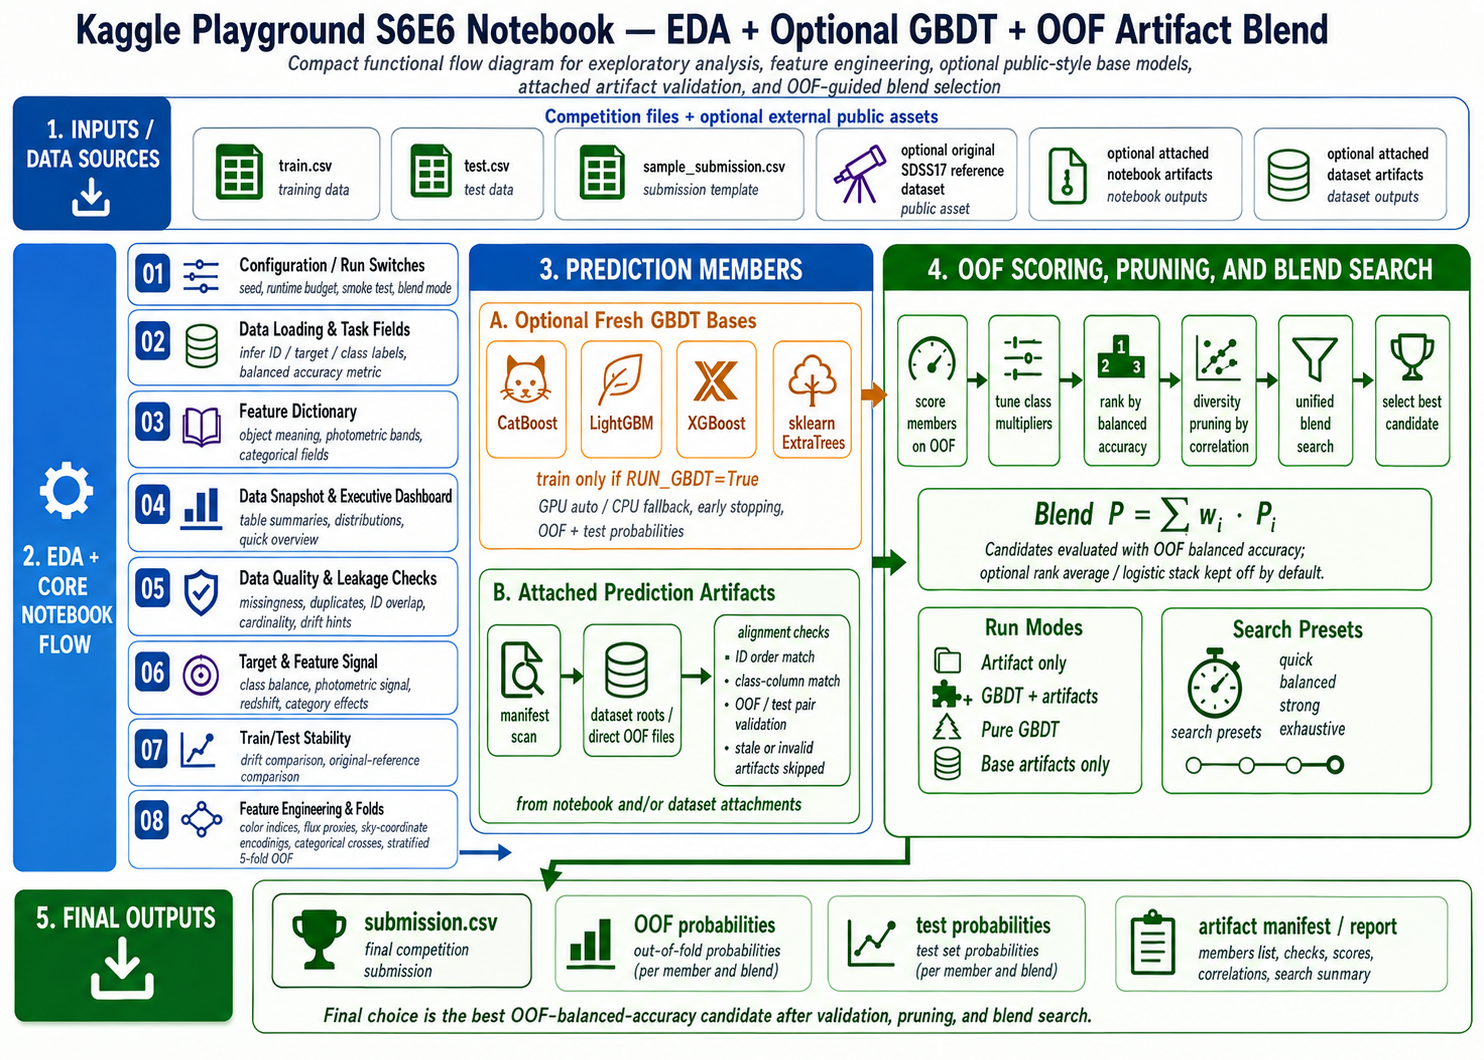

In [2]:
from pathlib import Path
from IPython.display import Image, display

cover_image_path = Path("/kaggle/input/datasets/pilkwang/pilkwang-public-dataset-for-notebooks-figures/S6E6_map.png")
if cover_image_path.exists():
    display(Image(filename=str(cover_image_path)))

<div style="background: linear-gradient(135deg, #F7F3EA 0%, #EEF4ED 100%); border: 1px solid #D9D0BF; border-radius: 18px; padding: 22px 24px; margin-bottom: 18px; box-shadow: 0 12px 30px rgba(35, 49, 39, 0.06); color: #233127;">
  <div style="font-size: 11px; letter-spacing: 0.14em; text-transform: uppercase; color: #7A6045; font-weight: 800; margin-bottom: 8px;">Kaggle Playground Series S6E6</div>
  <div style="margin: 0 0 8px 0; color: #233127; font-size: 2.05rem; font-weight: 900; line-height: 1.14;">Stellar Object Classification</div>
  <div style="margin: 0 0 15px 0; color: #4C5A4C; font-size: 15px; line-height: 1.6; max-width: 960px;">
    Stellar classes are separated through photometric bands, color indices, redshift behavior, sky position, and categorical population fields. The prediction section keeps the same GBDT and attached-artifact blend logic, with final choice based on OOF balanced accuracy.
  </div>
  <div style="display: grid; grid-template-columns: repeat(auto-fit, minmax(205px, 1fr)); gap: 10px; margin-bottom: 14px;">
    <div style="background: rgba(255,255,255,0.90); border: 1px solid #E4DAC9; border-radius: 14px; padding: 12px 14px;">
      <div style="font-size: 11px; text-transform: uppercase; color: #6F7C69; font-weight: 900; letter-spacing: 0.08em; margin-bottom: 6px;">Target</div>
      <div style="font-size: 15px; color: #233127; font-weight: 800; line-height: 1.35;"><span style="display: inline-block; padding: 1px 7px; margin: 0 1px; border-radius: 8px; background: #233127; color: #F7F3EA; border: 1px solid #D9D0BF; font-size: 0.92em; font-weight: 900; line-height: 1.45; white-space: nowrap;">GALAXY / QSO / STAR</span></div>
    </div>
    <div style="background: rgba(255,255,255,0.90); border: 1px solid #E4DAC9; border-radius: 14px; padding: 12px 14px;">
      <div style="font-size: 11px; text-transform: uppercase; color: #6F7C69; font-weight: 900; letter-spacing: 0.08em; margin-bottom: 6px;">Validation</div>
      <div style="font-size: 15px; color: #233127; font-weight: 800; line-height: 1.35;">Stratified OOF probabilities</div>
    </div>
    <div style="background: rgba(255,255,255,0.90); border: 1px solid #E4DAC9; border-radius: 14px; padding: 12px 14px;">
      <div style="font-size: 11px; text-transform: uppercase; color: #6F7C69; font-weight: 900; letter-spacing: 0.08em; margin-bottom: 6px;">Metric</div>
      <div style="font-size: 15px; color: #233127; font-weight: 800; line-height: 1.35;">Balanced accuracy with class-recall checks</div>
    </div>
    <div style="background: rgba(255,255,255,0.90); border: 1px solid #E4DAC9; border-radius: 14px; padding: 12px 14px;">
      <div style="font-size: 11px; text-transform: uppercase; color: #6F7C69; font-weight: 900; letter-spacing: 0.08em; margin-bottom: 6px;">Model Set</div>
      <div style="font-size: 15px; color: #233127; font-weight: 800; line-height: 1.35;">GBDT bases plus aligned OOF artifacts</div>
    </div>
  </div>
</div>

Primary selection statistic:

$$
\hat{c}=\arg\max_{c\in\mathcal{C}} \operatorname{BalancedAccuracy}_{OOF}(c)
$$

Secondary checks are log loss, macro-F1, fold dispersion, model diversity, and submission-row sanity checks.


<style>
/* Kaggle/Jupyter themes can leak a light-text color into markdown HTML tables and pandas outputs. */
.rendered_html table,
.rendered_html table th,
.rendered_html table td,
.jp-RenderedHTMLCommon table,
.jp-RenderedHTMLCommon table th,
.jp-RenderedHTMLCommon table td,
.dataframe,
.dataframe th,
.dataframe td {
  color: #233127 !important;
}
.rendered_html table,
.jp-RenderedHTMLCommon table,
.dataframe {
  background-color: #FFFCF8 !important;
}
.rendered_html table th,
.jp-RenderedHTMLCommon table th,
.dataframe th {
  background-color: #F2F3F1 !important;
  color: #233127 !important;
}
.rendered_html table td,
.jp-RenderedHTMLCommon table td,
.dataframe td {
  background-color: #FFFCF8 !important;
  color: #233127 !important;
}
</style>


## 1. Configuration

Runtime settings fix data roots, attached artifact roots, model budget, fold count, device policy, and output paths.

In [3]:
from __future__ import annotations

import gc
import json
import math
import os
import platform
import random
import subprocess
import time
import warnings
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, Markdown, display

from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy, ks_2samp, wasserstein_distance

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score, log_loss, recall_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight

### 1.1 Run Switches

These switches control the experiment mode: pure GBDT, GBDT plus base artifacts, full artifact blend, or artifact-only blend. Edit the assignments in the next cell before running.

In [4]:
# Edit this cell before running.
# Values are written as plain assignments so the active experiment mode is visible.

# Reproducibility and runtime mode.
SEED = 42
SMOKE_TEST = False          # True: quick local check with a small train subset and sklearn only.
TIME_BUDGET_SEC = 7200      # Model blocks are skipped when too little time remains.
OFFICIAL_METRIC = "balanced_accuracy"
COMPETITION_SLUG = "playground-series-s6e6"
NOTEBOOK_VERSION = "05_blend_guide_options_v9"

# Data paths.
# Kaggle usually mounts competition data at /kaggle/input/playground-series-s6e6.
# The /competitions/... path is kept as a fallback for environments that expose it.
KAGGLE_COMPETITION_DIR = Path("/kaggle/input/competitions/playground-series-s6e6")
KAGGLE_COMPETITION_DIR_ALT = Path("/kaggle/input/playground-series-s6e6")
KAGGLE_ORIGINAL_FILE = Path("/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/star_classification.csv")
KAGGLE_ORIGINAL_FILE_ALT = Path("/kaggle/input/stellar-classification-dataset-sdss17/star_classification.csv")
LOCAL_WORK_ROOT = None      # None: project root locally. Set Path("/tmp/run_name") for local smoke outputs.

# Cross-validation and local verification.
# N_FOLDS controls OOF fold count. TRAIN_ROW_LIMIT=0 uses the full train set.
N_FOLDS = 3 if SMOKE_TEST else 5
TRAIN_ROW_LIMIT = 12_000 if SMOKE_TEST else 0

# EDA runtime controls.
EDA_PLOT_SAMPLE_SIZE = 8_000 if SMOKE_TEST else 30_000
EDA_ADVERSARIAL_SAMPLE_SIZE = 5_000 if SMOKE_TEST else 20_000
RUN_ADVERSARIAL_EDA = False

# GBDT base-model training.
# Default is artifact-only: no new CatBoost/LightGBM/XGBoost training.
# Set RUN_GBDT=True only when adding fresh public-style GBDT OOF members.
# GBDT_PROFILE controls estimator budget: "smoke" < "fast" < "strong".
RUN_GBDT = True
GBDT_PROFILE = "smoke" if SMOKE_TEST else "fast"
GBDT_MODELS = ["sklearn"] if SMOKE_TEST else ["catboost", "lightgbm", "xgboost"]
EARLY_STOPPING_ROUNDS = 50 if SMOKE_TEST else 200
USE_GPU_SETTING = "auto"   # "auto", True, or False.

# Optional GBDT feature extension.
# This matters only when RUN_GBDT=True; attached artifacts are loaded unchanged.
# True adds color-curvature, flux-share/entropy, and redshift-regime features for freshly trained GBDT members.
USE_EXTRA_FEATURE_SET = True

# Final class-multiplier override.
# "selected" keeps the OOF-selected candidate multipliers and reproduces the current 05 submission.
# "none" forces class multipliers to 1.0 for the final hard-label output.
# "soft" shrinks selected multipliers toward 1.0 by SOFT_MULTIPLIER_STRENGTH.
FINAL_MULTIPLIER_MODE = "selected"
SOFT_MULTIPLIER_STRENGTH = 0.50

# Attached artifact intake.
# SCAN_ARTIFACT_INPUTS=True enables bounded discovery in attached Kaggle inputs.
# MAX_ARTIFACT_MODELS is a score-ranked cap applied after artifacts are loaded and scored.
# Set MAX_ARTIFACT_MODELS=0 after preset assignment to disable attached artifacts.
SCAN_ARTIFACT_INPUTS = True

# Explicit artifact manifests and direct artifact datasets.
# Notebook outputs usually expose artifact_manifest_*.csv.
# Kaggle Datasets may expose only oof_*.csv + sub_*.csv/pred_*.csv pairs in one folder.
# Add more Path(...) entries to the EXTRA_* lists when another artifact source is attached.
DEFAULT_ARTIFACT_MANIFESTS = [
    # RealMLP first: neural artifacts should not be crowded out by the large high-score GBDT manifest.
    Path("/kaggle/input/notebooks/pilkwang/s6e6-realmlp-oof-artifact-builder-2/artifact_manifest_realmlp_pytorch_5fold_6epoch.csv"),
    Path("/kaggle/input/s6e6-realmlp-oof-artifact-builder-2/artifact_manifest_realmlp_pytorch_5fold_6epoch.csv"),
    Path("/kaggle/input/notebooks/pilkwang/ps-s6-e6-realmlp-pytorch-artifact-ready/artifact_manifest_realmlp_pytorch_5fold_6epoch.csv"),
    Path("/kaggle/input/ps-s6-e6-realmlp-pytorch-artifact-ready/artifact_manifest_realmlp_pytorch_5fold_6epoch.csv"),
    Path("/kaggle/input/notebooks/pilkwang/s6e6-realmlp-oof-artifact-builder/artifact_manifest_realmlp_full_fullrows_fullorig_5fold.csv"),
    Path("/kaggle/input/s6e6-realmlp-oof-artifact-builder/artifact_manifest_realmlp_full_fullrows_fullorig_5fold.csv"),
    Path("/kaggle/input/notebooks/pilkwang/s6e6-realmlp-oof-artifacts/artifact_manifest_realmlp_full_fullrows_fullorig_5fold.csv"),
    Path("/kaggle/input/s6e6-realmlp-oof-artifacts/artifact_manifest_realmlp_full_fullrows_fullorig_5fold.csv"),
    Path("/kaggle/input/notebooks/pilkwang/s6e6-high-score-stack/artifact_manifest_s6e6_high_score_stack_full_fullrows_fullorig_5fold.csv"),
    Path("/kaggle/input/s6e6-high-score-stack/artifact_manifest_s6e6_high_score_stack_full_fullrows_fullorig_5fold.csv"),
]
DEFAULT_ARTIFACT_ROOTS = [
    Path("/kaggle/input/datasets/pilkwang/s6e6-5090-one-shot-artifacts"),
    Path("/kaggle/input/s6e6-5090-one-shot-artifacts"),
    Path("/kaggle/input/notebooks/pilkwang/s6e6-realmlp-oof-artifact-builder-2"),
    Path("/kaggle/input/s6e6-realmlp-oof-artifact-builder-2"),
    Path("/kaggle/input/notebooks/pilkwang/ps-s6-e6-realmlp-pytorch-artifact-ready"),
    Path("/kaggle/input/ps-s6-e6-realmlp-pytorch-artifact-ready"),
    Path("/kaggle/input/notebooks/pilkwang/ps-s6-e6-realmlp-pytorch"),
    Path("/kaggle/input/ps-s6-e6-realmlp-pytorch"),
    Path("/kaggle/input/notebooks/pilkwang/s6e6-realmlp-oof-artifact-builder"),
    Path("/kaggle/input/s6e6-realmlp-oof-artifact-builder"),
    Path("/kaggle/input/notebooks/pilkwang/s6e6-realmlp-oof-artifacts"),
    Path("/kaggle/input/s6e6-realmlp-oof-artifacts"),
    Path("/kaggle/input/notebooks/pilkwang/s6e6-high-score-stack"),
    Path("/kaggle/input/s6e6-high-score-stack"),
]
DEFAULT_ARTIFACT_OOF_FILES = [
    Path("/kaggle/input/datasets/pilkwang/s6e6-5090-one-shot-artifacts/oof_cat_s6e6_seed2026_full_fullrows_5fold.csv"),
    Path("/kaggle/input/datasets/pilkwang/s6e6-5090-one-shot-artifacts/oof_extratrees_soft_seed42_full_fullrows_5fold.csv"),
    Path("/kaggle/input/s6e6-5090-one-shot-artifacts/oof_cat_s6e6_seed2026_full_fullrows_5fold.csv"),
    Path("/kaggle/input/s6e6-5090-one-shot-artifacts/oof_extratrees_soft_seed42_full_fullrows_5fold.csv"),
]
EXTRA_ARTIFACT_MANIFESTS = [
    Path("/kaggle/input/datasets/pilkwang/s6e6-supp-5090-artifacts/artifact_manifest_training_supp_src_all.csv"),
    Path("/kaggle/input/datasets/pilkwang/s6e6-supp-5090-artifacts/artifact_manifest_s6e6_supp_all.csv"),
]
EXTRA_ARTIFACT_ROOTS = [
    Path("/kaggle/input/datasets/pilkwang/s6e6-supp-5090-artifacts"),
]
EXTRA_ARTIFACT_OOF_FILES = []

# Blend-search budget presets.
# The active values are the assignments below; this table is a visible guide for switching modes.
# quick: public notebook reruns and debugging.
# balanced: default score/runtime compromise.
# strong: final score-seeking run when 20-30 minutes is acceptable.
# exhaustive: close to the old heavy search; use only when runtime is not a concern.
# ultra: wider member pool for many attached artifacts; good next step after exhaustive.
# mega: very wide search; mainly for late experiments because OOF overfit risk increases.
blend_search_preset_table = pd.DataFrame([
    {"preset": "quick", "max_artifacts": 16, "max_members": 6, "search_members": 4, "random_trials": 500, "multiplier_trials": 80, "top_weight_candidates": 4, "expected_runtime": "3-8 min"},
    {"preset": "balanced", "max_artifacts": 32, "max_members": 12, "search_members": 8, "random_trials": 4000, "multiplier_trials": 700, "top_weight_candidates": 12, "expected_runtime": "10-22 min"},
    {"preset": "strong", "max_artifacts": 48, "max_members": 12, "search_members": 8, "random_trials": 6500, "multiplier_trials": 1200, "top_weight_candidates": 16, "expected_runtime": "15-25 min"},
    {"preset": "exhaustive", "max_artifacts": 64, "max_members": 12, "search_members": 8, "random_trials": 9000, "multiplier_trials": 1800, "top_weight_candidates": 25, "expected_runtime": "30+ min"},
    {"preset": "ultra", "max_artifacts": 96, "max_members": 20, "search_members": 14, "random_trials": 18000, "multiplier_trials": 2500, "top_weight_candidates": 40, "expected_runtime": "90-150 min"},
    {"preset": "mega", "max_artifacts": 128, "max_members": 24, "search_members": 16, "random_trials": 30000, "multiplier_trials": 3500, "top_weight_candidates": 60, "expected_runtime": "3-5 h"},
])

# Active blend-search controls.
# Available BLEND_SEARCH_MODE values: "quick", "balanced", "strong", "exhaustive", "ultra", "mega".
# quick      = short public rerun; least OOF overfit risk.
# balanced   = recommended default after fast BA scoring; preserves most search strength.
# strong     = slower final-run search with more artifact members and weights.
# exhaustive = near-old heavy search; use only when runtime is acceptable.
# ultra      = wider member/search pool for many attached artifacts; recommended next step.
# mega       = very wide search; slow and more OOF-overfit-prone.
BLEND_SEARCH_MODE = "ultra"

BLEND_SEARCH_PRESETS = {
    "quick": {"max_artifacts": 16, "max_members": 6, "search_members": 4, "random_trials": 500, "multiplier_trials": 80, "top_weight_candidates": 4},
    "balanced": {"max_artifacts": 32, "max_members": 12, "search_members": 8, "random_trials": 4000, "multiplier_trials": 700, "top_weight_candidates": 12},
    "strong": {"max_artifacts": 48, "max_members": 12, "search_members": 8, "random_trials": 6500, "multiplier_trials": 1200, "top_weight_candidates": 16},
    "exhaustive": {"max_artifacts": 64, "max_members": 12, "search_members": 8, "random_trials": 9000, "multiplier_trials": 1800, "top_weight_candidates": 25},
    "ultra": {"max_artifacts": 96, "max_members": 20, "search_members": 14, "random_trials": 18000, "multiplier_trials": 2500, "top_weight_candidates": 40},
    "mega": {"max_artifacts": 128, "max_members": 24, "search_members": 16, "random_trials": 30000, "multiplier_trials": 3500, "top_weight_candidates": 60},
}
if BLEND_SEARCH_MODE not in BLEND_SEARCH_PRESETS:
    raise ValueError(f"Unknown BLEND_SEARCH_MODE={BLEND_SEARCH_MODE!r}. Use one of {list(BLEND_SEARCH_PRESETS)}")
_active_blend = BLEND_SEARCH_PRESETS[BLEND_SEARCH_MODE]

MAX_ARTIFACT_MODELS = 3 if SMOKE_TEST else _active_blend["max_artifacts"]
MAX_TOTAL_MEMBERS = 5 if SMOKE_TEST else _active_blend["max_members"]
SEARCH_BLEND_MEMBERS = 4 if SMOKE_TEST else _active_blend["search_members"]
RANDOM_BLEND_TRIALS = 300 if SMOKE_TEST else _active_blend["random_trials"]
MULTIPLIER_RANDOM_TRIALS = 80 if SMOKE_TEST else _active_blend["multiplier_trials"]
TOP_BLEND_WEIGHT_CANDIDATES = 5 if SMOKE_TEST else _active_blend["top_weight_candidates"]
DIVERSITY_CORR_THRESHOLD = 0.998
DUPLICATE_CORR_THRESHOLD = 0.99999

# Member-level multiplier tuning is expensive and happens before diversity pruning.
# Final candidates still receive multiplier tuning after pruning/blend selection.
TUNE_MEMBER_MULTIPLIERS = False

# Optional blend candidates.
# Rank averaging is OFF because it can damage class-to-class probability comparison.
# Logistic stacking is OFF because it adds another OOF-selection layer.
ENABLE_RANK_AVG = False
ENABLE_LOGISTIC_STACK = False

# Optional score-seeking blend candidates from the public-run analysis guide.
# These are enabled in the current score-seeking profile. Turn them off for a stricter baseline.
# ENABLE_BIASED_PREFILTER lets Dirichlet prefiltering consider fixed class-bias patterns, not raw argmax BA only.
# ENABLE_ANCHORED_BLEND_CANDIDATES adds manual RealMLP-centered arithmetic blends.
# ENABLE_GEOMETRIC_BLEND_CANDIDATES adds geometric/log-probability versions of those anchored blends.
# ENABLE_MARGIN_GATED_BLEND_CANDIDATES preserves RealMLP on confident rows and mixes auxiliary models only on low-margin rows.
ENABLE_BIASED_PREFILTER = True
ENABLE_ANCHORED_BLEND_CANDIDATES = True
ENABLE_GEOMETRIC_BLEND_CANDIDATES = True
ENABLE_MARGIN_GATED_BLEND_CANDIDATES = True

# Optional robust final selection. OFF keeps pure OOF BA sorting.
# When ON, candidates are ranked by tuned BA minus fold-std and complexity penalties.
ENABLE_ROBUST_BLEND_SELECTION = False
ROBUST_FOLD_STD_PENALTY = 0.20
ROBUST_COMPLEXITY_PENALTY = 1e-5

# Artifact filter for GBDT-only comparisons.
# True removes members whose names contain tokens such as realmlp, mlp, stack, or logistic.
NO_STACK_MLP_MODE = False
NO_STACK_MLP_EXCLUDE_TOKENS = ("realmlp", "mlp", "stack", "logistic")

# Common run presets. These rows are documentation for the settings above.
run_mode_table = pd.DataFrame([
    {"mode": "Artifact only", "settings": "defaults", "effect": "Load valid artifacts, rank by OOF score, prune correlated members, then blend."},
    {"mode": "GBDT + artifacts", "settings": "RUN_GBDT=True", "effect": "Train fresh GBDT OOF members, then blend them with attached artifacts."},
    {"mode": "Pure GBDT", "settings": "RUN_GBDT=True; MAX_ARTIFACT_MODELS=0; SCAN_ARTIFACT_INPUTS=False", "effect": "Train only the selected GBDT bases."},
    {"mode": "Extra GBDT features", "settings": "USE_EXTRA_FEATURE_SET=True", "effect": "Add color-curvature, flux-share, flux-entropy, and redshift-regime splits to fresh GBDT members."},
    {"mode": "Soft multiplier", "settings": "FINAL_MULTIPLIER_MODE='soft'", "effect": "Use a less aggressive class-bias correction for the final label output."},
    {"mode": "Biased prefilter", "settings": "ENABLE_BIASED_PREFILTER=True", "effect": "Let Dirichlet search keep blends that become strong after class-bias correction."},
    {"mode": "Anchored blends", "settings": "ENABLE_ANCHORED_BLEND_CANDIDATES=True", "effect": "Add RealMLP-centered manual arithmetic blends."},
    {"mode": "Geometric blends", "settings": "ENABLE_GEOMETRIC_BLEND_CANDIDATES=True", "effect": "Add log-probability blends for the anchored candidates."},
    {"mode": "Margin-gated blends", "settings": "ENABLE_MARGIN_GATED_BLEND_CANDIDATES=True", "effect": "Blend auxiliaries only for low-margin RealMLP rows."},
    {"mode": "Base artifacts only", "settings": "NO_STACK_MLP_MODE=True", "effect": "Use attached artifacts except stack/MLP-like members."},
])
display(run_mode_table)
display(blend_search_preset_table)

# Derived paths and reproducibility setup.
START_TIME = time.time()
random.seed(SEED)
np.random.seed(SEED)

IS_KAGGLE = Path("/kaggle/input").exists()
KAGGLE_INPUT_ROOT = Path("/kaggle/input")
if IS_KAGGLE:
    PROJECT_ROOT = Path("/kaggle/working")
    INPUT_ROOT = Path("/kaggle/input")
    WORK_ROOT = Path("/kaggle/working")
else:
    root_candidates = [Path("."), Path("..")]
    PROJECT_ROOT = next((p for p in root_candidates if (p / "train.csv").exists() or (p / "data" / "raw" / "train.csv").exists()), Path("."))
    INPUT_ROOT = PROJECT_ROOT / "data" / "raw"
    WORK_ROOT = Path(LOCAL_WORK_ROOT) if LOCAL_WORK_ROOT is not None else PROJECT_ROOT

ARTIFACT_DIR = WORK_ROOT / "artifacts" / "gbdt_artifact_blend_eda03"
TABLE_DIR = ARTIFACT_DIR / "tables"
OOF_DIR = ARTIFACT_DIR / "oof"
PRED_DIR = ARTIFACT_DIR / "preds"
SUBMISSION_DIR = WORK_ROOT / "submissions"
for d in [ARTIFACT_DIR, TABLE_DIR, OOF_DIR, PRED_DIR, SUBMISSION_DIR]:
    d.mkdir(parents=True, exist_ok=True)


,mode,settings,effect
0,Artifact only,defaults,"Load valid artifacts, rank by OOF score, prune..."
1,GBDT + artifacts,RUN_GBDT=True,"Train fresh GBDT OOF members, then blend them ..."
2,Pure GBDT,RUN_GBDT=True; MAX_ARTIFACT_MODELS=0; SCAN_ART...,Train only the selected GBDT bases.
3,Extra GBDT features,USE_EXTRA_FEATURE_SET=True,"Add color-curvature, flux-share, flux-entropy,..."
4,Soft multiplier,FINAL_MULTIPLIER_MODE='soft',Use a less aggressive class-bias correction fo...
5,Biased prefilter,ENABLE_BIASED_PREFILTER=True,Let Dirichlet search keep blends that become s...
6,Anchored blends,ENABLE_ANCHORED_BLEND_CANDIDATES=True,Add RealMLP-centered manual arithmetic blends.
7,Geometric blends,ENABLE_GEOMETRIC_BLEND_CANDIDATES=True,Add log-probability blends for the anchored ca...
8,Margin-gated blends,ENABLE_MARGIN_GATED_BLEND_CANDIDATES=True,Blend auxiliaries only for low-margin RealMLP ...
9,Base artifacts only,NO_STACK_MLP_MODE=True,Use attached artifacts except stack/MLP-like m...


,preset,max_artifacts,max_members,search_members,random_trials,multiplier_trials,top_weight_candidates,expected_runtime
0,quick,16,6,4,500,80,4,3-8 min
1,balanced,32,12,8,4000,700,12,10-22 min
2,strong,48,12,8,6500,1200,16,15-25 min
3,exhaustive,64,12,8,9000,1800,25,30+ min
4,ultra,96,20,14,18000,2500,40,90-150 min
5,mega,128,24,16,30000,3500,60,3-5 h


In [5]:
def elapsed() -> float:
    return time.time() - START_TIME


def enough_time_left(reserve_sec: int = 420) -> bool:
    return elapsed() < max(0, TIME_BUDGET_SEC - reserve_sec)


def model_time_guard(model_name: str, reserve_sec: int = 420) -> bool:
    ok = enough_time_left(reserve_sec)
    if not ok:
        print(f"Skipping {model_name}: elapsed={elapsed():.1f}s leaves less than {reserve_sec}s reserve from TIME_BUDGET_SEC={TIME_BUDGET_SEC}.")
    return ok


def has_gpu() -> bool:
    if isinstance(USE_GPU_SETTING, bool):
        return USE_GPU_SETTING
    if str(USE_GPU_SETTING).lower() in {"0", "false", "no", "cpu"}:
        return False
    if str(USE_GPU_SETTING).lower() in {"1", "true", "yes", "gpu", "cuda"}:
        return True
    try:
        result = subprocess.run(["nvidia-smi", "-L"], stdout=subprocess.PIPE, stderr=subprocess.DEVNULL, text=True, timeout=4)
        return result.returncode == 0 and bool(result.stdout.strip())
    except Exception:
        return False


USE_GPU = has_gpu()
if not USE_GPU and GBDT_PROFILE == "strong" and "catboost" in GBDT_MODELS:
    print("Removing CatBoost from strong CPU run to keep runtime bounded.")
    GBDT_MODELS = [m for m in GBDT_MODELS if m != "catboost"]


def package_version(name: str) -> str:
    try:
        module = __import__(name)
        return getattr(module, "__version__", "installed")
    except Exception:
        return "not installed"


config_table = pd.DataFrame([
    ("notebook_version", NOTEBOOK_VERSION),
    ("competition_slug", COMPETITION_SLUG),
    ("official_metric", OFFICIAL_METRIC),
    ("is_kaggle", IS_KAGGLE),
    ("work_root", str(WORK_ROOT)),
    ("smoke_test", SMOKE_TEST),
    ("seed", SEED),
    ("n_folds", N_FOLDS),
    ("train_row_limit", "full" if TRAIN_ROW_LIMIT <= 0 else TRAIN_ROW_LIMIT),
    ("run_gbdt", RUN_GBDT),
    ("gbdt_profile", GBDT_PROFILE),
    ("gbdt_models", ",".join(GBDT_MODELS)),
    ("use_gpu_setting", USE_GPU_SETTING),
    ("use_gpu", USE_GPU),
    ("time_budget_sec", TIME_BUDGET_SEC),
    ("random_blend_trials", RANDOM_BLEND_TRIALS),
    ("multiplier_random_trials", MULTIPLIER_RANDOM_TRIALS),
    ("top_blend_weight_candidates", TOP_BLEND_WEIGHT_CANDIDATES),
    ("blend_search_mode", BLEND_SEARCH_MODE),
    ("use_extra_feature_set", USE_EXTRA_FEATURE_SET),
    ("final_multiplier_mode", FINAL_MULTIPLIER_MODE),
    ("soft_multiplier_strength", SOFT_MULTIPLIER_STRENGTH),
    ("enable_biased_prefilter", ENABLE_BIASED_PREFILTER),
    ("enable_anchored_blends", ENABLE_ANCHORED_BLEND_CANDIDATES),
    ("enable_geometric_blends", ENABLE_GEOMETRIC_BLEND_CANDIDATES),
    ("enable_margin_gated_blends", ENABLE_MARGIN_GATED_BLEND_CANDIDATES),
    ("enable_robust_blend_selection", ENABLE_ROBUST_BLEND_SELECTION),
    ("tune_member_multipliers", TUNE_MEMBER_MULTIPLIERS),
    ("run_adversarial_eda", RUN_ADVERSARIAL_EDA),
    ("eda_plot_sample_size", EDA_PLOT_SAMPLE_SIZE),
    ("eda_adversarial_sample_size", EDA_ADVERSARIAL_SAMPLE_SIZE),
    ("enable_rank_avg", ENABLE_RANK_AVG),
    ("enable_logistic_stack", ENABLE_LOGISTIC_STACK),
    ("no_stack_mlp_mode", NO_STACK_MLP_MODE),
    ("no_stack_mlp_exclude", ",".join(NO_STACK_MLP_EXCLUDE_TOKENS)),
    ("artifact_dataset_roots", ";".join(str(p) for p in DEFAULT_ARTIFACT_ROOTS + EXTRA_ARTIFACT_ROOTS)),
    ("artifact_direct_oof_files", ";".join(str(p) for p in DEFAULT_ARTIFACT_OOF_FILES + EXTRA_ARTIFACT_OOF_FILES)),
    ("python", platform.python_version()),
    ("pandas", pd.__version__),
    ("numpy", np.__version__),
    ("sklearn", package_version("sklearn")),
    ("lightgbm", package_version("lightgbm")),
    ("xgboost", package_version("xgboost")),
    ("catboost", package_version("catboost")),
], columns=["setting", "value"])
display(config_table)

,setting,value
0,notebook_version,05_blend_guide_options_v9
1,competition_slug,playground-series-s6e6
2,official_metric,balanced_accuracy
3,is_kaggle,True
4,work_root,/kaggle/working
5,smoke_test,False
6,seed,42
7,n_folds,5
8,train_row_limit,full
9,run_gbdt,True


## 2. Data Loading And Task Fields

The ID and target columns are inferred from `sample_submission.csv` and the train/test schema. Balanced accuracy is used because the class prior is imbalanced and the competition uses hard class labels.

In [6]:
def clean_rglob(root: Path, pattern: str) -> List[Path]:
    if not root.exists():
        return []
    out = []
    for p in root.rglob(pattern):
        if ".git" in p.parts or ".ipynb_checkpoints" in p.parts:
            continue
        out.append(p)
    return sorted(out)


def locate_data_files() -> Tuple[Path, Path, Path, Optional[Path]]:
    for competition_dir in [KAGGLE_COMPETITION_DIR_ALT, KAGGLE_COMPETITION_DIR]:
        train_path = competition_dir / "train.csv"
        test_path = competition_dir / "test.csv"
        sample_path = competition_dir / "sample_submission.csv"
        if train_path.exists() and test_path.exists() and sample_path.exists():
            original_path = next((p for p in [KAGGLE_ORIGINAL_FILE, KAGGLE_ORIGINAL_FILE_ALT] if p.exists()), None)
            return train_path, test_path, sample_path, original_path

    roots = [PROJECT_ROOT, INPUT_ROOT] if not IS_KAGGLE else [INPUT_ROOT]
    candidates = []
    for root in roots:
        for train_path in clean_rglob(root, "train.csv"):
            folder = train_path.parent
            test_path = folder / "test.csv"
            sample_path = folder / "sample_submission.csv"
            if test_path.exists() and sample_path.exists():
                candidates.append((folder, train_path, test_path, sample_path))
    if not candidates:
        raise FileNotFoundError("Could not locate train.csv, test.csv, and sample_submission.csv together.")
    candidates = sorted(candidates, key=lambda x: (0 if x[0] == PROJECT_ROOT else 1, len(str(x[0]))))
    _, train_path, test_path, sample_path = candidates[0]

    original_path = None
    for p in [KAGGLE_ORIGINAL_FILE, KAGGLE_ORIGINAL_FILE_ALT, PROJECT_ROOT / "star_classification.csv", INPUT_ROOT / "star_classification.csv"]:
        if p.exists():
            original_path = p
            break
    return train_path, test_path, sample_path, original_path


train_path, test_path, sample_path, original_path = locate_data_files()
train_full = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_path)
original_reference = pd.read_csv(original_path) if original_path is not None else None

id_col = sample_submission.columns[0]
sample_target_cols = [c for c in sample_submission.columns if c != id_col]
train_only_cols = [c for c in train_full.columns if c not in test.columns and c != id_col]
target_candidates = [c for c in sample_target_cols if c in train_full.columns] or train_only_cols
if len(target_candidates) != 1:
    raise ValueError(f"Expected one target column; inferred {target_candidates}")
target_col = target_candidates[0]
feature_input_cols = [c for c in train_full.columns if c not in {id_col, target_col}]

if TRAIN_ROW_LIMIT > 0 and TRAIN_ROW_LIMIT < len(train_full):
    frac = TRAIN_ROW_LIMIT / len(train_full)
    train = train_full.groupby(target_col, group_keys=False).sample(frac=frac, random_state=SEED)
    if len(train) > TRAIN_ROW_LIMIT:
        train = train.sample(n=TRAIN_ROW_LIMIT, random_state=SEED)
    train = train.sort_index().reset_index(drop=True)
else:
    train = train_full.copy().reset_index(drop=True)

target_values = train_full[target_col].astype(str).unique().tolist()
if set(target_values) == {"GALAXY", "QSO", "STAR"}:
    class_order = ["GALAXY", "QSO", "STAR"]
else:
    class_order = sorted(target_values)
le = LabelEncoder()
le.fit(class_order)
classes = list(le.classes_)
n_classes = len(classes)
y = le.transform(train[target_col].astype(str))

class_weights_arr = compute_class_weight(class_weight="balanced", classes=np.arange(n_classes), y=y)
class_weight_dict = {int(i): float(w) for i, w in enumerate(class_weights_arr)}
class_weight_by_name = {classes[i]: float(class_weights_arr[i]) for i in range(n_classes)}

if not train[id_col].is_unique or not test[id_col].is_unique or not sample_submission[id_col].is_unique:
    raise ValueError("train, test, and sample_submission IDs must be unique.")
if set(test[id_col]) != set(sample_submission[id_col]):
    raise ValueError("test IDs and sample_submission IDs do not match exactly.")

task_summary = pd.DataFrame([{
    "train_rows_full": len(train_full),
    "train_rows_used": len(train),
    "test_rows": len(test),
    "features": len(feature_input_cols),
    "id_col": id_col,
    "target_col": target_col,
    "classes": ",".join(classes),
    "metric": OFFICIAL_METRIC,
    "class_weights": json.dumps(class_weight_by_name),
    "train_file": train_path.name,
    "test_file": test_path.name,
    "sample_file": sample_path.name,
    "original_reference": "available" if original_path is not None else "not found",
}])
display(task_summary)
display(train[target_col].value_counts(normalize=True).rename("target_share").to_frame())


,train_rows_full,train_rows_used,test_rows,features,id_col,target_col,classes,metric,class_weights,train_file,test_file,sample_file,original_reference
0,577347,577347,247435,10,id,class,"GALAXY,QSO,STAR",balanced_accuracy,"{""GALAXY"": 0.5098256861290664, ""QSO"": 1.642855...",train.csv,test.csv,sample_submission.csv,available


,target_share
class,
GALAXY,0.653818
QSO,0.202899
STAR,0.143283


## 3. 🧾 Feature Dictionary and Statistical Implications

<div style="background:#FFFCF8; border:1px solid #E2D8C7; border-left:6px solid #2F6B4F; border-radius:14px; padding:13px 15px; margin:10px 0 16px 0; color:#233127; line-height:1.58; box-shadow:0 8px 18px rgba(35,49,39,0.04);">Each field is read through its physical meaning first, then through observed train/test and class-separation statistics. The key modeling question is whether a feature is measuring astrophysical state, survey/source context, or row identity.</div>

<div style="background: linear-gradient(135deg, #FFFCF8 0%, #F7F3EA 100%); border: 1px solid #E2D8C7; border-left: 6px solid #3D6F8A; border-radius: 14px; padding: 14px 16px; margin: 10px 0 16px 0; color: #233127; box-shadow: 0 8px 18px rgba(35, 49, 39, 0.04);">
  <div style="font-size: 12px; letter-spacing: 0.09em; text-transform: uppercase; color: #6F7C69; font-weight: 900; margin-bottom: 10px;">📚 Statistical Reading Key</div>
  <div style="display: grid; grid-template-columns: repeat(2, minmax(0, 1fr)); gap: 10px; margin-bottom: 10px;">
    <div style="background: #FFFCF8; border: 1px solid #E2D8C7; border-radius: 12px; padding: 11px 12px;">
      <div style="font-size: 11px; text-transform: uppercase; color: #2F6B4F; font-weight: 950; letter-spacing: 0.06em; margin-bottom: 6px;">🔢 Numeric Evidence</div>
      <div style="font-size: 13px; line-height: 1.55; color: #233127;">Read <b>η²</b>, class-median ranges, and KS drift together. Magnitudes are logarithmic, so differences and flux ratios are usually more meaningful than raw ratios.</div>
    </div>
    <div style="background: #FFFCF8; border: 1px solid #E2D8C7; border-radius: 12px; padding: 11px 12px;">
      <div style="font-size: 11px; text-transform: uppercase; color: #3D6F8A; font-weight: 950; letter-spacing: 0.06em; margin-bottom: 6px;">🌈 Color Evidence</div>
      <div style="font-size: 13px; line-height: 1.55; color: #233127;">Band differences such as <b>u-g</b>, <b>g-r</b>, and <b>r-i</b> summarize spectral slope and object color, often separating stars, galaxies, and quasars.</div>
    </div>
    <div style="background: #FFFCF8; border: 1px solid #E2D8C7; border-radius: 12px; padding: 11px 12px;">
      <div style="font-size: 11px; text-transform: uppercase; color: #C7772C; font-weight: 950; letter-spacing: 0.06em; margin-bottom: 6px;">🛰️ Survey Context</div>
      <div style="font-size: 13px; line-height: 1.55; color: #233127;">Sky position and categorical source fields can carry real selection effects. Useful OOF signal is possible, but train/test stability and duplicate checks matter.</div>
    </div>
    <div style="background: #FFFCF8; border: 1px solid #E2D8C7; border-radius: 12px; padding: 11px 12px;">
      <div style="font-size: 11px; text-transform: uppercase; color: #B5473C; font-weight: 950; letter-spacing: 0.06em; margin-bottom: 6px;">🎯 Guardrail</div>
      <div style="font-size: 13px; line-height: 1.55; color: #233127;">A high univariate statistic is not a final selection rule. Final model and blend choices still come from OOF probabilities and class-recall diagnostics.</div>
    </div>
  </div>
</div>


<div style="display: inline-block; margin: 18px 0 10px 0; padding: 9px 13px; font-size: 1.08rem; font-weight: 900; letter-spacing: 0.01em; color: #F7F3EA; background: #233127; border: 1px solid #D9D0BF; border-radius: 12px; box-shadow: 0 6px 14px rgba(35, 49, 39, 0.14);">Parameter Meanings and Observed Statistical Intuition: Competition Features</div>

<table style="width: 100%; border-collapse: separate; border-spacing: 0; table-layout: fixed; font-size: 13px; border: 1px solid #E2D8C7; border-radius: 14px; overflow: hidden; background: #FFFCF8; box-shadow: 0 8px 20px rgba(35, 49, 39, 0.04); margin-bottom: 16px;">
  <colgroup>
    <col style="width: 15%;">
    <col style="width: 26%;">
    <col style="width: 16%;">
    <col style="width: 43%;">
  </colgroup>
  <thead>
    <tr>
      <th style="background: #F2F3F1; color: #233127; text-align: left; padding: 11px 14px; border-right: 1px solid #D9D0BF;">Feature</th>
      <th style="background: #F2F3F1; color: #233127; text-align: left; padding: 11px 14px; border-right: 1px solid #D9D0BF;">Meaning</th>
      <th style="background: #F2F3F1; color: #233127; text-align: left; padding: 11px 14px; border-right: 1px solid #D9D0BF;">Signal Strength</th>
      <th style="background: #F2F3F1; color: #233127; text-align: left; padding: 11px 14px;">Statistical Detail and Modeling Implication</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 11px 14px; background: #FFFCF8; color: #233127; font-weight: 800; vertical-align: top; border-right: 1px solid #EFE5D8;">#️⃣ id</td>
      <td style="padding: 11px 14px; background: #FFFCF8; color: #233127; vertical-align: top; line-height: 1.5; border-right: 1px solid #EFE5D8;">Unique competition row identifier.</td>
      <td style="padding: 11px 14px; background: #FFFCF8; vertical-align: top; border-right: 1px solid #EFE5D8;"><span style="display:inline-block; padding:4px 9px; border-radius:999px; background:#EEE9E0; color:#5A4E42; border:1px solid rgba(35,49,39,0.18); font-weight:900;">🆔 ID only</span></td>
      <td style="padding: 11px 14px; background: #FFFCF8; color: #233127; vertical-align: top; line-height: 1.5;">Use only for row alignment, OOF joins, artifact validation, and submission ordering. It is excluded from model features because row identifiers can encode ordering artifacts rather than astrophysical state.</td>
    </tr>
    <tr>
      <td style="padding: 11px 14px; background: #F6F3EC; color: #233127; font-weight: 800; vertical-align: top; border-right: 1px solid #ECE2D4;">🧭 alpha</td>
      <td style="padding: 11px 14px; background: #F6F3EC; color: #233127; vertical-align: top; line-height: 1.5; border-right: 1px solid #ECE2D4;">Right Ascension angle at the J2000 epoch; longitude-like sky coordinate in the image catalog.</td>
      <td style="padding: 11px 14px; background: #F6F3EC; vertical-align: top; border-right: 1px solid #ECE2D4;"><span style="display:inline-block; padding:4px 9px; border-radius:999px; background:#ECEAE2; color:#565D57; border:1px solid rgba(35,49,39,0.18); font-weight:900;">⚪ Weak</span></td>
      <td style="padding: 11px 14px; background: #F6F3EC; color: #233127; vertical-align: top; line-height: 1.5;">Observed numeric separation is light (<b>η²=0.0022</b>) and train/test drift is tiny (<b>KS=0.0036</b>). Its value is mainly survey-footprint context, so the feature engineering uses <b>alpha_sin</b> and <b>alpha_cos</b> rather than treating 0°/360° as a real discontinuity.</td>
    </tr>
    <tr>
      <td style="padding: 11px 14px; background: #FFFCF8; color: #233127; font-weight: 800; vertical-align: top; border-right: 1px solid #EFE5D8;">🧭 delta</td>
      <td style="padding: 11px 14px; background: #FFFCF8; color: #233127; vertical-align: top; line-height: 1.5; border-right: 1px solid #EFE5D8;">Declination angle at the J2000 epoch; latitude-like sky coordinate in the image catalog.</td>
      <td style="padding: 11px 14px; background: #FFFCF8; vertical-align: top; border-right: 1px solid #EFE5D8;"><span style="display:inline-block; padding:4px 9px; border-radius:999px; background:#E1EEF6; color:#284F68; border:1px solid rgba(35,49,39,0.18); font-weight:900;">🔵 Context</span></td>
      <td style="padding: 11px 14px; background: #FFFCF8; color: #233127; vertical-align: top; line-height: 1.5;">Class medians differ more than alpha (<b>η²=0.0117</b>), especially QSO median declination. Drift remains small (<b>KS=0.0044</b>). Treat as stable sky-region context and combine with alpha into 3D sky-vector features.</td>
    </tr>
    <tr>
      <td style="padding: 11px 14px; background: #F6F3EC; color: #233127; font-weight: 800; vertical-align: top; border-right: 1px solid #ECE2D4;">🟣 u</td>
      <td style="padding: 11px 14px; background: #F6F3EC; color: #233127; vertical-align: top; line-height: 1.5; border-right: 1px solid #ECE2D4;">Ultraviolet filter magnitude in the SDSS photometric system.</td>
      <td style="padding: 11px 14px; background: #F6F3EC; vertical-align: top; border-right: 1px solid #ECE2D4;"><span style="display:inline-block; padding:4px 9px; border-radius:999px; background:#DFF1E3; color:#285A35; border:1px solid rgba(35,49,39,0.18); font-weight:900;">🟢 Strong</span></td>
      <td style="padding: 11px 14px; background: #F6F3EC; color: #233127; vertical-align: top; line-height: 1.5;">Strong raw class separation (<b>η²=0.1509</b>, KS=0.0042). Median u is fainter for galaxies than stars or QSOs. Because magnitudes are inverse logarithmic brightness, use color differences and flux proxies instead of raw magnitude ratios.</td>
    </tr>
    <tr>
      <td style="padding: 11px 14px; background: #FFFCF8; color: #233127; font-weight: 800; vertical-align: top; border-right: 1px solid #EFE5D8;">🟢 g</td>
      <td style="padding: 11px 14px; background: #FFFCF8; color: #233127; vertical-align: top; line-height: 1.5; border-right: 1px solid #EFE5D8;">Green filter magnitude in the SDSS photometric system.</td>
      <td style="padding: 11px 14px; background: #FFFCF8; vertical-align: top; border-right: 1px solid #EFE5D8;"><span style="display:inline-block; padding:4px 9px; border-radius:999px; background:#DFF1E3; color:#285A35; border:1px solid rgba(35,49,39,0.18); font-weight:900;">🟢 Strong</span></td>
      <td style="padding: 11px 14px; background: #FFFCF8; color: #233127; vertical-align: top; line-height: 1.5;">Class separation remains high (<b>η²=0.1046</b>). It is especially useful as the middle anchor of <b>u-g</b> and <b>g-r</b>, where broad spectral slope becomes visible.</td>
    </tr>
    <tr>
      <td style="padding: 11px 14px; background: #F6F3EC; color: #233127; font-weight: 800; vertical-align: top; border-right: 1px solid #ECE2D4;">🔴 r</td>
      <td style="padding: 11px 14px; background: #F6F3EC; color: #233127; vertical-align: top; line-height: 1.5; border-right: 1px solid #ECE2D4;">Red filter magnitude in the SDSS photometric system.</td>
      <td style="padding: 11px 14px; background: #F6F3EC; vertical-align: top; border-right: 1px solid #ECE2D4;"><span style="display:inline-block; padding:4px 9px; border-radius:999px; background:#DFF1E3; color:#285A35; border:1px solid rgba(35,49,39,0.18); font-weight:900;">🟢 Strong</span></td>
      <td style="padding: 11px 14px; background: #F6F3EC; color: #233127; vertical-align: top; line-height: 1.5;">Observed separation is high (<b>η²=0.1122</b>). The <b>g-r</b> color has a large class median range (<b>1.2673</b> mag), with QSOs much bluer than galaxies.</td>
    </tr>
    <tr>
      <td style="padding: 11px 14px; background: #FFFCF8; color: #233127; font-weight: 800; vertical-align: top; border-right: 1px solid #EFE5D8;">🟤 i</td>
      <td style="padding: 11px 14px; background: #FFFCF8; color: #233127; vertical-align: top; line-height: 1.5; border-right: 1px solid #EFE5D8;">Near-infrared i-filter magnitude in the SDSS photometric system.</td>
      <td style="padding: 11px 14px; background: #FFFCF8; vertical-align: top; border-right: 1px solid #EFE5D8;"><span style="display:inline-block; padding:4px 9px; border-radius:999px; background:#DFF1E3; color:#285A35; border:1px solid rgba(35,49,39,0.18); font-weight:900;">🟢 Very strong</span></td>
      <td style="padding: 11px 14px; background: #FFFCF8; color: #233127; vertical-align: top; line-height: 1.5;">Very strong separation (<b>η²=0.1992</b>). It helps distinguish redder galaxy populations from stellar and quasar loci, especially through <b>r-i</b> and <b>i-z</b>.</td>
    </tr>
    <tr>
      <td style="padding: 11px 14px; background: #F6F3EC; color: #233127; font-weight: 800; vertical-align: top; border-right: 1px solid #ECE2D4;">⚫ z</td>
      <td style="padding: 11px 14px; background: #F6F3EC; color: #233127; vertical-align: top; line-height: 1.5; border-right: 1px solid #ECE2D4;">Infrared z-filter magnitude in the SDSS photometric system.</td>
      <td style="padding: 11px 14px; background: #F6F3EC; vertical-align: top; border-right: 1px solid #ECE2D4;"><span style="display:inline-block; padding:4px 9px; border-radius:999px; background:#DFF1E3; color:#285A35; border:1px solid rgba(35,49,39,0.18); font-weight:900;">🟢 Very strong</span></td>
      <td style="padding: 11px 14px; background: #F6F3EC; color: #233127; vertical-align: top; line-height: 1.5;">Strongest raw magnitude field (<b>η²=0.2474</b>, KS=0.0067). The wide color <b>u-z</b> has class median range <b>3.3820</b> mag, making it a compact spectral-slope summary.</td>
    </tr>
    <tr>
      <td style="padding: 11px 14px; background: #FFFCF8; color: #233127; font-weight: 800; vertical-align: top; border-right: 1px solid #EFE5D8;">🌌 redshift</td>
      <td style="padding: 11px 14px; background: #FFFCF8; color: #233127; vertical-align: top; line-height: 1.5; border-right: 1px solid #EFE5D8;">Redshift value based on the increase in wavelength; distant extragalactic objects usually have larger positive values.</td>
      <td style="padding: 11px 14px; background: #FFFCF8; vertical-align: top; border-right: 1px solid #EFE5D8;"><span style="display:inline-block; padding:4px 9px; border-radius:999px; background:#F7DFDA; color:#7C3028; border:1px solid rgba(35,49,39,0.18); font-weight:900;">🔥 Dominant</span></td>
      <td style="padding: 11px 14px; background: #FFFCF8; color: #233127; vertical-align: top; line-height: 1.5;">Dominant physical separator (<b>η²=0.5501</b>, KS=0.0031). Median redshift is approximately <b>STAR=0.0565</b>, <b>GALAXY=0.4820</b>, <b>QSO=1.7989</b>. Feature engineering keeps raw, absolute, signed-log, negative flag, near-zero flag, high-z flags, and redshift-color interactions.</td>
    </tr>
    <tr>
      <td style="padding: 11px 14px; background: #F6F3EC; color: #233127; font-weight: 800; vertical-align: top; border-right: 1px solid #ECE2D4;">🔭 spectral_type</td>
      <td style="padding: 11px 14px; background: #F6F3EC; color: #233127; vertical-align: top; line-height: 1.5; border-right: 1px solid #ECE2D4;">Categorical spectral label in the competition files.</td>
      <td style="padding: 11px 14px; background: #F6F3EC; vertical-align: top; border-right: 1px solid #ECE2D4;"><span style="display:inline-block; padding:4px 9px; border-radius:999px; background:#DFF1E3; color:#285A35; border:1px solid rgba(35,49,39,0.18); font-weight:900;">🟢 Strong prior</span></td>
      <td style="padding: 11px 14px; background: #F6F3EC; color: #233127; vertical-align: top; line-height: 1.5;">Four train/test levels, no unseen test categories, and negligible drift (<b>JS=0.0018</b>). Support-filtered category purity reaches <b>0.9496</b>, so it is a powerful prior; keep category handling fold-safe and support-aware.</td>
    </tr>
    <tr>
      <td style="padding: 11px 14px; background: #FFFCF8; color: #233127; font-weight: 800; vertical-align: top; border-right: 1px solid #EFE5D8;">🌀 galaxy_population</td>
      <td style="padding: 11px 14px; background: #FFFCF8; color: #233127; vertical-align: top; line-height: 1.5; border-right: 1px solid #EFE5D8;">Categorical population/context label associated with generated rows.</td>
      <td style="padding: 11px 14px; background: #FFFCF8; vertical-align: top; border-right: 1px solid #EFE5D8;"><span style="display:inline-block; padding:4px 9px; border-radius:999px; background:#DFF1E3; color:#285A35; border:1px solid rgba(35,49,39,0.18); font-weight:900;">🟢 Strong prior</span></td>
      <td style="padding: 11px 14px; background: #FFFCF8; color: #233127; vertical-align: top; line-height: 1.5;">Two train/test levels, no unseen test categories, and tiny drift (<b>JS=0.0013</b>). Maximum support-filtered purity reaches <b>0.9028</b>. Use it as categorical context and interact with near-zero/high-redshift regimes.</td>
    </tr>
    <tr>
      <td style="padding: 11px 14px; background: #F6F3EC; color: #233127; font-weight: 800; vertical-align: top; border-right: 1px solid #ECE2D4;">🎯 class</td>
      <td style="padding: 11px 14px; background: #F6F3EC; color: #233127; vertical-align: top; line-height: 1.5; border-right: 1px solid #ECE2D4;">Object class label: galaxy, star, or quasar object.</td>
      <td style="padding: 11px 14px; background: #F6F3EC; vertical-align: top; border-right: 1px solid #ECE2D4;"><span style="display:inline-block; padding:4px 9px; border-radius:999px; background:#F7DFDA; color:#7C3028; border:1px solid rgba(35,49,39,0.18); font-weight:900;">🎯 Target</span></td>
      <td style="padding: 11px 14px; background: #F6F3EC; color: #233127; vertical-align: top; line-height: 1.5;">Training prior is <b>GALAXY=65.4%</b>, <b>QSO=20.3%</b>, <b>STAR=14.3%</b>. Balanced accuracy and per-class recall are therefore more informative than raw accuracy alone.</td>
    </tr>
  </tbody>
</table>

<div style="display: inline-block; margin: 18px 0 10px 0; padding: 9px 13px; font-size: 1.08rem; font-weight: 900; letter-spacing: 0.01em; color: #F7F3EA; background: #233127; border: 1px solid #D9D0BF; border-radius: 12px; box-shadow: 0 6px 14px rgba(35, 49, 39, 0.14);">Reference-Only SDSS Provenance Fields</div>

<table style="width: 100%; border-collapse: separate; border-spacing: 0; table-layout: fixed; font-size: 13px; border: 1px solid #E2D8C7; border-radius: 14px; overflow: hidden; background: #FFFCF8; color:#233127 !important; box-shadow: 0 8px 20px rgba(35, 49, 39, 0.04); margin-bottom: 16px;">
  <colgroup>
    <col style="width: 18%;">
    <col style="width: 42%;">
    <col style="width: 40%;">
  </colgroup>
  <thead>
    <tr>
      <th style="background: #F2F3F1; color: #233127 !important; text-align: left; padding: 11px 14px; border-right: 1px solid #D9D0BF;">Field</th>
      <th style="background: #F2F3F1; color: #233127 !important; text-align: left; padding: 11px 14px; border-right: 1px solid #D9D0BF;">Catalog Meaning</th>
      <th style="background: #F2F3F1; color: #233127 !important; text-align: left; padding: 11px 14px;">Statistical Use</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="padding: 11px 14px; background:#FFFCF8; color:#233127 !important; font-weight:800; border-right:1px solid #EFE5D8;">🗂️ obj_ID</td><td style="padding: 11px 14px; background:#FFFCF8; color:#233127 !important; border-right:1px solid #EFE5D8;">Object Identifier: unique value identifying the object in the image catalog used by the CAS.</td><td style="padding: 11px 14px; background:#FFFCF8; color:#233127 !important;">Reference identity field. Use for duplicate/source audits; absent from competition test features.</td></tr>
    <tr><td style="padding: 11px 14px; background:#F6F3EC; color:#233127 !important; font-weight:800; border-right:1px solid #ECE2D4;">🛰️ run_ID</td><td style="padding: 11px 14px; background:#F6F3EC; color:#233127 !important; border-right:1px solid #ECE2D4;">Run Number used to identify the specific SDSS scan.</td><td style="padding: 11px 14px; background:#F6F3EC; color:#233127 !important;">Survey provenance; useful for original-reference diagnostics, not a competition predictor.</td></tr>
    <tr><td style="padding: 11px 14px; background:#FFFCF8; color:#233127 !important; font-weight:800; border-right:1px solid #EFE5D8;">🔁 rerun_ID</td><td style="padding: 11px 14px; background:#FFFCF8; color:#233127 !important; border-right:1px solid #EFE5D8;">Rerun Number specifying how the image was processed.</td><td style="padding: 11px 14px; background:#FFFCF8; color:#233127 !important;">Processing provenance. Check for source shifts or duplicated reference rows only.</td></tr>
    <tr><td style="padding: 11px 14px; background:#F6F3EC; color:#233127 !important; font-weight:800; border-right:1px solid #ECE2D4;">📷 cam_col</td><td style="padding: 11px 14px; background:#F6F3EC; color:#233127 !important; border-right:1px solid #ECE2D4;">Camera column identifying the scanline within the run.</td><td style="padding: 11px 14px; background:#F6F3EC; color:#233127 !important;">Observation-layout context in the original file; excluded from the model matrix.</td></tr>
    <tr><td style="padding: 11px 14px; background:#FFFCF8; color:#233127 !important; font-weight:800; border-right:1px solid #EFE5D8;">🔲 field_ID</td><td style="padding: 11px 14px; background:#FFFCF8; color:#233127 !important; border-right:1px solid #EFE5D8;">Field number used to identify each field within a scan.</td><td style="padding: 11px 14px; background:#FFFCF8; color:#233127 !important;">Original-file provenance; helpful for reference overlap checks only.</td></tr>
    <tr><td style="padding: 11px 14px; background:#F6F3EC; color:#233127 !important; font-weight:800; border-right:1px solid #ECE2D4;">📡 spec_obj_ID</td><td style="padding: 11px 14px; background:#F6F3EC; color:#233127 !important; border-right:1px solid #ECE2D4;">Unique ID used for optical spectroscopic objects. Two observations with the same spec_obj_ID should share the output class.</td><td style="padding: 11px 14px; background:#F6F3EC; color:#233127 !important;">Important leakage/duplicate diagnostic for the original reference. It is not present in the competition test predictors.</td></tr>
    <tr><td style="padding: 11px 14px; background:#FFFCF8; color:#233127 !important; font-weight:800; border-right:1px solid #EFE5D8;">🧫 plate</td><td style="padding: 11px 14px; background:#FFFCF8; color:#233127 !important; border-right:1px solid #EFE5D8;">Plate ID identifying each SDSS spectroscopic plate.</td><td style="padding: 11px 14px; background:#FFFCF8; color:#233127 !important;">Spectroscopic provenance; do not use as a competition feature when absent from test.</td></tr>
    <tr><td style="padding: 11px 14px; background:#F6F3EC; color:#233127 !important; font-weight:800; border-right:1px solid #ECE2D4;">📅 MJD</td><td style="padding: 11px 14px; background:#F6F3EC; color:#233127 !important; border-right:1px solid #ECE2D4;">Modified Julian Date indicating when the SDSS data was taken.</td><td style="padding: 11px 14px; background:#F6F3EC; color:#233127 !important;">Time/provenance field for original-reference diagnostics; excluded from submitted feature set.</td></tr>
    <tr><td style="padding: 11px 14px; background:#FFFCF8; color:#233127 !important; font-weight:800; border-right:1px solid #EFE5D8;">🧵 fiber_ID</td><td style="padding: 11px 14px; background:#FFFCF8; color:#233127 !important; border-right:1px solid #EFE5D8;">Fiber ID identifying the fiber that pointed the light at the focal plane in each observation.</td><td style="padding: 11px 14px; background:#FFFCF8; color:#233127 !important;">Observation provenance. Useful for explaining reference-data structure, not for competition prediction.</td></tr>
  </tbody>
</table>


## 4. Data Snapshot and Feature Inventory

<div style="background:#FFFCF8; border:1px solid #E2D8C7; border-left:6px solid #C7772C; border-radius:14px; padding:13px 15px; margin:10px 0 16px 0; color:#233127; line-height:1.58; box-shadow:0 8px 18px rgba(35,49,39,0.04);">The first pass checks table size, feature groups, raw schema, and representative rows. The goal is to make the modeling inputs explicit before looking at target separation.</div>


In [7]:
# =================================================================================
# DATA SNAPSHOT AND DISPLAY HELPERS
# =================================================================================
from html import escape as html_escape

COLORS = {
    "bg": "#F7F3EA",
    "panel": "#FFFCF8",
    "border": "#D9D0BF",
    "text": "#233127",
    "muted": "#617064",
    "primary": "#2F6B4F",
    "signal": "#3D6F8A",
    "gold": "#C7772C",
    "risk": "#B5473C",
}



def mem_mb(df: pd.DataFrame) -> float:
    return df.memory_usage(deep=True).sum() / 1024**2


def safe_sample(df: pd.DataFrame, n: int = EDA_PLOT_SAMPLE_SIZE) -> pd.DataFrame:
    if len(df) <= n:
        return df.copy()
    return df.sample(n=n, random_state=SEED).copy()


def display_note_card(title: str, text: str, accent: str = COLORS["primary"]) -> None:
    display(HTML(
        f"""
        <div style="background:{COLORS['panel']}; border:1px solid {COLORS['border']}; border-left:6px solid {accent}; border-radius:14px; padding:12px 14px; margin:10px 0 12px 0; color:{COLORS['text']}; line-height:1.55; box-shadow:0 8px 18px rgba(35,49,39,0.04);">
          <div style="font-size:1.03rem; font-weight:900; margin-bottom:4px;">{html_escape(title)}</div>
          <div style="color:{COLORS['muted']}; font-size:0.94rem;">{html_escape(text)}</div>
        </div>
        """
    ))


def display_kv(title: str, items: Sequence[Tuple[str, object]], accent: str = COLORS["signal"]) -> None:
    cards = []
    for key, value in items:
        cards.append(
            f"""
            <div style="background:white; border:1px solid #E4DAC9; border-radius:12px; padding:10px 12px;">
              <div style="font-size:10px; letter-spacing:0.08em; text-transform:uppercase; color:{COLORS['muted']}; font-weight:900; margin-bottom:5px;">{html_escape(str(key))}</div>
              <div style="font-size:15px; color:{COLORS['text']}; font-weight:900; line-height:1.3;">{html_escape(str(value))}</div>
            </div>
            """
        )
    display(HTML(
        f"""
        <div style="background:{COLORS['panel']}; border:1px solid {COLORS['border']}; border-left:6px solid {accent}; border-radius:14px; padding:13px 15px; margin:10px 0 14px 0;">
          <div style="font-weight:950; color:{COLORS['text']}; margin-bottom:10px;">{html_escape(title)}</div>
          <div style="display:grid; grid-template-columns:repeat(auto-fit, minmax(180px, 1fr)); gap:9px;">{''.join(cards)}</div>
        </div>
        """
    ))


def display_table_card(title: str, frame: pd.DataFrame, index: bool = False, max_rows: int = 30, accent: str = COLORS["primary"]) -> None:
    display(HTML(
        f"""
        <div style="display:inline-block; margin:14px 0 7px 0; padding:8px 12px; font-size:1.02rem; font-weight:950; color:{COLORS['text']} !important; background:{COLORS['panel']}; border:1px solid {COLORS['border']}; border-left:5px solid {accent}; border-radius:12px;">
          {html_escape(title)}
        </div>
        """
    ))
    table = pd.DataFrame({"status": ["no rows"]}) if frame is None or len(frame) == 0 else frame.head(max_rows)
    styler = (
        table.style
        .format(precision=5)
        .set_properties(**{
            "color": f"{COLORS['text']} !important",
            "background-color": f"{COLORS['panel']} !important",
            "border-color": f"{COLORS['border']} !important",
        })
        .set_table_styles([
            {"selector": "table", "props": [("color", f"{COLORS['text']} !important"), ("background-color", f"{COLORS['panel']} !important")]},
            {"selector": "th", "props": [("color", f"{COLORS['text']} !important"), ("background-color", "#F2F3F1 !important"), ("border-color", f"{COLORS['border']} !important")]},
            {"selector": "td", "props": [("color", f"{COLORS['text']} !important"), ("background-color", f"{COLORS['panel']} !important"), ("border-color", f"{COLORS['border']} !important")]},
            {"selector": "caption", "props": [("color", f"{COLORS['text']} !important")]},
        ], overwrite=False)
    )
    if not index:
        try:
            styler = styler.hide(axis="index")
        except Exception:
            pass
    display(styler)


def schema_summary(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        sample_values = df[col].dropna().astype(str).head(3).tolist()
        rows.append({
            "feature": col,
            "dtype": str(df[col].dtype),
            "missing_pct": float(df[col].isna().mean()),
            "nunique": int(df[col].nunique(dropna=False)),
            "examples": ", ".join(sample_values),
        })
    return pd.DataFrame(rows)


numeric_cols_raw = [c for c in feature_input_cols if pd.api.types.is_numeric_dtype(train_full[c])]
cat_cols_raw = [c for c in feature_input_cols if c not in numeric_cols_raw]

overview = pd.DataFrame([
    {"dataset": "train_full", "rows": len(train_full), "cols": train_full.shape[1], "memory_mb": mem_mb(train_full), "duplicate_ids": int(train_full[id_col].duplicated().sum())},
    {"dataset": "train_used", "rows": len(train), "cols": train.shape[1], "memory_mb": mem_mb(train), "duplicate_ids": int(train[id_col].duplicated().sum())},
    {"dataset": "test", "rows": len(test), "cols": test.shape[1], "memory_mb": mem_mb(test), "duplicate_ids": int(test[id_col].duplicated().sum())},
    {"dataset": "sample_submission", "rows": len(sample_submission), "cols": sample_submission.shape[1], "memory_mb": mem_mb(sample_submission), "duplicate_ids": int(sample_submission[id_col].duplicated().sum())},
    {"dataset": "original_reference", "rows": 0 if original_reference is None else len(original_reference), "cols": 0 if original_reference is None else original_reference.shape[1], "memory_mb": 0 if original_reference is None else mem_mb(original_reference), "duplicate_ids": np.nan},
])

feature_inventory = pd.DataFrame([
    {"group": "identifier", "count": 1, "columns": [id_col]},
    {"group": "target", "count": 1, "columns": [target_col]},
    {"group": "numeric raw features", "count": len(numeric_cols_raw), "columns": numeric_cols_raw},
    {"group": "categorical raw features", "count": len(cat_cols_raw), "columns": cat_cols_raw},
    {"group": "shared model inputs", "count": len(feature_input_cols), "columns": feature_input_cols},
])

display_kv("Resolved data", [
    ("train rows", f"{len(train_full):,}"),
    ("test rows", f"{len(test):,}"),
    ("features", len(feature_input_cols)),
    ("classes", ", ".join(classes)),
    ("original", "available" if original_reference is not None else "not found"),
])
display_table_card("Data tables", overview, index=False)
display_table_card("Feature inventory", feature_inventory, index=False)
display_table_card("Train schema summary", schema_summary(train_full), index=False)
display_table_card("Train sample preview", train.head(5), index=False, accent=COLORS["gold"])
display_table_card("Test sample preview", test.head(5), index=False, accent=COLORS["gold"])


dataset,rows,cols,memory_mb,duplicate_ids
train_full,577347,12,130.58121,0.00000
train_used,577347,12,130.58121,0.00000
test,247435,11,43.19592,0.00000
sample_submission,247435,2,14.86639,0.00000
original_reference,100000,18,18.11987,nan


group,count,columns
identifier,1,['id']
target,1,['class']
numeric raw features,8,"['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']"
categorical raw features,2,"['spectral_type', 'galaxy_population']"
shared model inputs,10,"['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population']"


feature,dtype,missing_pct,nunique,examples
id,int64,0.00000,577347,"0, 1, 2"
alpha,float64,0.00000,439819,"147.734256271386, 127.988677477699, 179.792647832088"
delta,float64,0.00000,444062,"16.9592728673674, 32.3467164999675, 35.3448430154361"
u,float64,0.00000,577347,"25.47212257868743, 20.77850861552775, 21.03520291416222"
g,float64,0.00000,577347,"21.895558718741054, 19.08706206849118, 21.0791280486632"
r,float64,0.00000,577347,"20.357926321843284, 17.587208131924363, 21.171840372933584"
i,float64,0.00000,577347,"19.25711302814172, 17.226066985318457, 20.58262940849045"
z,float64,0.00000,577347,"18.621057272366617, 16.78643268390761, 20.557366062767624"
redshift,float64,0.00000,573975,"0.4089822701036035, 0.1579758078999049, 2.8237699641004896"
spectral_type,object,0.00000,4,"M, M, O/B"


id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.73426,16.95927,25.47212,21.89556,20.35793,19.25711,18.62106,0.40898,M,Red_Sequence,GALAXY
1,127.98868,32.34672,20.77851,19.08706,17.58721,17.22607,16.78643,0.15798,M,Red_Sequence,GALAXY
2,179.79265,35.34484,21.03520,21.07913,21.17184,20.58263,20.55737,2.82377,O/B,Blue_Cloud,QSO
3,225.81829,48.56942,23.30506,21.05074,19.01775,18.36566,17.91495,0.53610,M,Red_Sequence,GALAXY
4,141.83613,19.34285,21.70316,19.47168,18.23445,17.89945,17.61618,0.55576,M,Red_Sequence,GALAXY


id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
577347,120.71978,23.92425,23.66807,21.95168,21.08618,20.18003,19.20212,0.42904,G/K,Red_Sequence
577348,219.41442,42.17165,24.90293,22.33882,20.73216,19.86033,19.68769,0.86730,M,Red_Sequence
577349,173.56873,-1.75640,19.42759,18.47463,17.55131,16.57067,16.17676,0.22423,G/K,Blue_Cloud
577350,184.90399,-1.41107,23.12103,21.52685,20.67016,20.41763,20.69909,0.06651,G/K,Red_Sequence
577351,222.48782,15.38140,25.09428,22.64398,21.12317,19.43950,19.09416,0.97722,M,Red_Sequence


## 5. Executive Dashboard

<div style="background:#FFFCF8; border:1px solid #E2D8C7; border-left:6px solid #B5473C; border-radius:14px; padding:13px 15px; margin:10px 0 16px 0; color:#233127; line-height:1.58; box-shadow:0 8px 18px rgba(35,49,39,0.04);">The dashboard compresses the main statistical facts: class prior, missingness, raw feature signal, and train/test drift. These are screening statistics, not final model evidence.</div>


statistic,value
rows used for OOF,"577,347 / 577,347"
test rows,"247,435"
raw numeric features,8
raw categorical features,2
target entropy bits,1.26940
largest train/test drift,z (0.0067)
top raw signal,spectral_type


class,count,pct
GALAXY,377480,0.65382
QSO,117143,0.20290
STAR,82724,0.14328


feature,kind,eta_sq,median_range,median_range_iqr,top_value,max_category_purity,target_rate_spread,stable_categories,screen_score
spectral_type,categorical,nan,nan,nan,M,0.94956,0.86676,4.00000,0.94956
galaxy_population,categorical,nan,nan,nan,Red_Sequence,0.90285,0.55774,2.00000,0.90285
redshift,numeric,0.55006,1.74239,2.48793,QSO,nan,nan,nan,0.59981
z,numeric,0.24737,2.00177,0.91450,QSO,nan,nan,nan,0.26566
i,numeric,0.19920,2.05300,0.89208,QSO,nan,nan,nan,0.21704
u,numeric,0.15091,2.38063,0.82317,GALAXY,nan,nan,nan,0.16738
r,numeric,0.11217,1.97871,0.84436,QSO,nan,nan,nan,0.12906
g,numeric,0.10464,2.40979,0.99262,GALAXY,nan,nan,nan,0.12450
delta,numeric,0.01168,9.71196,0.28139,QSO,nan,nan,nan,0.01731
alpha,numeric,0.00218,5.83663,0.05856,GALAXY,nan,nan,nan,0.00335


feature,kind,ks_stat,wasserstein,smd,js_distance,drift_score
z,numeric,0.00666,0.01409,0.00797,nan,0.00666
r,numeric,0.00626,0.01546,0.00922,nan,0.00626
g,numeric,0.00606,0.01469,0.00736,nan,0.00606
i,numeric,0.00596,0.01510,0.00883,nan,0.00596
delta,numeric,0.00437,0.08744,0.00383,nan,0.00437
u,numeric,0.00416,0.01134,0.00503,nan,0.00416
alpha,numeric,0.00357,0.44226,-0.00413,nan,0.00357
redshift,numeric,0.00311,0.00456,0.00561,nan,0.00311
spectral_type,categorical,nan,nan,nan,0.00182,0.00182
galaxy_population,categorical,nan,nan,nan,0.00127,0.00127


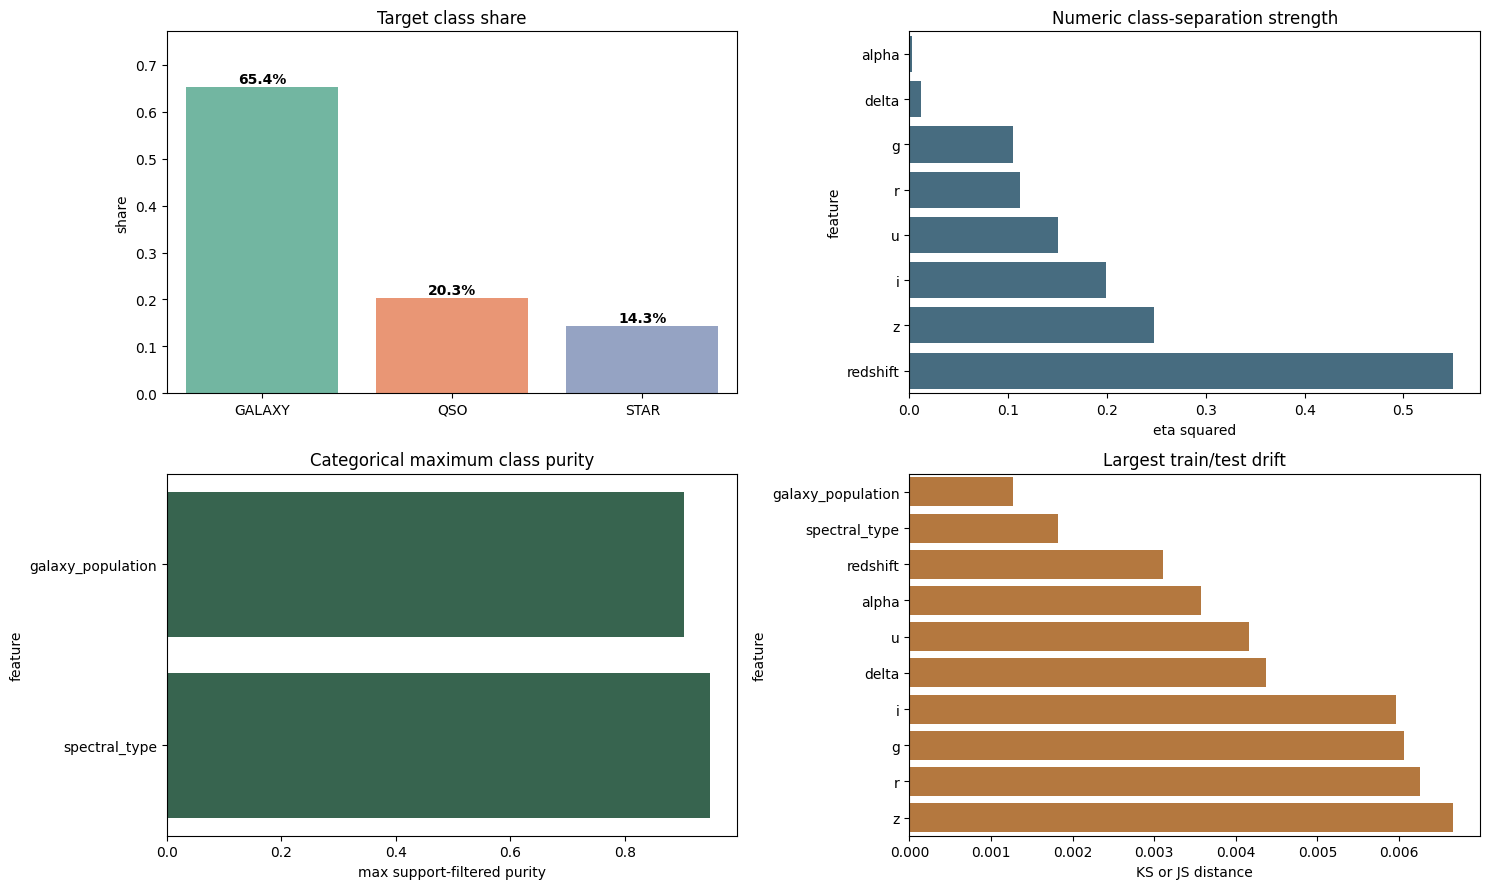

In [8]:
# =================================================================================
# EXECUTIVE DASHBOARD TABLES AND PLOTS
# =================================================================================
def class_distribution(df: pd.DataFrame) -> pd.DataFrame:
    out = df[target_col].astype(str).value_counts().reindex(classes, fill_value=0).rename_axis("class").reset_index(name="count")
    out["pct"] = out["count"] / len(df)
    return out


class_counts = class_distribution(train)
target_entropy_bits = float(entropy(class_counts["pct"], base=2))

missing_rows = []
for c in feature_input_cols:
    missing_rows.append({
        "feature": c,
        "dtype": str(train_full[c].dtype),
        "train_missing_pct": float(train_full[c].isna().mean()),
        "test_missing_pct": float(test[c].isna().mean()),
        "train_nunique": int(train_full[c].nunique(dropna=False)),
        "test_nunique": int(test[c].nunique(dropna=False)),
    })
missing_cardinality = pd.DataFrame(missing_rows).sort_values(["train_missing_pct", "test_missing_pct", "train_nunique"], ascending=False)

shift_rows = []
for c in feature_input_cols:
    if c in numeric_cols_raw:
        a = pd.to_numeric(train_full[c], errors="coerce").dropna()
        b = pd.to_numeric(test[c], errors="coerce").dropna()
        if len(a) > 100_000:
            a = a.sample(100_000, random_state=SEED)
        if len(b) > 100_000:
            b = b.sample(100_000, random_state=SEED)
        pooled_std = float(np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)) if len(a) > 1 and len(b) > 1 else np.nan
        smd = float((b.mean() - a.mean()) / pooled_std) if pooled_std and np.isfinite(pooled_std) else np.nan
        shift_rows.append({
            "feature": c,
            "kind": "numeric",
            "ks_stat": float(ks_2samp(a, b).statistic) if len(a) and len(b) else np.nan,
            "wasserstein": float(wasserstein_distance(a, b)) if len(a) and len(b) else np.nan,
            "smd": smd,
            "js_distance": np.nan,
        })
    else:
        av = train_full[c].astype("string").fillna("__MISSING__")
        bv = test[c].astype("string").fillna("__MISSING__")
        keys = sorted(set(av.unique()).union(set(bv.unique())))
        pa = av.value_counts(normalize=True).reindex(keys, fill_value=0).to_numpy()
        pb = bv.value_counts(normalize=True).reindex(keys, fill_value=0).to_numpy()
        shift_rows.append({"feature": c, "kind": "categorical", "ks_stat": np.nan, "wasserstein": np.nan, "smd": np.nan, "js_distance": float(jensenshannon(pa, pb, base=2.0))})
shift_table = pd.DataFrame(shift_rows)
shift_table["drift_score"] = shift_table[["ks_stat", "js_distance"]].max(axis=1)
shift_table = shift_table.sort_values("drift_score", ascending=False)


def numeric_signal_screen(df: pd.DataFrame, cols: Sequence[str]) -> pd.DataFrame:
    rows = []
    y_str = df[target_col].astype(str)
    for c in cols:
        x = pd.to_numeric(df[c], errors="coerce")
        tmp = pd.DataFrame({"x": x, "class": y_str}).dropna()
        if tmp.empty or tmp["x"].nunique() <= 1:
            rows.append({"feature": c, "kind": "numeric", "eta_sq": np.nan, "median_range": np.nan, "median_range_iqr": np.nan, "top_value": ""})
            continue
        medians = tmp.groupby("class")["x"].median().reindex(classes)
        means = tmp.groupby("class")["x"].mean().reindex(classes)
        overall = tmp["x"].mean()
        counts = tmp.groupby("class")["x"].size().reindex(classes, fill_value=0)
        between = float(((means - overall) ** 2 * counts).sum())
        total = float(((tmp["x"] - overall) ** 2).sum())
        iqr = float(tmp["x"].quantile(0.75) - tmp["x"].quantile(0.25))
        rows.append({
            "feature": c,
            "kind": "numeric",
            "eta_sq": between / total if total > 0 else np.nan,
            "median_range": float(medians.max() - medians.min()),
            "median_range_iqr": float((medians.max() - medians.min()) / iqr) if iqr > 0 else np.nan,
            "top_value": str(medians.idxmax()) if medians.notna().any() else "",
        })
    return pd.DataFrame(rows)


def categorical_signal_screen(df: pd.DataFrame, cols: Sequence[str], min_support: int) -> pd.DataFrame:
    rows = []
    for c in cols:
        tab = pd.crosstab(df[c].astype("string").fillna("__MISSING__"), df[target_col].astype(str), normalize="index")
        counts = df[c].astype("string").fillna("__MISSING__").value_counts(dropna=False)
        stable_index = counts[counts >= min_support].index
        stable = tab.loc[tab.index.intersection(stable_index)] if len(tab) else tab
        use = stable if len(stable) else tab
        purity = float(use.max(axis=1).max()) if len(use) else np.nan
        spread = float((use.max(axis=0) - use.min(axis=0)).max()) if len(use) else np.nan
        top_value = str(use.max(axis=1).idxmax()) if len(use) else ""
        rows.append({
            "feature": c,
            "kind": "categorical",
            "eta_sq": np.nan,
            "median_range": np.nan,
            "median_range_iqr": np.nan,
            "max_category_purity": purity,
            "target_rate_spread": spread,
            "stable_categories": int(len(use)),
            "top_value": top_value,
        })
    return pd.DataFrame(rows)


support_floor = max(100, int(0.001 * len(train)))
numeric_signal = numeric_signal_screen(train, numeric_cols_raw)
categorical_signal = categorical_signal_screen(train, cat_cols_raw, support_floor)
signal_table = pd.concat([numeric_signal, categorical_signal], ignore_index=True, sort=False)
for col, default in {"eta_sq": np.nan, "median_range": np.nan, "median_range_iqr": np.nan, "max_category_purity": np.nan, "target_rate_spread": np.nan, "top_value": ""}.items():
    if col not in signal_table.columns:
        signal_table[col] = default
signal_table["screen_score"] = signal_table["eta_sq"].fillna(0) + signal_table["max_category_purity"].fillna(0) + signal_table["median_range_iqr"].fillna(0).abs() * 0.02
signal_table = signal_table.sort_values("screen_score", ascending=False)

executive_summary = pd.DataFrame([
    {"statistic": "rows used for OOF", "value": f"{len(train):,} / {len(train_full):,}"},
    {"statistic": "test rows", "value": f"{len(test):,}"},
    {"statistic": "raw numeric features", "value": len(numeric_cols_raw)},
    {"statistic": "raw categorical features", "value": len(cat_cols_raw)},
    {"statistic": "target entropy bits", "value": round(target_entropy_bits, 4)},
    {"statistic": "largest train/test drift", "value": f"{shift_table.iloc[0]['feature']} ({shift_table.iloc[0]['drift_score']:.4f})" if len(shift_table) else "NA"},
    {"statistic": "top raw signal", "value": str(signal_table.iloc[0]["feature"]) if len(signal_table) else "NA"},
])

display_table_card("Executive summary", executive_summary, index=False)
display_table_card("Target distribution", class_counts, index=False, accent=COLORS["risk"])
display_table_card("Top raw feature signals", signal_table.head(18), index=False, accent=COLORS["signal"])
display_table_card("Largest train/test shifts", shift_table.head(18), index=False, accent=COLORS["gold"])

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
sns.barplot(data=class_counts, x="class", y="pct", hue="class", palette="Set2", legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Target class share")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("share")
axes[0, 0].set_ylim(0, max(0.05, class_counts["pct"].max() * 1.18))
for patch, value in zip(axes[0, 0].patches, class_counts["pct"]):
    axes[0, 0].text(patch.get_x() + patch.get_width() / 2, value + 0.008, f"{value:.1%}", ha="center", fontweight="bold")

plot_numeric_signal = numeric_signal.dropna(subset=["eta_sq"]).sort_values("eta_sq", ascending=False).head(10).sort_values("eta_sq")
if len(plot_numeric_signal):
    sns.barplot(data=plot_numeric_signal, y="feature", x="eta_sq", ax=axes[0, 1], color=COLORS["signal"])
    axes[0, 1].set_title("Numeric class-separation strength")
    axes[0, 1].set_xlabel("eta squared")
else:
    axes[0, 1].text(0.5, 0.5, "No numeric signal table", ha="center", va="center")
    axes[0, 1].set_axis_off()

plot_cat_signal = categorical_signal.dropna(subset=["max_category_purity"]).sort_values("max_category_purity", ascending=False).head(10).sort_values("max_category_purity")
if len(plot_cat_signal):
    sns.barplot(data=plot_cat_signal, y="feature", x="max_category_purity", ax=axes[1, 0], color=COLORS["primary"])
    axes[1, 0].set_title("Categorical maximum class purity")
    axes[1, 0].set_xlabel("max support-filtered purity")
else:
    axes[1, 0].text(0.5, 0.5, "No categorical signal table", ha="center", va="center")
    axes[1, 0].set_axis_off()

plot_shift = shift_table.head(10).sort_values("drift_score")
if len(plot_shift):
    sns.barplot(data=plot_shift, y="feature", x="drift_score", ax=axes[1, 1], color=COLORS["gold"])
    axes[1, 1].set_title("Largest train/test drift")
    axes[1, 1].set_xlabel("KS or JS distance")
else:
    axes[1, 1].text(0.5, 0.5, "No shift table", ha="center", va="center")
    axes[1, 1].set_axis_off()
plt.tight_layout()
plt.show()


## 6. Data Quality and Leakage Checks

<div style="background:#FFFCF8; border:1px solid #E2D8C7; border-left:6px solid #2F6B4F; border-radius:14px; padding:13px 15px; margin:10px 0 16px 0; color:#233127; line-height:1.58; box-shadow:0 8px 18px rgba(35,49,39,0.04);">IDs, duplicates, missingness, cardinality, and original-reference overlap are checked before modeling. The original file can help feature understanding, but exact or rounded overlap with competition rows must be visible.</div>


In [9]:
# =================================================================================
# DATA QUALITY, ID, CARDINALITY, AND OVERLAP CHECKS
# =================================================================================
missing_summary_rows = []
for name, df in [("train_full", train_full), ("train_used", train), ("test", test), ("sample_submission", sample_submission)] + ([] if original_reference is None else [("original_reference", original_reference)]):
    cells = df.shape[0] * df.shape[1]
    missing_total = int(df.isna().sum().sum())
    missing_summary_rows.append({
        "dataset": name,
        "rows": len(df),
        "columns": df.shape[1],
        "total_missing": missing_total,
        "columns_with_missing": int((df.isna().sum() > 0).sum()),
        "missing_cell_rate": missing_total / cells if cells else 0,
    })
missing_summary = pd.DataFrame(missing_summary_rows)

id_order_match = bool(test[id_col].equals(sample_submission[id_col]))
id_set_match = set(test[id_col]) == set(sample_submission[id_col])
duplicate_summary = pd.DataFrame([
    {"dataset": "train_full", "rows": len(train_full), "duplicate_ids": int(train_full[id_col].duplicated().sum()), "duplicate_full_rows": int(train_full.duplicated().sum()), "duplicate_feature_rows": int(train_full[feature_input_cols].duplicated().sum())},
    {"dataset": "test", "rows": len(test), "duplicate_ids": int(test[id_col].duplicated().sum()), "duplicate_full_rows": int(test.duplicated().sum()), "duplicate_feature_rows": int(test[feature_input_cols].duplicated().sum())},
    {"dataset": "sample_submission", "rows": len(sample_submission), "duplicate_ids": int(sample_submission[id_col].duplicated().sum()), "duplicate_full_rows": int(sample_submission.duplicated().sum()), "duplicate_feature_rows": np.nan},
])
submission_order_summary = pd.DataFrame([
    {"check": "test/sample id sets match", "value": id_set_match},
    {"check": "test/sample id order matches", "value": id_order_match},
    {"check": "sample target columns", "value": ", ".join(sample_target_cols)},
])

cardinality_rows = []
for c in cat_cols_raw:
    train_values = set(train_full[c].astype("string").dropna().unique())
    test_values = set(test[c].astype("string").dropna().unique())
    vc = train_full[c].astype("string").fillna("__MISSING__").value_counts(dropna=False)
    cardinality_rows.append({
        "feature": c,
        "train_unique": len(train_values),
        "test_unique": len(test_values),
        "unseen_test_categories": len(test_values - train_values),
        "min_train_support": int(vc.min()) if len(vc) else 0,
        "max_train_support": int(vc.max()) if len(vc) else 0,
        "support_floor": support_floor,
    })
cardinality_support = pd.DataFrame(cardinality_rows)

id_like_rows = []
for c in numeric_cols_raw:
    x = pd.to_numeric(train_full[c], errors="coerce")
    corr = np.nan
    if x.nunique(dropna=True) > 1 and train_full[id_col].nunique(dropna=True) > 1:
        corr = abs(pd.Series(x).corr(pd.Series(train_full[id_col]), method="spearman"))
    id_like_rows.append({
        "feature": c,
        "nunique_ratio": float(train_full[c].nunique(dropna=False) / len(train_full)),
        "spearman_abs_corr_with_id": corr,
        "is_high_card_numeric": bool(train_full[c].nunique(dropna=False) / len(train_full) > 0.50),
    })
id_like_table = pd.DataFrame(id_like_rows).sort_values(["nunique_ratio", "spearman_abs_corr_with_id"], ascending=False)


def feature_hash_frame(df: pd.DataFrame, cols: Sequence[str], decimals: Optional[int] = None) -> pd.Series:
    tmp = pd.DataFrame(index=df.index)
    for c in cols:
        if c not in df.columns:
            continue
        s = df[c]
        if pd.api.types.is_numeric_dtype(s):
            s = pd.to_numeric(s, errors="coerce")
            if decimals is not None:
                s = s.round(decimals)
            tmp[c] = s
        else:
            tmp[c] = s.astype("string").fillna("__MISSING__")
    if tmp.empty:
        return pd.Series([], dtype="uint64")
    return pd.util.hash_pandas_object(tmp, index=False).astype("uint64")


overlap_rows = []
train_exact_hash = feature_hash_frame(train_full, feature_input_cols)
test_exact_hash = feature_hash_frame(test, feature_input_cols)
train_round_hash = feature_hash_frame(train_full, feature_input_cols, decimals=6)
test_round_hash = feature_hash_frame(test, feature_input_cols, decimals=6)
overlap_rows.append({
    "comparison": "train vs test raw features",
    "common_features": len(feature_input_cols),
    "exact_overlap_rows": int(test_exact_hash.isin(set(train_exact_hash)).sum()),
    "rounded_overlap_rows": int(test_round_hash.isin(set(train_round_hash)).sum()),
})

if original_reference is not None:
    original_common_cols = [c for c in feature_input_cols if c in original_reference.columns]
    original_exact_hash = feature_hash_frame(original_reference, original_common_cols)
    original_round_hash = feature_hash_frame(original_reference, original_common_cols, decimals=6)
    train_common_exact = feature_hash_frame(train_full, original_common_cols)
    test_common_exact = feature_hash_frame(test, original_common_cols)
    train_common_round = feature_hash_frame(train_full, original_common_cols, decimals=6)
    test_common_round = feature_hash_frame(test, original_common_cols, decimals=6)
    overlap_rows.extend([
        {"comparison": "original vs train common features", "common_features": len(original_common_cols), "exact_overlap_rows": int(original_exact_hash.isin(set(train_common_exact)).sum()), "rounded_overlap_rows": int(original_round_hash.isin(set(train_common_round)).sum())},
        {"comparison": "original vs test common features", "common_features": len(original_common_cols), "exact_overlap_rows": int(original_exact_hash.isin(set(test_common_exact)).sum()), "rounded_overlap_rows": int(original_round_hash.isin(set(test_common_round)).sum())},
    ])
overlap_table = pd.DataFrame(overlap_rows)

display_table_card("Missing-value summary", missing_summary, index=False)
display_table_card("Missingness and cardinality by raw feature", missing_cardinality, index=False)
display_table_card("Duplicate and ID audit", duplicate_summary, index=False, accent=COLORS["risk"])
display_table_card("Submission ID alignment", submission_order_summary, index=False, accent=COLORS["risk"])
display_table_card("Categorical cardinality and support", cardinality_support, index=False, accent=COLORS["signal"])
display_table_card("High-cardinality numeric and ID-like screen", id_like_table, index=False, accent=COLORS["gold"])
display_table_card("Feature-hash overlap checks", overlap_table, index=False, accent=COLORS["risk"])


dataset,rows,columns,total_missing,columns_with_missing,missing_cell_rate
train_full,577347,12,0,0,0.00000
train_used,577347,12,0,0,0.00000
test,247435,11,0,0,0.00000
sample_submission,247435,2,0,0,0.00000
original_reference,100000,18,0,0,0.00000


feature,dtype,train_missing_pct,test_missing_pct,train_nunique,test_nunique
u,float64,0.00000,0.00000,577347,247435
g,float64,0.00000,0.00000,577347,247435
r,float64,0.00000,0.00000,577347,247435
i,float64,0.00000,0.00000,577347,247435
z,float64,0.00000,0.00000,577347,247435
redshift,float64,0.00000,0.00000,573975,246031
delta,float64,0.00000,0.00000,444062,201819
alpha,float64,0.00000,0.00000,439819,200893
spectral_type,object,0.00000,0.00000,4,4
galaxy_population,object,0.00000,0.00000,2,2


dataset,rows,duplicate_ids,duplicate_full_rows,duplicate_feature_rows
train_full,577347,0,0,0.00000
test,247435,0,0,0.00000
sample_submission,247435,0,0,nan


check,value
test/sample id sets match,True
test/sample id order matches,True
sample target columns,class


feature,train_unique,test_unique,unseen_test_categories,min_train_support,max_train_support,support_floor
spectral_type,4,4,0,43356,303323,577
galaxy_population,2,2,0,257782,319565,577


feature,nunique_ratio,spearman_abs_corr_with_id,is_high_card_numeric
z,1.00000,0.00162,True
r,1.00000,0.00103,True
i,1.00000,0.00096,True
u,1.00000,0.00080,True
g,1.00000,0.00032,True
redshift,0.99416,0.00131,True
delta,0.76914,0.00026,True
alpha,0.76179,0.00361,True


comparison,common_features,exact_overlap_rows,rounded_overlap_rows
train vs test raw features,10,0,0
original vs train common features,8,0,0
original vs test common features,8,0,0


## 7. Target and Feature Signal

<div style="background:#FFFCF8; border:1px solid #E2D8C7; border-left:6px solid #3D6F8A; border-radius:14px; padding:13px 15px; margin:10px 0 16px 0; color:#233127; line-height:1.58; box-shadow:0 8px 18px rgba(35,49,39,0.04);">Class separation is checked through raw numeric effect size, class-wise medians, categorical purity, photometric colors, and redshift behavior. The strongest raw signals motivate the engineered color, flux, coordinate, and redshift features used later.</div>


class,count,pct,class_weight
GALAXY,377480,0.65382,0.50983
QSO,117143,0.20290,1.64286
STAR,82724,0.14328,2.32640


feature,GALAXY_median,GALAXY_iqr,QSO_median,QSO_iqr,STAR_median,STAR_iqr,eta_sq,median_range_iqr
redshift,0.48196,0.44801,1.79889,1.37460,0.05649,0.08019,0.55006,2.48793
z,18.92839,1.93199,20.69767,0.97515,18.69590,2.60044,0.24737,0.91450
i,19.39910,2.06756,20.86899,1.01698,18.81599,2.72183,0.19920,0.89208
u,23.13883,2.44642,21.70076,1.19053,20.75820,3.00880,0.15091,0.82317
r,20.32963,2.54910,21.01303,1.04144,19.03433,2.86279,0.11217,0.84436
g,21.91720,2.55057,21.24630,1.05726,19.50741,2.86087,0.10464,0.99262
delta,20.01481,32.76631,29.27892,38.79130,19.56696,35.40646,0.01168,0.28139
alpha,191.98815,94.90734,186.15151,108.54034,188.06869,129.76431,0.00218,0.05856


feature,category,support,support_share,max_class_share,GALAXY,QSO,STAR
spectral_type,M,303323,0.52537,0.94956,0.94956,0.01282,0.03762
galaxy_population,Red_Sequence,319565,0.55351,0.90285,0.90285,0.02775,0.06940
spectral_type,O/B,43356,0.07510,0.71084,0.08280,0.71084,0.20636
spectral_type,G/K,108546,0.18801,0.56775,0.56775,0.19274,0.23951
spectral_type,A/F,122122,0.21152,0.50371,0.19849,0.50371,0.29780
galaxy_population,Blue_Cloud,257782,0.44649,0.42002,0.34511,0.42002,0.23487


color,median_range,median_range_iqr,GALAXY_median,QSO_median,STAR_median
u-z,3.38199,1.08423,4.28800,0.90601,1.87481
u-r,2.47577,1.06568,3.06139,0.58563,1.63845
g-i,1.99207,1.03959,2.34215,0.35008,0.60676
g-r,1.26735,1.03365,1.48093,0.21358,0.45315
g-z,2.28264,1.02098,2.79292,0.51028,0.68909
r-z,0.93869,0.93951,1.22228,0.30394,0.28359
r-i,0.65358,0.89367,0.79478,0.14120,0.19299
u-g,1.31062,0.88018,1.69377,0.38315,1.22072
i-z,0.31780,0.64017,0.43683,0.16800,0.11903


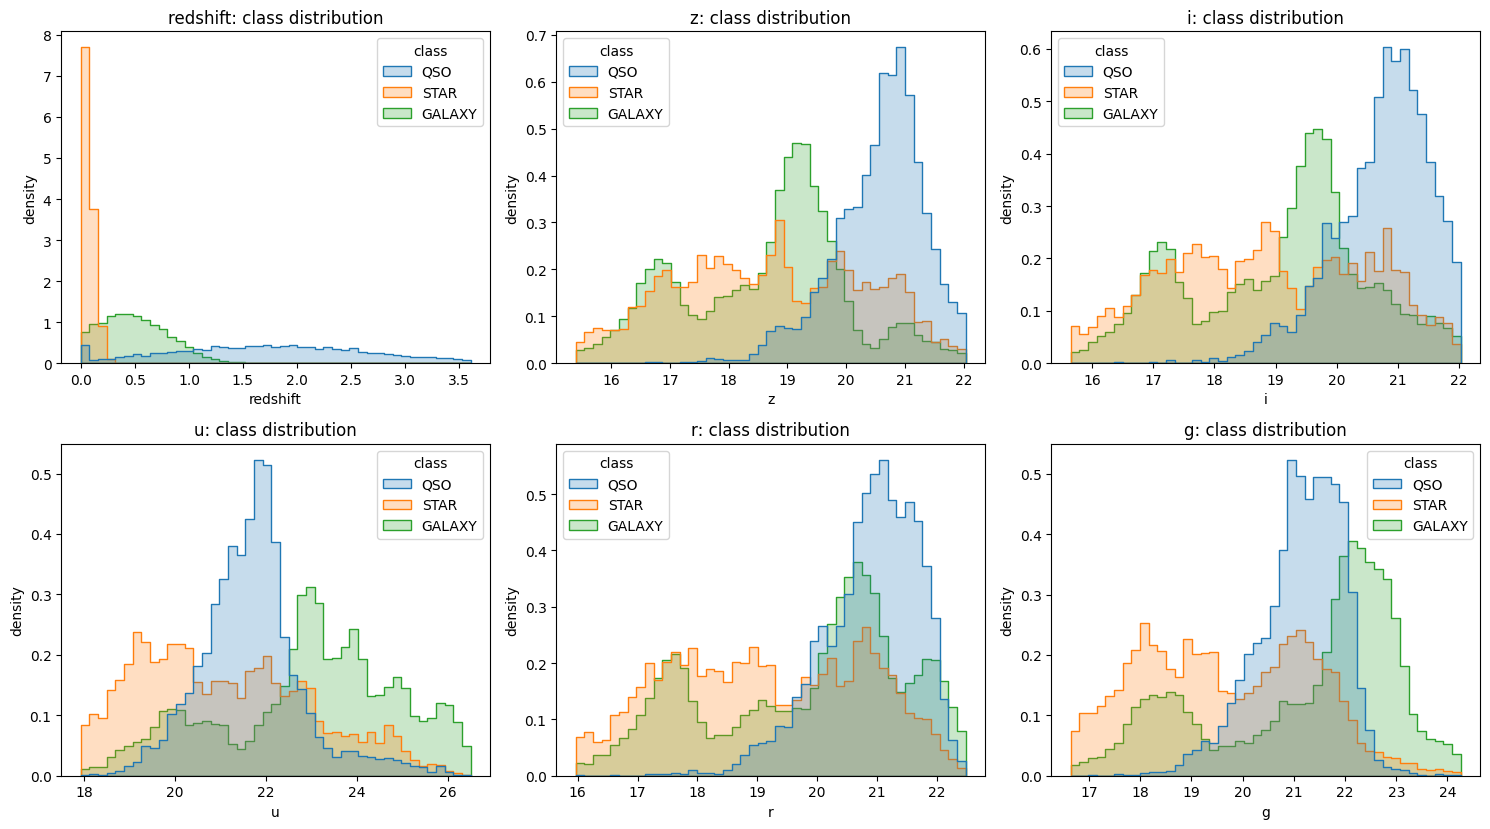

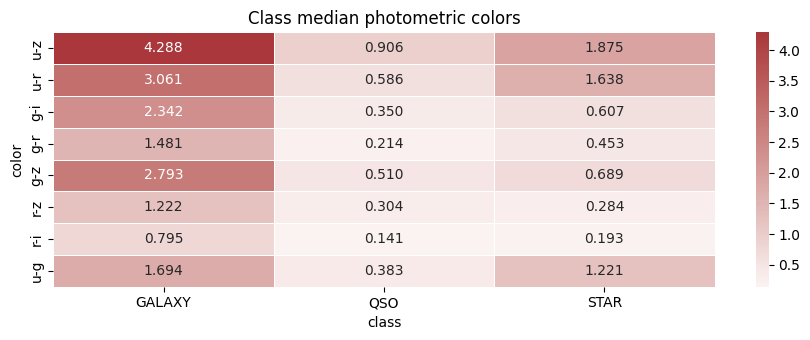

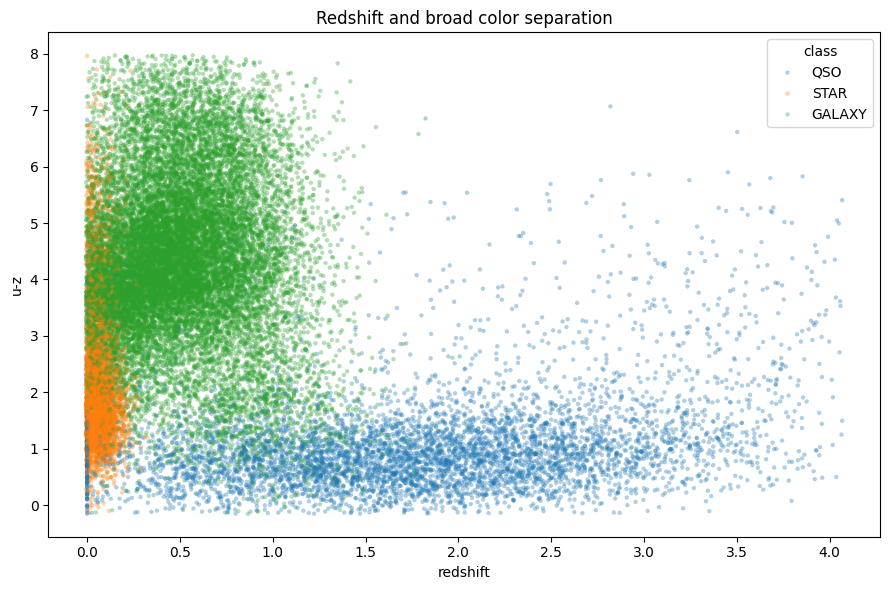

In [10]:
# =================================================================================
# TARGET, NUMERIC, CATEGORICAL, AND PHOTOMETRIC SIGNAL
# =================================================================================
target_distribution = class_counts.copy()
target_distribution["class_weight"] = target_distribution["class"].map(class_weight_by_name)
display_table_card("Target balance and class weights", target_distribution, index=False, accent=COLORS["risk"])

numeric_class_rows = []
for c in numeric_cols_raw:
    x = pd.to_numeric(train[c], errors="coerce")
    tmp = pd.DataFrame({"value": x, "class": train[target_col].astype(str)}).dropna()
    if tmp.empty:
        continue
    row = {"feature": c}
    for cls in classes:
        cls_values = tmp.loc[tmp["class"].eq(cls), "value"]
        row[f"{cls}_median"] = float(cls_values.median()) if len(cls_values) else np.nan
        row[f"{cls}_iqr"] = float(cls_values.quantile(0.75) - cls_values.quantile(0.25)) if len(cls_values) else np.nan
    signal_row = numeric_signal.loc[numeric_signal["feature"].eq(c)].head(1)
    row["eta_sq"] = float(signal_row["eta_sq"].iloc[0]) if len(signal_row) else np.nan
    row["median_range_iqr"] = float(signal_row["median_range_iqr"].iloc[0]) if len(signal_row) else np.nan
    numeric_class_rows.append(row)
numeric_by_class = pd.DataFrame(numeric_class_rows).sort_values("eta_sq", ascending=False)
display_table_card("Numeric class medians and effect size", numeric_by_class, index=False)

cat_rate_tables = []
for c in cat_cols_raw:
    rates = (
        train.groupby(c, observed=False, dropna=False)[target_col]
        .agg(support="count")
        .reset_index()
    )
    class_share = pd.crosstab(train[c].astype("string").fillna("__MISSING__"), train[target_col].astype(str), normalize="index").reset_index().rename(columns={c: "category"})
    if c in class_share.columns:
        class_share = class_share.rename(columns={c: "category"})
    rates = rates.rename(columns={c: "category"})
    merged = rates.merge(class_share, on="category", how="left")
    merged["feature"] = c
    merged["support_share"] = merged["support"] / len(train)
    merged["max_class_share"] = merged[classes].max(axis=1) if set(classes).issubset(merged.columns) else np.nan
    cat_rate_tables.append(merged[["feature", "category", "support", "support_share", "max_class_share"] + [col for col in classes if col in merged.columns]])
categorical_rate_table = pd.concat(cat_rate_tables, ignore_index=True) if cat_rate_tables else pd.DataFrame()
if len(categorical_rate_table):
    display_table_card("Support-filtered categorical class rates", categorical_rate_table[categorical_rate_table["support"] >= support_floor].sort_values("max_class_share", ascending=False), index=False)
else:
    display_table_card("Support-filtered categorical class rates", categorical_rate_table, index=False)

band_cols = [c for c in ["u", "g", "r", "i", "z"] if c in train.columns]
color_pairs = [("u", "g"), ("g", "r"), ("r", "i"), ("i", "z"), ("u", "r"), ("u", "z"), ("g", "i"), ("g", "z"), ("r", "z")]
color_rows = []
color_frame = pd.DataFrame(index=train.index)
for a, b in color_pairs:
    if a in train.columns and b in train.columns:
        name = f"{a}-{b}"
        color = pd.to_numeric(train[a], errors="coerce") - pd.to_numeric(train[b], errors="coerce")
        color_frame[name] = color
        tmp = pd.DataFrame({"value": color, "class": train[target_col].astype(str)}).dropna()
        if tmp.empty:
            continue
        medians = tmp.groupby("class")["value"].median().reindex(classes)
        iqr = float(tmp["value"].quantile(0.75) - tmp["value"].quantile(0.25))
        color_rows.append({
            "color": name,
            "median_range": float(medians.max() - medians.min()),
            "median_range_iqr": float((medians.max() - medians.min()) / iqr) if iqr > 0 else np.nan,
            **{f"{cls}_median": float(medians.loc[cls]) if pd.notna(medians.loc[cls]) else np.nan for cls in classes},
        })
color_signal_table = pd.DataFrame(color_rows).sort_values("median_range_iqr", ascending=False) if color_rows else pd.DataFrame()
display_table_card("Photometric color signal", color_signal_table, index=False, accent=COLORS["signal"])

plot_train = safe_sample(train)
top_numeric_features = numeric_by_class.head(6)["feature"].tolist() if len(numeric_by_class) else []
if top_numeric_features:
    ncols = 3
    nrows = int(math.ceil(len(top_numeric_features) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.2 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, feature in zip(axes, top_numeric_features):
        tmp = plot_train[[feature, target_col]].dropna().copy()
        lo, hi = tmp[feature].quantile([0.01, 0.99])
        tmp = tmp[tmp[feature].between(lo, hi)]
        sns.histplot(data=tmp, x=feature, hue=target_col, bins=45, stat="density", common_norm=False, element="step", ax=ax)
        ax.set_title(f"{feature}: class distribution")
        ax.set_xlabel(feature)
        ax.set_ylabel("density")
    for ax in axes[len(top_numeric_features):]:
        ax.set_axis_off()
    plt.tight_layout()
    plt.show()

if len(color_signal_table):
    top_colors = color_signal_table.head(8)["color"].tolist()
    color_medians = []
    for color in top_colors:
        tmp = pd.DataFrame({"value": color_frame[color], "class": train[target_col].astype(str)}).dropna()
        row = tmp.groupby("class")["value"].median().reindex(classes)
        color_medians.append(row.rename(color))
    color_median_matrix = pd.DataFrame(color_medians)
    plt.figure(figsize=(9, max(3.5, 0.42 * len(color_median_matrix))))
    sns.heatmap(color_median_matrix, annot=True, fmt=".3f", cmap="vlag", center=0, linewidths=0.4)
    plt.title("Class median photometric colors")
    plt.xlabel("class")
    plt.ylabel("color")
    plt.tight_layout()
    plt.show()

if {"redshift", "u", "z"}.issubset(train.columns):
    scatter = plot_train[["redshift", "u", "z", target_col]].dropna().copy()
    scatter["u-z"] = scatter["u"] - scatter["z"]
    red_lo, red_hi = scatter["redshift"].quantile([0.005, 0.995])
    color_lo, color_hi = scatter["u-z"].quantile([0.005, 0.995])
    scatter = scatter[scatter["redshift"].between(red_lo, red_hi) & scatter["u-z"].between(color_lo, color_hi)]
    plt.figure(figsize=(9, 6))
    sns.scatterplot(data=scatter, x="redshift", y="u-z", hue=target_col, s=10, alpha=0.35, linewidth=0)
    plt.title("Redshift and broad color separation")
    plt.xlabel("redshift")
    plt.ylabel("u-z")
    plt.tight_layout()
    plt.show()


### 7.1 Astronomy-Oriented Feature Geometry

<div style="background:#FFFCF8; border:1px solid #E2D8C7; border-left:6px solid #3D6F8A; border-radius:14px; padding:13px 15px; margin:10px 0 16px 0; color:#233127; line-height:1.58; box-shadow:0 8px 18px rgba(35,49,39,0.04);">
This compact addendum follows the astronomy-first EDA idea from <a href="https://www.kaggle.com/code/aryankaisth/s6e6-the-complete-eda-100" style="color:#2F6B4F; font-weight:800;">Aryan Kaisth's Kaggle notebook, <em>S6E6 - The Complete EDA 100%</em></a>. The focus here is narrower: photometric color geometry, redshift separation, sky-coordinate projection, categorical association, and sentinel/outlier checks that affect modeling choices.
</div>


dataset,feature,rows,missing_or_nonfinite,le_minus_999_count,min,p001,median,p999,max
train,alpha,577347,0,0,0.01168,0.09152,188.68147,359.93379,359.99981
train,delta,577347,0,0,-17.96699,-11.00126,21.48441,67.44514,79.15832
train,u,577347,0,0,-0.13922,16.86275,22.57022,27.11531,28.25326
train,g,577347,0,0,13.53548,15.49918,21.46782,25.22425,27.62021
train,r,577347,0,0,12.57941,14.85455,20.43115,23.10641,25.25450
train,i,577347,0,0,11.96278,14.52695,19.63164,22.41323,27.91085
train,z,577347,0,0,11.68280,14.23252,19.18860,22.91591,26.82687
train,redshift,577347,0,0,-0.00997,-0.00937,0.49752,6.01470,7.01078
test,alpha,247435,0,0,0.01096,0.09207,188.55943,359.93310,359.99972
test,delta,247435,0,0,-17.95926,-11.00115,21.45202,67.44954,79.17044


feature,unique_values,cramers_v_with_class,max_category_support,min_category_support
galaxy_population,2,0.59349,319565,257782
spectral_type,4,0.52480,303323,43356


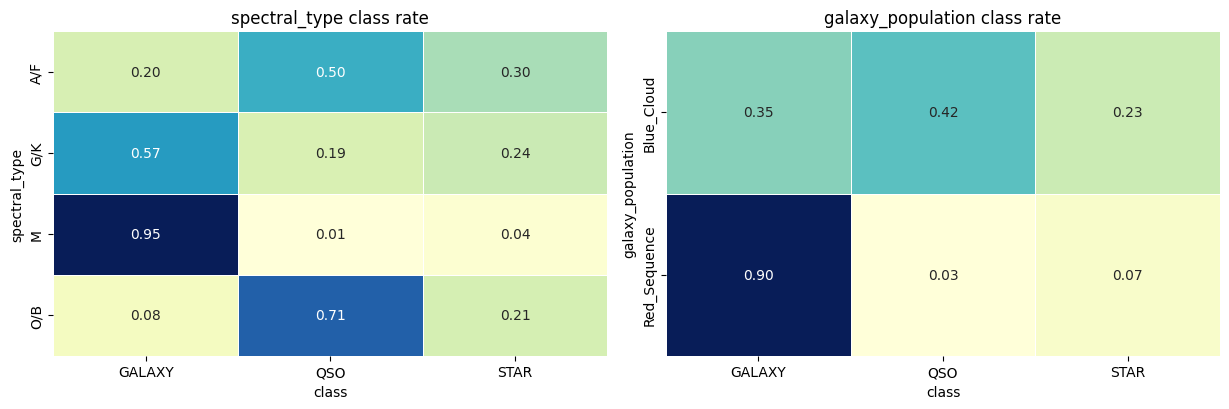

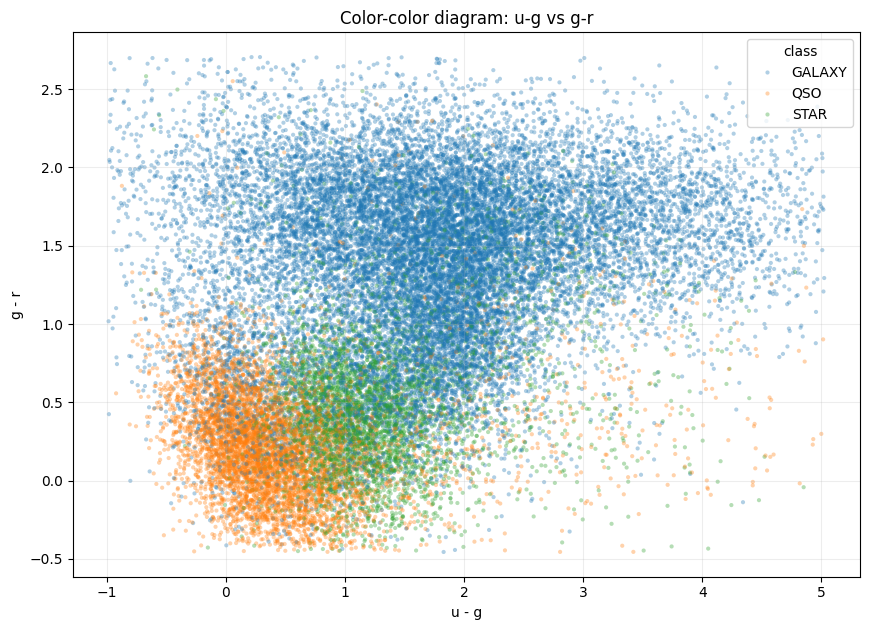

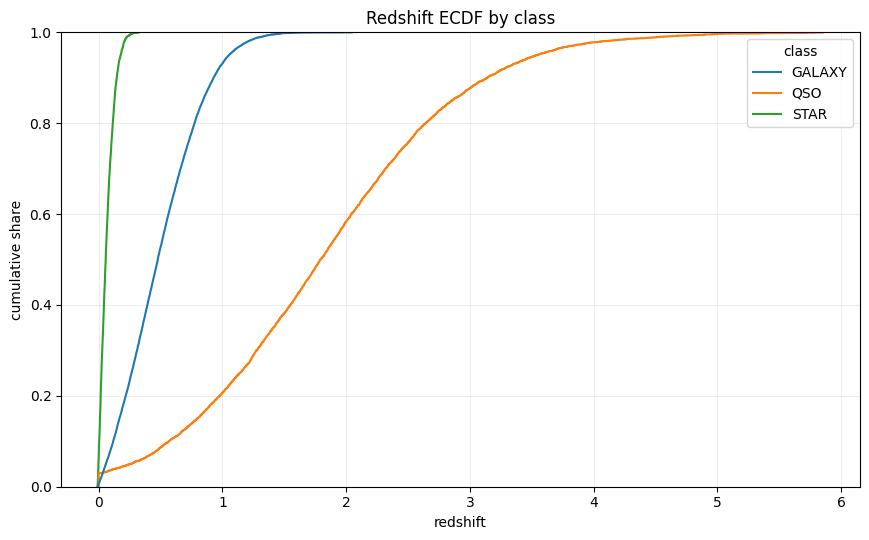

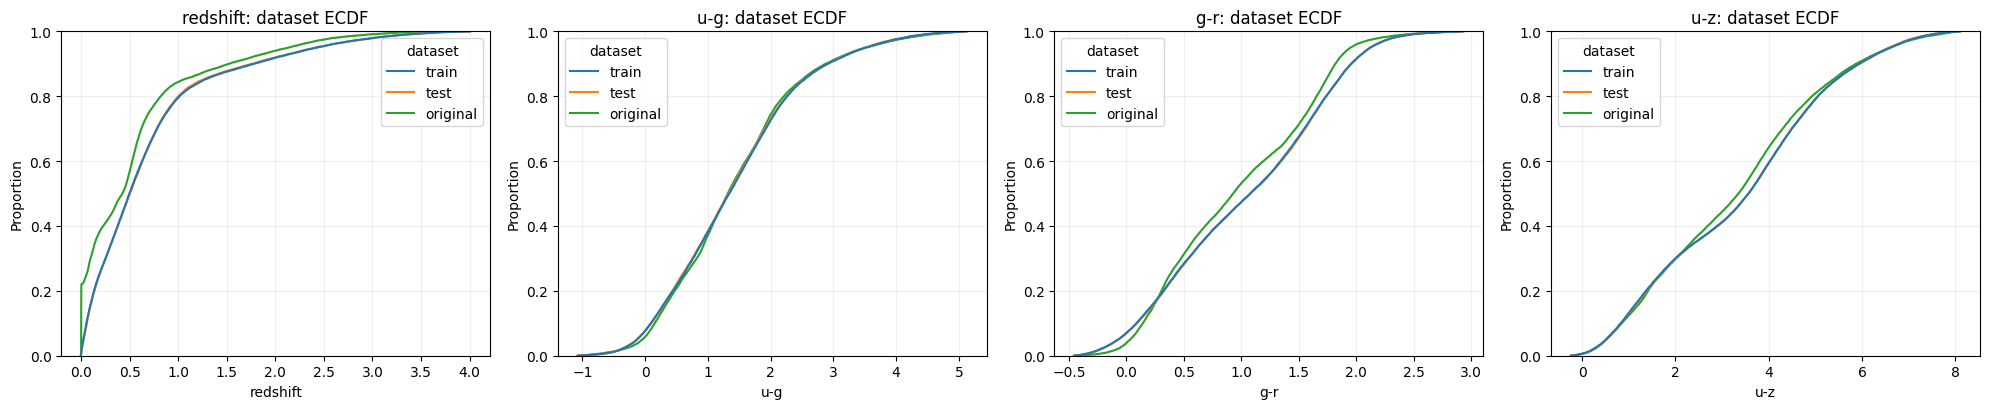

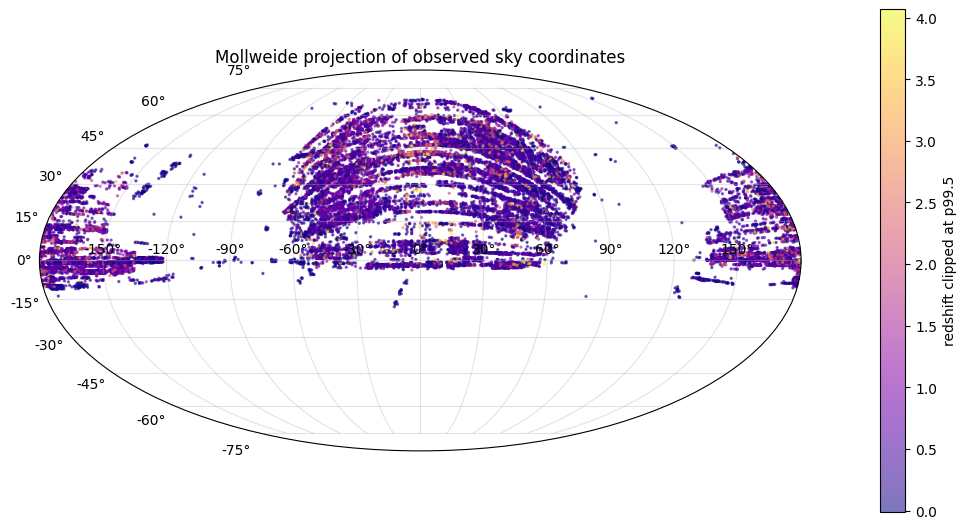

In [11]:
# =================================================================================
# ASTRONOMY-ORIENTED EDA ADDENDUM
# =================================================================================
from scipy.stats import chi2_contingency

astro_numeric_cols = [c for c in ["alpha", "delta", "u", "g", "r", "i", "z", "redshift"] if c in train.columns]
astro_cat_cols = [c for c in ["spectral_type", "galaxy_population"] if c in train.columns]


def add_photometric_colors(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    for a, b in [("u", "g"), ("g", "r"), ("r", "i"), ("i", "z"), ("u", "z")]:
        if a in out.columns and b in out.columns:
            out[f"{a}-{b}"] = pd.to_numeric(out[a], errors="coerce") - pd.to_numeric(out[b], errors="coerce")
    return out


def clipped_between_quantiles(frame: pd.DataFrame, cols: Sequence[str], q_low: float = 0.005, q_high: float = 0.995) -> pd.DataFrame:
    out = frame.copy()
    for col in cols:
        if col not in out.columns:
            continue
        values = pd.to_numeric(out[col], errors="coerce")
        if values.notna().sum() < 10:
            continue
        lo, hi = values.quantile([q_low, q_high])
        out = out[values.between(lo, hi) | values.isna()]
    return out


# Sentinel and extreme-value audit. A -9999-like value can dominate KDE/scatter axes and should be explicit.
sentinel_sources = [("train", train_full), ("test", test)]
if original_reference is not None:
    sentinel_sources.append(("original", original_reference))

sentinel_rows = []
for dataset_name, frame in sentinel_sources:
    for col in astro_numeric_cols:
        if col not in frame.columns:
            continue
        values = pd.to_numeric(frame[col], errors="coerce")
        finite = values[np.isfinite(values)]
        sentinel_rows.append({
            "dataset": dataset_name,
            "feature": col,
            "rows": int(len(values)),
            "missing_or_nonfinite": int((~np.isfinite(values)).sum()),
            "le_minus_999_count": int((values <= -999).sum()),
            "min": float(finite.min()) if len(finite) else np.nan,
            "p001": float(finite.quantile(0.001)) if len(finite) else np.nan,
            "median": float(finite.median()) if len(finite) else np.nan,
            "p999": float(finite.quantile(0.999)) if len(finite) else np.nan,
            "max": float(finite.max()) if len(finite) else np.nan,
        })
sentinel_extreme_table = pd.DataFrame(sentinel_rows)
display_table_card("Sentinel and extreme-value audit", sentinel_extreme_table, index=False, accent=COLORS["risk"])


# Categorical association: row-normalized class rates and Cramer's V.
def cramers_v(x: pd.Series, y: pd.Series) -> float:
    ct = pd.crosstab(x.astype("string").fillna("__MISSING__"), y.astype(str))
    if min(ct.shape) <= 1 or ct.to_numpy().sum() == 0:
        return np.nan
    chi2 = chi2_contingency(ct)[0]
    n = ct.to_numpy().sum()
    return float(np.sqrt(chi2 / (n * (min(ct.shape) - 1))))

cat_assoc_rows = []
for col in astro_cat_cols:
    x = train[col].astype("string").fillna("__MISSING__")
    cat_assoc_rows.append({
        "feature": col,
        "unique_values": int(x.nunique(dropna=False)),
        "cramers_v_with_class": cramers_v(x, train[target_col]),
        "max_category_support": int(x.value_counts(dropna=False).max()),
        "min_category_support": int(x.value_counts(dropna=False).min()),
    })
cat_assoc_summary = pd.DataFrame(cat_assoc_rows).sort_values("cramers_v_with_class", ascending=False) if cat_assoc_rows else pd.DataFrame()
display_table_card("Categorical association with class", cat_assoc_summary, index=False, accent=COLORS["signal"])

if astro_cat_cols:
    ncols = len(astro_cat_cols)
    fig, axes = plt.subplots(1, ncols, figsize=(6.2 * ncols, 4.2), squeeze=False)
    for ax, col in zip(axes.ravel(), astro_cat_cols):
        rate = pd.crosstab(
            train[col].astype("string").fillna("__MISSING__"),
            train[target_col].astype(str),
            normalize="index",
        ).reindex(columns=classes, fill_value=0)
        sns.heatmap(rate, annot=True, fmt=".2f", cmap="YlGnBu", cbar=ncols == 1, linewidths=0.4, ax=ax)
        ax.set_title(f"{col} class rate")
        ax.set_xlabel("class")
        ax.set_ylabel(col)
    plt.tight_layout()
    plt.show()


# Color-color diagram: u-g vs g-r is a compact view of photometric separation.
color_plot = add_photometric_colors(safe_sample(train, n=min(EDA_PLOT_SAMPLE_SIZE, 40_000)))
if {"u-g", "g-r", target_col}.issubset(color_plot.columns):
    color_plot = clipped_between_quantiles(color_plot[["u-g", "g-r", target_col]].dropna(), ["u-g", "g-r"], 0.005, 0.995)
    plt.figure(figsize=(8.8, 6.4))
    sns.scatterplot(data=color_plot, x="u-g", y="g-r", hue=target_col, hue_order=classes, s=9, alpha=0.35, linewidth=0)
    plt.title("Color-color diagram: u-g vs g-r")
    plt.xlabel("u - g")
    plt.ylabel("g - r")
    plt.grid(alpha=0.22)
    plt.tight_layout()
    plt.show()


# Redshift ECDF by class. QSO/galaxy separation often appears more clearly on cumulative scale than raw KDE.
if "redshift" in train.columns:
    redshift_plot = safe_sample(train[["redshift", target_col]].dropna(), n=min(EDA_PLOT_SAMPLE_SIZE, 50_000))
    redshift_plot = clipped_between_quantiles(redshift_plot, ["redshift"], 0.001, 0.999)
    plt.figure(figsize=(8.8, 5.5))
    sns.ecdfplot(data=redshift_plot, x="redshift", hue=target_col, hue_order=classes)
    plt.title("Redshift ECDF by class")
    plt.xlabel("redshift")
    plt.ylabel("cumulative share")
    plt.grid(alpha=0.22)
    plt.tight_layout()
    plt.show()


# Train/test/original stability for redshift and key color indices.
stability_frames = []
for dataset_name, frame in sentinel_sources:
    source = add_photometric_colors(safe_sample(frame, n=min(EDA_PLOT_SAMPLE_SIZE, 30_000)))
    keep_cols = [c for c in ["redshift", "u-g", "g-r", "u-z"] if c in source.columns]
    if keep_cols:
        tmp = source[keep_cols].copy()
        tmp["dataset"] = dataset_name
        stability_frames.append(tmp)

if stability_frames:
    stability_plot = pd.concat(stability_frames, ignore_index=True)
    stability_cols = [c for c in ["redshift", "u-g", "g-r", "u-z"] if c in stability_plot.columns]
    fig, axes = plt.subplots(1, len(stability_cols), figsize=(5.0 * len(stability_cols), 4.2), squeeze=False)
    for ax, col in zip(axes.ravel(), stability_cols):
        tmp = clipped_between_quantiles(stability_plot[[col, "dataset"]].dropna(), [col], 0.005, 0.995)
        sns.ecdfplot(data=tmp, x=col, hue="dataset", ax=ax)
        ax.set_title(f"{col}: dataset ECDF")
        ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


# Celestial projection: alpha and delta are positional fields, so periodic geometry matters.
if {"alpha", "delta"}.issubset(train.columns):
    sky = safe_sample(train[["alpha", "delta", "redshift", target_col]].dropna(), n=min(EDA_PLOT_SAMPLE_SIZE, 45_000)) if "redshift" in train.columns else safe_sample(train[["alpha", "delta", target_col]].dropna(), n=min(EDA_PLOT_SAMPLE_SIZE, 45_000))
    alpha_rad = np.radians(pd.to_numeric(sky["alpha"], errors="coerce") - 180.0)
    delta_rad = np.radians(pd.to_numeric(sky["delta"], errors="coerce"))
    fig = plt.figure(figsize=(10.5, 5.4))
    ax = fig.add_subplot(111, projection="mollweide")
    if "redshift" in sky.columns:
        red = pd.to_numeric(sky["redshift"], errors="coerce")
        upper = red.quantile(0.995)
        sc = ax.scatter(alpha_rad, delta_rad, c=red.clip(upper=upper), s=2, alpha=0.55, cmap="plasma")
        plt.colorbar(sc, ax=ax, pad=0.08, label="redshift clipped at p99.5")
    else:
        ax.scatter(alpha_rad, delta_rad, s=2, alpha=0.45)
    ax.grid(True, alpha=0.35)
    ax.set_title("Mollweide projection of observed sky coordinates")
    plt.tight_layout()
    plt.show()


## 8. Train/Test and Original Reference Stability

<div style="background:#FFFCF8; border:1px solid #E2D8C7; border-left:6px solid #C7772C; border-radius:14px; padding:13px 15px; margin:10px 0 16px 0; color:#233127; line-height:1.58; box-shadow:0 8px 18px rgba(35,49,39,0.04);">Predictive signal is useful only if it is stable across train and test. The checks below combine univariate drift, categorical coverage, a lightweight adversarial train/test classifier, and original-reference prior comparison.</div>


In [12]:
# =================================================================================
# TRAIN/TEST STABILITY AND ORIGINAL REFERENCE COMPARISON
# =================================================================================
display_table_card("Numeric and categorical train/test drift", shift_table, index=False, accent=COLORS["gold"])
if len(cardinality_support):
    display_table_card("Categorical train/test coverage", cardinality_support, index=False, accent=COLORS["signal"])

if RUN_ADVERSARIAL_EDA:
    try:
        adv_n = min(EDA_ADVERSARIAL_SAMPLE_SIZE, len(train_full), len(test))
        adv_train = train_full.sample(n=adv_n, random_state=SEED) if len(train_full) > adv_n else train_full.copy()
        adv_test = test.sample(n=adv_n, random_state=SEED) if len(test) > adv_n else test.copy()
        adv_df = pd.concat([
            adv_train[feature_input_cols].assign(__is_test=0),
            adv_test[feature_input_cols].assign(__is_test=1),
        ], ignore_index=True)
        adv_y = adv_df.pop("__is_test").astype(int).to_numpy()
        adv_num_cols = [c for c in feature_input_cols if c in numeric_cols_raw]
        adv_cat_cols = [c for c in feature_input_cols if c in cat_cols_raw]
        try:
            adv_ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, min_frequency=20)
        except TypeError:
            adv_ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
        adv_pre = ColumnTransformer([
            ("num", SimpleImputer(strategy="median"), adv_num_cols),
            ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("ohe", adv_ohe)]), adv_cat_cols),
        ], verbose_feature_names_out=False)
        adv_model = Pipeline([
            ("pre", adv_pre),
            ("model", ExtraTreesClassifier(
                n_estimators=30 if SMOKE_TEST else 120,
                min_samples_leaf=25,
                max_features="sqrt",
                random_state=SEED,
                n_jobs=-1,
                class_weight="balanced_subsample",
            )),
        ])
        X_adv_tr, X_adv_va, y_adv_tr, y_adv_va = train_test_split(adv_df, adv_y, test_size=0.35, random_state=SEED, stratify=adv_y)
        adv_model.fit(X_adv_tr, y_adv_tr)
        adv_prob = adv_model.predict_proba(X_adv_va)[:, 1]
        adv_auc = float(roc_auc_score(y_adv_va, adv_prob))
        adversarial_summary = pd.DataFrame([{
            "rows_per_side": adv_n,
            "validation_auc": adv_auc,
            "interpretation": "near 0.5 = train/test similar; higher = distribution shift is easier to detect",
        }])
    except Exception as exc:
        adversarial_summary = pd.DataFrame([{"rows_per_side": 0, "validation_auc": np.nan, "interpretation": f"adversarial check skipped: {repr(exc)}"}])

else:
    adversarial_summary = pd.DataFrame([{
        "rows_per_side": 0,
        "validation_auc": np.nan,
        "interpretation": "adversarial validation skipped for fast artifact-blend run",
    }])

display_table_card("Adversarial train/test validation", adversarial_summary, index=False, accent=COLORS["risk"])

if original_reference is not None:
    original_class_counts = original_reference[target_col].astype(str).value_counts().reindex(classes, fill_value=0).rename_axis("class").reset_index(name="count") if target_col in original_reference.columns else pd.DataFrame()
    if len(original_class_counts):
        original_class_counts["pct"] = original_class_counts["count"] / len(original_reference)
        prior_comparison = class_counts[["class", "pct"]].rename(columns={"pct": "competition_train_pct"}).merge(
            original_class_counts[["class", "pct"]].rename(columns={"pct": "original_pct"}),
            on="class",
            how="outer",
        )
        prior_comparison["original_minus_train_pct"] = prior_comparison["original_pct"] - prior_comparison["competition_train_pct"]
        display_table_card("Original/reference class-prior comparison", prior_comparison, index=False, accent=COLORS["risk"])

    original_common_numeric = [c for c in numeric_cols_raw if c in original_reference.columns]
    original_shift_rows = []
    for c in original_common_numeric:
        a = pd.to_numeric(train_full[c], errors="coerce").dropna()
        b = pd.to_numeric(original_reference[c], errors="coerce").dropna()
        if len(a) > 100_000:
            a = a.sample(100_000, random_state=SEED)
        if len(b) > 100_000:
            b = b.sample(100_000, random_state=SEED)
        original_shift_rows.append({
            "feature": c,
            "ks_stat": float(ks_2samp(a, b).statistic) if len(a) and len(b) else np.nan,
            "competition_median": float(a.median()) if len(a) else np.nan,
            "original_median": float(b.median()) if len(b) else np.nan,
        })
    original_shift_table = pd.DataFrame(original_shift_rows).sort_values("ks_stat", ascending=False) if original_shift_rows else pd.DataFrame()
    display_table_card("Original/reference numeric drift", original_shift_table, index=False, accent=COLORS["gold"])
    display_table_card("Original/reference schema summary", schema_summary(original_reference), index=False)
else:
    display_note_card("Original reference", "No original SDSS reference file was loaded.", accent=COLORS["muted"])


feature,kind,ks_stat,wasserstein,smd,js_distance,drift_score
z,numeric,0.00666,0.01409,0.00797,nan,0.00666
r,numeric,0.00626,0.01546,0.00922,nan,0.00626
g,numeric,0.00606,0.01469,0.00736,nan,0.00606
i,numeric,0.00596,0.01510,0.00883,nan,0.00596
delta,numeric,0.00437,0.08744,0.00383,nan,0.00437
u,numeric,0.00416,0.01134,0.00503,nan,0.00416
alpha,numeric,0.00357,0.44226,-0.00413,nan,0.00357
redshift,numeric,0.00311,0.00456,0.00561,nan,0.00311
spectral_type,categorical,nan,nan,nan,0.00182,0.00182
galaxy_population,categorical,nan,nan,nan,0.00127,0.00127


feature,train_unique,test_unique,unseen_test_categories,min_train_support,max_train_support,support_floor
spectral_type,4,4,0,43356,303323,577
galaxy_population,2,2,0,257782,319565,577


rows_per_side,validation_auc,interpretation
0,nan,adversarial validation skipped for fast artifact-blend run


class,competition_train_pct,original_pct,original_minus_train_pct
GALAXY,0.65382,0.59445,-0.05937
QSO,0.20290,0.18961,-0.01329
STAR,0.14328,0.21594,0.07266


feature,ks_stat,competition_median,original_median
redshift,0.19553,0.49503,0.42417
g,0.08463,21.45879,21.09983
u,0.07922,22.56052,22.17914
r,0.07676,20.41683,20.12529
i,0.07193,19.62112,19.40514
z,0.07059,19.17853,19.00460
delta,0.06295,21.66401,23.64592
alpha,0.03964,188.52985,180.90070


feature,dtype,missing_pct,nunique,examples
obj_ID,float64,0.00000,78053,"1.2376609613277432e+18, 1.237664879951151e+18, 1.2376609613304302e+18"
alpha,float64,0.00000,99999,"135.6891066036, 144.826100550256, 142.188789562506"
delta,float64,0.00000,99999,"32.4946318397087, 31.2741848944939, 35.5824441819976"
u,float64,0.00000,93748,"23.87882, 24.77759, 25.26307"
g,float64,0.00000,92651,"22.2753, 22.83188, 22.66389"
r,float64,0.00000,91901,"20.39501, 22.58444, 20.60976"
i,float64,0.00000,92019,"19.16573, 21.16812, 19.34857"
z,float64,0.00000,92007,"18.79371, 21.61427, 18.94827"
run_ID,int64,0.00000,430,"3606, 4518, 3606"
rerun_ID,int64,0.00000,1,"301, 301, 301"


## 9. Feature Engineering and Folds

The base features use color indices, flux proxies, magnitude-shape summaries, redshift transforms, sky-coordinate encodings, and categorical crosses. Stratified folds preserve the class prior for balanced-accuracy estimation.

In [13]:
def reduce_memory(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].astype("float32")
        elif pd.api.types.is_integer_dtype(df[col]) and col != id_col:
            df[col] = pd.to_numeric(df[col], downcast="integer")
    return df


def safe_divide(a, b, eps=1e-6):
    return a / (np.abs(b) + eps)


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    bands = [c for c in ["u", "g", "r", "i", "z"] if c in out.columns]
    for col in bands + [c for c in ["alpha", "delta", "redshift"] if c in out.columns]:
        out[col] = pd.to_numeric(out[col], errors="coerce").astype("float32")

    color_pairs = [("u", "g"), ("g", "r"), ("r", "i"), ("i", "z"), ("u", "r"), ("u", "i"), ("u", "z"), ("g", "i"), ("g", "z"), ("r", "z")]
    for a, b in color_pairs:
        if a in out.columns and b in out.columns:
            color = out[a] - out[b]
            out[f"{a}_minus_{b}"] = color
            out[f"{a}_div_{b}"] = safe_divide(out[a], out[b])
            out[f"flux_ratio_{a}_{b}"] = np.power(10.0, -0.4 * color.clip(-50, 50)).astype("float32")

    if bands:
        mag = out[bands]
        out["mag_mean"] = mag.mean(axis=1)
        out["mag_std"] = mag.std(axis=1)
        out["mag_min"] = mag.min(axis=1)
        out["mag_max"] = mag.max(axis=1)
        out["mag_range"] = out["mag_max"] - out["mag_min"]
        if set(["u", "g"]).issubset(out.columns):
            out["blue_mean"] = out[["u", "g"]].mean(axis=1)
        if set(["i", "z"]).issubset(out.columns):
            out["red_mean"] = out[["i", "z"]].mean(axis=1)
        if "blue_mean" in out and "red_mean" in out:
            out["blue_minus_red"] = out["blue_mean"] - out["red_mean"]
        if set(["u", "z"]).issubset(out.columns):
            out["spectral_slope_ugriz"] = (out["z"] - out["u"]) / 4.0
        for b in bands:
            out[f"flux_{b}"] = np.power(10.0, -0.4 * out[b].clip(-50, 50)).astype("float32")
        flux_cols = [f"flux_{b}" for b in bands]
        out["flux_mean"] = out[flux_cols].mean(axis=1)
        out["flux_std"] = out[flux_cols].std(axis=1)
        out["flux_range"] = out[flux_cols].max(axis=1) - out[flux_cols].min(axis=1)

        if USE_EXTRA_FEATURE_SET:
            flux_values = out[flux_cols].clip(lower=0).astype("float64")
            flux_sum = flux_values.sum(axis=1).replace(0, np.nan)
            share_cols = []
            for b in bands:
                share_col = f"flux_share_{b}"
                out[share_col] = (out[f"flux_{b}"] / flux_sum).fillna(0).astype("float32")
                share_cols.append(share_col)
            share = out[share_cols].clip(lower=1e-12)
            out["flux_entropy"] = (-share.mul(np.log(share), axis=0).sum(axis=1)).astype("float32")
            out["flux_share_max"] = out[share_cols].max(axis=1).astype("float32")
            out["flux_share_min"] = out[share_cols].min(axis=1).astype("float32")
            out["brightest_band_idx"] = flux_values.to_numpy().argmax(axis=1).astype("int8")
            out["faintest_band_idx"] = flux_values.to_numpy().argmin(axis=1).astype("int8")

    if USE_EXTRA_FEATURE_SET:
        curvature_specs = [("u", "g", "r"), ("g", "r", "i"), ("r", "i", "z"), ("u", "r", "z")]
        for a, b, c in curvature_specs:
            if {a, b, c}.issubset(out.columns):
                out[f"curvature_{a}_{b}_{c}"] = (out[a] - 2.0 * out[b] + out[c]).astype("float32")

    if "redshift" in out.columns:
        red = pd.to_numeric(out["redshift"], errors="coerce").astype("float32")
        out["redshift_abs"] = red.abs()
        out["redshift_sq"] = red ** 2
        out["redshift_log1p"] = np.log1p(red.clip(lower=0))
        out["redshift_signed_log1p"] = np.sign(red) * np.log1p(red.abs())
        out["redshift_neg_flag"] = (red < 0).astype("int8")
        out["near_zero_redshift"] = (red.abs() < 0.1).astype("int8")
        out["high_redshift"] = (red > 1.0).astype("int8")
        out["very_high_redshift"] = (red > 2.0).astype("int8")
        if USE_EXTRA_FEATURE_SET:
            out["redshift_tiny_abs"] = (red.abs() < 0.02).astype("int8")
            out["redshift_low"] = ((red >= 0.02) & (red < 0.15)).astype("int8")
            out["redshift_mid"] = ((red >= 0.15) & (red < 0.8)).astype("int8")
            out["redshift_qso_mid"] = ((red >= 0.8) & (red < 1.6)).astype("int8")
            out["redshift_qso_high"] = (red >= 1.6).astype("int8")
            out["redshift_clip_0_4"] = red.clip(0, 4).astype("float32")
        redshift_interaction_cols = ["u", "g", "r", "i", "z", "mag_mean", "blue_minus_red", "u_minus_g", "g_minus_r", "i_minus_z"]
        if USE_EXTRA_FEATURE_SET:
            redshift_interaction_cols += [c for c in out.columns if c.startswith("curvature_")]
        for col in redshift_interaction_cols:
            if col in out.columns:
                out[f"redshift_x_{col}"] = red * out[col]

    if "alpha" in out.columns:
        alpha_rad = np.deg2rad(pd.to_numeric(out["alpha"], errors="coerce"))
        out["alpha_sin"] = np.sin(alpha_rad).astype("float32")
        out["alpha_cos"] = np.cos(alpha_rad).astype("float32")
    if "delta" in out.columns:
        delta_rad = np.deg2rad(pd.to_numeric(out["delta"], errors="coerce"))
        out["delta_sin"] = np.sin(delta_rad).astype("float32")
        out["delta_cos"] = np.cos(delta_rad).astype("float32")
    if {"alpha_sin", "alpha_cos", "delta_sin", "delta_cos"}.issubset(out.columns):
        out["sky_x"] = out["delta_cos"] * out["alpha_cos"]
        out["sky_y"] = out["delta_cos"] * out["alpha_sin"]
        out["sky_z"] = out["delta_sin"]

    if "spectral_type" in out.columns:
        out["spectral_type"] = out["spectral_type"].astype("string").fillna("MISSING")
    if "galaxy_population" in out.columns:
        out["galaxy_population"] = out["galaxy_population"].astype("string").fillna("MISSING")
    if {"spectral_type", "galaxy_population"}.issubset(out.columns):
        out["spectral_population"] = out["spectral_type"].astype(str) + "__" + out["galaxy_population"].astype(str)
    if "spectral_type" in out.columns and "high_redshift" in out.columns:
        out["spectral_highz"] = out["spectral_type"].astype(str) + "__highz_" + out["high_redshift"].astype(str)
    if "galaxy_population" in out.columns and "near_zero_redshift" in out.columns:
        out["population_nearzeroz"] = out["galaxy_population"].astype(str) + "__nearz_" + out["near_zero_redshift"].astype(str)

    return reduce_memory(out)


def add_realmlp_inspired_unsupervised_features(train_fe: pd.DataFrame, test_fe: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    train_fe = train_fe.copy()
    test_fe = test_fe.copy()
    eps = 1e-6

    for df in [train_fe, test_fe]:
        if {"g", "redshift"}.issubset(df.columns):
            red = pd.to_numeric(df["redshift"], errors="coerce").astype("float32")
            df["g_over_redshift_raw"] = pd.to_numeric(df["g"], errors="coerce").astype("float32") / (red + eps)
        if {"i", "redshift"}.issubset(df.columns):
            red = pd.to_numeric(df["redshift"], errors="coerce").astype("float32")
            df["i_over_redshift_raw"] = pd.to_numeric(df["i"], errors="coerce").astype("float32") / (red + eps)

    floor_cols = [
        "alpha", "delta", "u", "g", "r", "i", "z", "redshift",
        "u_minus_g", "g_minus_r", "r_minus_i", "i_minus_z",
        "mag_mean", "blue_minus_red",
    ]
    created_cat_cols = []

    for col in floor_cols:
        if col not in train_fe.columns or col not in test_fe.columns:
            continue
        new_col = f"{col}_floor_cat"
        for df in [train_fe, test_fe]:
            values = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
            floored = np.floor(values)
            df[new_col] = floored.fillna(-9999).astype("int32").astype(str)
        created_cat_cols.append(new_col)

    quantile_specs = [("delta", 100), ("delta", 500), ("redshift", 100), ("u_minus_z", 100), ("g_minus_r", 100)]
    for col, bins in quantile_specs:
        if col not in train_fe.columns or col not in test_fe.columns:
            continue
        new_col = f"{col}_q{bins}_cat"
        all_values = pd.concat([pd.to_numeric(train_fe[col], errors="coerce"), pd.to_numeric(test_fe[col], errors="coerce")], ignore_index=True).replace([np.inf, -np.inf], np.nan).dropna()
        if all_values.empty:
            continue
        edges = np.unique(np.nanquantile(all_values, np.linspace(0.0, 1.0, bins + 1)))
        if len(edges) <= 2:
            continue
        edges[0] = -np.inf
        edges[-1] = np.inf
        train_fe[new_col] = pd.cut(pd.to_numeric(train_fe[col], errors="coerce"), bins=edges, labels=False, include_lowest=True).fillna(-1).astype("int32").astype(str)
        test_fe[new_col] = pd.cut(pd.to_numeric(test_fe[col], errors="coerce"), bins=edges, labels=False, include_lowest=True).fillna(-1).astype("int32").astype(str)
        created_cat_cols.append(new_col)

    cross_specs = [
        ("alpha_floor_cat", "delta_floor_cat"),
        ("u_floor_cat", "z_floor_cat"),
        ("delta_q100_cat", "redshift_q100_cat"),
        ("u_minus_z_q100_cat", "redshift_q100_cat"),
    ]
    for a, b in cross_specs:
        if a not in train_fe.columns or b not in train_fe.columns or a not in test_fe.columns or b not in test_fe.columns:
            continue
        new_col = f"{a}__{b}"
        train_fe[new_col] = train_fe[a].astype(str) + "__" + train_fe[b].astype(str)
        test_fe[new_col] = test_fe[a].astype(str) + "__" + test_fe[b].astype(str)
        created_cat_cols.append(new_col)

    for col in created_cat_cols:
        all_cat = pd.concat([train_fe[col].astype(str), test_fe[col].astype(str)], ignore_index=True)
        counts = all_cat.value_counts()
        new_col = f"{col}_count"
        train_fe[new_col] = train_fe[col].astype(str).map(counts).fillna(0).astype("float32")
        test_fe[new_col] = test_fe[col].astype(str).map(counts).fillna(0).astype("float32")

    return reduce_memory(train_fe), reduce_memory(test_fe)


train_fe = add_features(train.drop(columns=[target_col]))
test_fe = add_features(test)
if USE_EXTRA_FEATURE_SET:
    train_fe, test_fe = add_realmlp_inspired_unsupervised_features(train_fe, test_fe)
feature_cols = [c for c in train_fe.columns if c != id_col]
cat_cols = train_fe[feature_cols].select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols = [c for c in feature_cols if c not in cat_cols]
for col in cat_cols:
    train_fe[col] = train_fe[col].astype("category")
    test_fe[col] = test_fe[col].astype("category")

folds = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_id = np.zeros(len(train_fe), dtype=np.int16)
for fold, (_, valid_idx) in enumerate(folds.split(train_fe, y)):
    fold_id[valid_idx] = fold

feature_summary = pd.DataFrame([{
    "features": len(feature_cols),
    "numeric_features": len(num_cols),
    "categorical_features": len(cat_cols),
    "folds": N_FOLDS,
    "extra_feature_set": USE_EXTRA_FEATURE_SET,
    "categorical_columns": ",".join(cat_cols),
}])
fold_balance = pd.crosstab(fold_id, train[target_col], normalize="index")
display(feature_summary)
display(fold_balance)


,features,numeric_features,categorical_features,folds,extra_feature_set,categorical_columns
0,157,129,28,5,True,"spectral_type,galaxy_population,spectral_popul..."


class,GALAXY,QSO,STAR
row_0,,,
0,0.653815,0.202901,0.143284
1,0.653815,0.202901,0.143284
2,0.653821,0.202903,0.143277
3,0.653821,0.202894,0.143285
4,0.653821,0.202894,0.143285


## 10. Metrics, Calibration, and Artifact Loading

Balanced accuracy is evaluated from OOF labels. Class multipliers adjust decision boundaries on OOF probabilities and are applied to matching test probabilities only after selection.

In [14]:
def normalize_probs(probs: np.ndarray) -> np.ndarray:
    probs = np.asarray(probs, dtype="float64")
    probs[~np.isfinite(probs)] = 0.0
    probs = np.clip(probs, 1e-12, None)
    row_sum = probs.sum(axis=1, keepdims=True)
    bad = row_sum.squeeze() <= 0
    if np.any(bad):
        probs[bad] = 1.0 / probs.shape[1]
        row_sum = probs.sum(axis=1, keepdims=True)
    return probs / row_sum


def align_proba(proba: np.ndarray, model_classes, n_out: int) -> np.ndarray:
    proba = np.asarray(proba, dtype="float64")
    if proba.shape[1] == n_out and np.array_equal(np.asarray(model_classes, dtype=int), np.arange(n_out)):
        return normalize_probs(proba)
    out = np.zeros((proba.shape[0], n_out), dtype="float64")
    for j, cls in enumerate(model_classes):
        out[:, int(cls)] = proba[:, j]
    return normalize_probs(out)


def score_proba(y_true: np.ndarray, probs: np.ndarray, multipliers: Optional[np.ndarray] = None) -> Dict[str, float]:
    probs = normalize_probs(probs)
    adjusted = probs if multipliers is None else probs * np.asarray(multipliers)[None, :]
    pred = adjusted.argmax(axis=1)
    per_class_recall = recall_score(
        y_true,
        pred,
        labels=list(range(n_classes)),
        average=None,
        zero_division=0,
    )
    scores = {
        "balanced_accuracy": float(balanced_accuracy_score(y_true, pred)),
        "accuracy": float(accuracy_score(y_true, pred)),
        "log_loss": float(log_loss(y_true, probs, labels=list(range(n_classes)))),
        "macro_f1": float(f1_score(y_true, pred, average="macro")),
    }
    scores.update({f"recall_{classes[i]}": float(per_class_recall[i]) for i in range(n_classes)})
    return scores




def fast_balanced_accuracy_from_pred(y_true: np.ndarray, pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=np.int64)
    pred = np.asarray(pred, dtype=np.int64)
    denom = np.bincount(y_true, minlength=n_classes).astype("float64")
    hit = np.bincount(y_true[pred == y_true], minlength=n_classes).astype("float64")
    recall = np.divide(hit, denom, out=np.zeros_like(hit), where=denom > 0)
    return float(recall.mean())


def fast_balanced_accuracy_from_probs(y_true: np.ndarray, probs: np.ndarray, multipliers: Optional[np.ndarray] = None) -> float:
    adjusted = probs if multipliers is None else probs * np.asarray(multipliers)[None, :]
    pred = adjusted.argmax(axis=1)
    return fast_balanced_accuracy_from_pred(y_true, pred)


def fold_scores(y_true: np.ndarray, probs: np.ndarray, groups: np.ndarray, multipliers: Optional[np.ndarray] = None) -> List[float]:
    return [score_proba(y_true[groups == g], probs[groups == g], multipliers)["balanced_accuracy"] for g in sorted(np.unique(groups))]


def optimize_class_multipliers(y_true: np.ndarray, probs: np.ndarray, seed: int = SEED) -> Tuple[np.ndarray, float]:
    probs = normalize_probs(probs)
    rng = np.random.default_rng(seed)
    best = np.ones(probs.shape[1], dtype="float64")
    best_score = fast_balanced_accuracy_from_probs(y_true, probs, best)
    grids = [np.linspace(0.70, 1.35, 27), np.linspace(0.85, 1.18, 27), np.linspace(0.93, 1.08, 31)]
    for grid in grids:
        improved = True
        while improved:
            improved = False
            for cls_idx in range(probs.shape[1]):
                local_best = best.copy()
                local_score = best_score
                for m in grid:
                    candidate = best.copy()
                    candidate[cls_idx] *= m
                    score = fast_balanced_accuracy_from_probs(y_true, probs, candidate)
                    if score > local_score:
                        local_score = score
                        local_best = candidate
                if local_score > best_score:
                    best_score = local_score
                    best = local_best
                    improved = True
    for _ in range(MULTIPLIER_RANDOM_TRIALS):
        candidate = best * rng.lognormal(mean=0.0, sigma=0.035, size=probs.shape[1])
        score = fast_balanced_accuracy_from_probs(y_true, probs, candidate)
        if score > best_score:
            best_score = score
            best = candidate
    return best.astype("float32"), float(best_score)


def label_encode_for_lgb_xgb(X_train: pd.DataFrame, X_valid: pd.DataFrame, X_test: pd.DataFrame, cat_columns: Sequence[str]) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    X_train = X_train.copy()
    X_valid = X_valid.copy()
    X_test = X_test.copy()
    for col in cat_columns:
        categories = pd.Index(X_train[col].astype(str).unique()).union(pd.Index(X_valid[col].astype(str).unique())).union(pd.Index(X_test[col].astype(str).unique()))
        mapping = {cat: i for i, cat in enumerate(categories)}
        X_train[col] = X_train[col].astype(str).map(mapping).fillna(-1).astype("int32")
        X_valid[col] = X_valid[col].astype(str).map(mapping).fillna(-1).astype("int32")
        X_test[col] = X_test[col].astype(str).map(mapping).fillna(-1).astype("int32")
    for col in X_train.columns:
        if col not in cat_columns:
            med = pd.to_numeric(X_train[col], errors="coerce").median()
            X_train[col] = pd.to_numeric(X_train[col], errors="coerce").fillna(med).astype("float32")
            X_valid[col] = pd.to_numeric(X_valid[col], errors="coerce").fillna(med).astype("float32")
            X_test[col] = pd.to_numeric(X_test[col], errors="coerce").fillna(med).astype("float32")
    return X_train, X_valid, X_test


def get_sample_weight(y_part: np.ndarray) -> np.ndarray:
    return np.asarray([class_weight_dict[int(v)] for v in y_part], dtype="float32")


prediction_members: List[Dict] = []
member_score_rows: List[Dict] = []


def add_prediction_member(name: str, source: str, oof: np.ndarray, test_probs: np.ndarray, details: str = "") -> None:
    oof = normalize_probs(oof).astype("float32")
    test_probs = normalize_probs(test_probs).astype("float32")
    raw_scores = score_proba(y, oof)
    if TUNE_MEMBER_MULTIPLIERS:
        multipliers, tuned_ba = optimize_class_multipliers(y, oof, seed=SEED + len(prediction_members) * 17)
        tuned_scores = score_proba(y, oof, multipliers)
        groups = fold_scores(y, oof, fold_id, multipliers)
    else:
        multipliers = np.ones(n_classes, dtype="float32")
        tuned_scores = raw_scores.copy()
        groups = fold_scores(y, oof, fold_id, multipliers)
    member = {
        "model_name": name,
        "source": source,
        "oof": oof,
        "test": test_probs,
        "multipliers": multipliers,
        "raw_scores": raw_scores,
        "tuned_scores": tuned_scores,
        "fold_scores": groups,
        "details": details,
    }
    prediction_members.append(member)
    member_score_rows.append({
        "model_name": name,
        "source": source,
        "raw_balanced_accuracy": raw_scores["balanced_accuracy"],
        "tuned_balanced_accuracy": tuned_scores["balanced_accuracy"],
        "accuracy": tuned_scores["accuracy"],
        "log_loss": raw_scores["log_loss"],
        "macro_f1": tuned_scores["macro_f1"],
        **{f"recall_{classes[i]}": tuned_scores[f"recall_{classes[i]}"] for i in range(n_classes)},
        "fold_mean_tuned_ba": float(np.mean(groups)),
        "fold_std_tuned_ba": float(np.std(groups)),
        "multipliers": json.dumps({classes[i]: float(multipliers[i]) for i in range(n_classes)}),
        "details": details,
    })
    print(f"added {name}: raw BA={raw_scores['balanced_accuracy']:.6f}, tuned BA={tuned_scores['balanced_accuracy']:.6f}")


def artifact_name_from_path(path: Path, prefix: str) -> str:
    stem = path.stem
    return stem[len(prefix):] if stem.startswith(prefix) else stem


def resolve_artifact_path(value, manifest_root: Path) -> Optional[Path]:
    if value is None or pd.isna(value) or str(value).strip() == "":
        return None
    p = Path(str(value))
    candidates = [p]
    if not p.is_absolute():
        candidates.append(manifest_root / p)
    candidates.append(manifest_root / p.name)
    for c in candidates:
        if c.exists():
            return c
    return None


def normalized_col_map(columns: Sequence[str]) -> Dict[str, str]:
    return {c.lower(): c for c in columns}


def read_manifest_pairs(manifest_path: Path) -> List[Tuple[str, Path, Path, str]]:
    try:
        manifest = pd.read_csv(manifest_path)
    except Exception:
        return []
    cmap = normalized_col_map(manifest.columns)
    oof_col = cmap.get("oof_file") or cmap.get("ooffile")
    sub_col = cmap.get("subprob_file") or cmap.get("subprobfile") or cmap.get("pred_file") or cmap.get("test_file")
    artifact_col = cmap.get("artifact") or cmap.get("name") or cmap.get("model_name")
    kind_col = cmap.get("kind")
    if oof_col is None or sub_col is None:
        return []
    pairs = []
    for _, row in manifest.iterrows():
        oof_path = resolve_artifact_path(row.get(oof_col), manifest_path.parent)
        sub_path = resolve_artifact_path(row.get(sub_col), manifest_path.parent)
        if oof_path is None or sub_path is None:
            continue
        name = str(row.get(artifact_col)) if artifact_col and pd.notna(row.get(artifact_col)) else artifact_name_from_path(oof_path, "oof_")
        kind = str(row.get(kind_col)) if kind_col and pd.notna(row.get(kind_col)) else "manifest"
        pairs.append((name, oof_path, sub_path, f"{manifest_path.name}:{kind}"))
    return pairs


def paired_sub_candidates(oof_path: Path, name: str) -> List[Path]:
    parent = oof_path.parent
    suffix = oof_path.suffix
    candidates = [
        parent / f"sub_{name}.csv",
        parent / f"pred_{name}.csv",
        parent / f"subprob_{name}.csv",
    ]
    if oof_path.stem.startswith("oof_"):
        tail = oof_path.stem[len("oof_"):]
        candidates.extend([
            parent / f"sub_{tail}{suffix}",
            parent / f"pred_{tail}{suffix}",
            parent / f"subprob_{tail}{suffix}",
        ])
    return list(dict.fromkeys(candidates))


def direct_oof_artifact_pair(oof_path: Path, source: str = "direct_oof_file") -> List[Tuple[str, Path, Path, str]]:
    if not oof_path.exists() or not oof_path.is_file() or not oof_path.name.startswith("oof_"):
        return []
    name = artifact_name_from_path(oof_path, "oof_")
    sub_path = next((p for p in paired_sub_candidates(oof_path, name) if p.exists()), None)
    if sub_path is None:
        return []
    return [(name, oof_path, sub_path, source)]


def direct_artifact_pairs(root: Path) -> List[Tuple[str, Path, Path, str]]:
    if not root.exists() or not root.is_dir():
        return []
    pairs = []
    for oof_path in sorted(root.glob("oof_*.csv")):
        pairs.extend(direct_oof_artifact_pair(oof_path, "direct_pair"))
    flat_oof = root / "oof_preds.csv"
    flat_test = root / "test_preds.csv"
    if flat_oof.exists() and flat_test.exists():
        pairs.append((f"flat_realmlp_pytorch_{root.name}", flat_oof, flat_test, "flat_public_pair"))
    return pairs


def bounded_artifact_roots(root: Path) -> List[Path]:
    if not root.exists() or not root.is_dir():
        return []
    roots = [root]
    roots.extend([p for p in root.glob("*") if p.is_dir()])
    roots.extend([p for p in root.glob("*/*") if p.is_dir()])
    return list(dict.fromkeys(roots))


def discover_artifact_pairs() -> List[Tuple[str, Path, Path, str]]:
    explicit_manifest_paths = []
    for p in EXTRA_ARTIFACT_MANIFESTS + DEFAULT_ARTIFACT_MANIFESTS:
        if p.exists():
            explicit_manifest_paths.append(p)
    direct_oof_paths = []
    for p in EXTRA_ARTIFACT_OOF_FILES + DEFAULT_ARTIFACT_OOF_FILES:
        if p.exists():
            direct_oof_paths.append(p)
    explicit_roots = [p for p in DEFAULT_ARTIFACT_ROOTS + EXTRA_ARTIFACT_ROOTS if p.exists()]

    scanned_manifest_paths = []
    scanned_roots = []
    if SCAN_ARTIFACT_INPUTS and KAGGLE_INPUT_ROOT.exists():
        shallow_roots = [KAGGLE_INPUT_ROOT]
        shallow_roots.extend([p for p in KAGGLE_INPUT_ROOT.iterdir() if p.is_dir()])
        for root in shallow_roots:
            for pattern in ["artifact_manifest_*.csv", "*/artifact_manifest_*.csv", "*/*/artifact_manifest_*.csv"]:
                scanned_manifest_paths.extend(sorted(root.glob(pattern)))
            scanned_roots.extend(bounded_artifact_roots(root))

    pairs = []
    # Direct dataset artifacts are prioritized so attached datasets are not crowded out by notebook manifests.
    for p in dict.fromkeys(direct_oof_paths):
        pairs.extend(direct_oof_artifact_pair(p, "explicit_oof_file"))
    for root in dict.fromkeys(explicit_roots):
        pairs.extend(direct_artifact_pairs(root))
    for p in dict.fromkeys(explicit_manifest_paths):
        pairs.extend(read_manifest_pairs(p))
    for p in dict.fromkeys(scanned_manifest_paths):
        pairs.extend(read_manifest_pairs(p))
    for root in dict.fromkeys(scanned_roots):
        pairs.extend(direct_artifact_pairs(root))

    unique = []
    seen = set()
    for name, oof_path, sub_path, source in pairs:
        key = (str(oof_path.resolve()), str(sub_path.resolve()))
        if key in seen:
            continue
        seen.add(key)
        unique.append((name, oof_path, sub_path, source))
    return unique


def proba_columns(frame: pd.DataFrame) -> List[str]:
    cols = [c for c in frame.columns if c.startswith("proba_")]
    if not cols:
        raise ValueError("missing proba_<class> columns")
    return cols


def expand_flat_probability_artifact(oof: pd.DataFrame, sub: pd.DataFrame) -> Optional[Tuple[pd.DataFrame, pd.DataFrame]]:
    if len(oof.columns) != 1 or len(sub.columns) != 1:
        return None
    if len(oof) not in {len(train) * n_classes, len(train_full) * n_classes}:
        return None
    if len(sub) != len(test) * n_classes:
        return None
    oof_values = oof.iloc[:, 0].to_numpy(dtype="float32").reshape(-1, n_classes)
    sub_values = sub.iloc[:, 0].to_numpy(dtype="float32").reshape(len(test), n_classes)
    if len(oof_values) == len(train_full):
        base_train = train_full
    elif len(oof_values) == len(train):
        base_train = train
    else:
        return None
    oof_frame = pd.DataFrame({id_col: base_train[id_col].to_numpy(), "target": base_train[target_col].astype(str).to_numpy()})
    sub_frame = pd.DataFrame({id_col: test[id_col].to_numpy()})
    for idx, cls in enumerate(classes):
        oof_frame[f"proba_{cls}"] = oof_values[:, idx]
        sub_frame[f"proba_{cls}"] = sub_values[:, idx]
    return oof_frame, sub_frame


def load_artifact_member(name: str, oof_path: Path, sub_path: Path, source: str) -> Optional[str]:
    try:
        oof = pd.read_csv(oof_path)
        sub = pd.read_csv(sub_path)
        expanded = expand_flat_probability_artifact(oof, sub)
        if expanded is not None:
            oof, sub = expanded
        if target_col in oof.columns and "target" not in oof.columns:
            oof = oof.rename(columns={target_col: "target"})
        if id_col not in oof.columns or id_col not in sub.columns or "target" not in oof.columns:
            return "missing id/target columns"
        oof_cols = proba_columns(oof)
        sub_cols = proba_columns(sub)
        oof_labels = [c.replace("proba_", "", 1) for c in oof_cols]
        sub_labels = [c.replace("proba_", "", 1) for c in sub_cols]
        if set(oof_labels) != set(classes) or set(sub_labels) != set(classes):
            return f"class mismatch: {oof_labels} / {sub_labels}"
        expected_cols = [f"proba_{c}" for c in classes]
        oof = oof[[id_col, "target"] + expected_cols].drop_duplicates(id_col, keep="first").set_index(id_col)
        sub = sub[[id_col] + expected_cols].drop_duplicates(id_col, keep="first").set_index(id_col)
        if not set(train[id_col]).issubset(set(oof.index)):
            return "OOF does not cover train rows used in this run"
        if not set(test[id_col]).issubset(set(sub.index)):
            return "test probabilities do not cover test rows"
        aligned_oof = oof.loc[train[id_col]]
        if not np.array_equal(aligned_oof["target"].astype(str).to_numpy(), train[target_col].astype(str).to_numpy()):
            return "OOF target labels do not match train labels"
        aligned_sub = sub.loc[test[id_col]]
        safe_name = str(name)
        existing = {m["model_name"] for m in prediction_members}
        if safe_name in existing:
            safe_name = f"{safe_name}__{abs(hash(str(oof_path))) % 100000}"
        add_prediction_member(
            safe_name,
            "attached_artifact",
            aligned_oof[expected_cols].to_numpy(dtype="float32"),
            aligned_sub[expected_cols].to_numpy(dtype="float32"),
            f"{source}; oof={oof_path.name}; sub={sub_path.name}",
        )
        return None
    except Exception as exc:
        return repr(exc)


## 11. GBDT Base Models

CatBoost, LightGBM, and XGBoost are trained with the same stratified folds. Class-balanced sample weights or built-in class weighting align the training objective with balanced accuracy.

In [15]:
profile_params = {
    "smoke": {"cat_iterations": 80, "lgb_estimators": 120, "xgb_estimators": 120, "sk_estimators": 120},
    "fast": {"cat_iterations": 1800, "lgb_estimators": 2200, "xgb_estimators": 2000, "sk_estimators": 400},
    "strong": {"cat_iterations": 7000, "lgb_estimators": 9000, "xgb_estimators": 8000, "sk_estimators": 600},
}
if GBDT_PROFILE not in profile_params:
    raise ValueError(f"Unknown S6E6_GBDT_PROFILE={GBDT_PROFILE!r}. Use {sorted(profile_params)}")
pconf = profile_params[GBDT_PROFILE]

if RUN_GBDT and "catboost" in GBDT_MODELS and model_time_guard("CatBoost", reserve_sec=900):
    try:
        from catboost import CatBoostClassifier, Pool
        cat_oof = np.zeros((len(train_fe), n_classes), dtype="float32")
        cat_test = np.zeros((len(test_fe), n_classes), dtype="float32")
        cat_features_idx = [feature_cols.index(c) for c in cat_cols]
        cat_params = dict(
            loss_function="MultiClass",
            eval_metric="TotalF1",
            custom_metric=["Accuracy"],
            random_seed=SEED,
            iterations=pconf["cat_iterations"],
            learning_rate=0.035,
            depth=8,
            l2_leaf_reg=5.0,
            random_strength=0.8,
            bootstrap_type="Bayesian",
            bagging_temperature=0.7,
            border_count=254,
            auto_class_weights="Balanced",
            allow_writing_files=False,
            verbose=300 if not SMOKE_TEST else False,
        )
        if USE_GPU:
            cat_params.update(task_type="GPU", devices="0")
        cat_fold_rows = []
        for fold in range(N_FOLDS):
            trn_idx = np.where(fold_id != fold)[0]
            val_idx = np.where(fold_id == fold)[0]
            train_pool = Pool(train_fe.iloc[trn_idx][feature_cols], y[trn_idx], cat_features=cat_features_idx)
            valid_pool = Pool(train_fe.iloc[val_idx][feature_cols], y[val_idx], cat_features=cat_features_idx)
            test_pool = Pool(test_fe[feature_cols], cat_features=cat_features_idx)
            model = CatBoostClassifier(**cat_params)
            try:
                model.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=EARLY_STOPPING_ROUNDS, use_best_model=True)
            except Exception as gpu_error:
                print("CatBoost GPU failed, retrying CPU:", repr(gpu_error))
                cpu_params = cat_params.copy()
                cpu_params.pop("task_type", None)
                cpu_params.pop("devices", None)
                cpu_params["thread_count"] = -1
                model = CatBoostClassifier(**cpu_params)
                model.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=EARLY_STOPPING_ROUNDS, use_best_model=True)
            val_proba = normalize_probs(model.predict_proba(valid_pool)).astype("float32")
            test_proba = normalize_probs(model.predict_proba(test_pool)).astype("float32")
            cat_oof[val_idx] = val_proba
            cat_test += test_proba / N_FOLDS
            cat_fold_rows.append({"fold": fold, "balanced_accuracy": score_proba(y[val_idx], val_proba)["balanced_accuracy"], "best_iteration": getattr(model, "best_iteration_", np.nan)})
            print(f"CatBoost fold {fold}: BA={cat_fold_rows[-1]['balanced_accuracy']:.6f}")
            del model, train_pool, valid_pool, test_pool
            gc.collect()
        pd.DataFrame(cat_fold_rows).to_csv(TABLE_DIR / "catboost_fold_scores.csv", index=False)
        add_prediction_member("public_catboost", "public_gbdt", cat_oof, cat_test, f"profile={GBDT_PROFILE}")
    except Exception as exc:
        print("CatBoost skipped:", repr(exc))

if RUN_GBDT and "lightgbm" in GBDT_MODELS and model_time_guard("LightGBM", reserve_sec=720):
    try:
        import lightgbm as lgb
        lgb_oof = np.zeros((len(train_fe), n_classes), dtype="float32")
        lgb_test = np.zeros((len(test_fe), n_classes), dtype="float32")
        lgb_params = dict(
            objective="multiclass",
            num_class=n_classes,
            metric="multi_logloss",
            learning_rate=0.025,
            num_leaves=160,
            max_depth=-1,
            min_child_samples=60,
            subsample=0.88,
            subsample_freq=1,
            colsample_bytree=0.82,
            reg_alpha=0.05,
            reg_lambda=1.6,
            max_bin=255,
            random_state=SEED,
            verbosity=-1,
            n_jobs=-1,
        )
        if USE_GPU:
            lgb_params.update(device_type="gpu", gpu_use_dp=False)
        lgb_fold_rows = []
        for fold in range(N_FOLDS):
            trn_idx = np.where(fold_id != fold)[0]
            val_idx = np.where(fold_id == fold)[0]
            X_trn, X_val, X_test = label_encode_for_lgb_xgb(train_fe.iloc[trn_idx][feature_cols], train_fe.iloc[val_idx][feature_cols], test_fe[feature_cols], cat_cols)
            sw = get_sample_weight(y[trn_idx])
            model = lgb.LGBMClassifier(**lgb_params, n_estimators=pconf["lgb_estimators"])
            try:
                model.fit(
                    X_trn,
                    y[trn_idx],
                    sample_weight=sw,
                    eval_set=[(X_val, y[val_idx])],
                    eval_metric="multi_logloss",
                    categorical_feature=cat_cols,
                    callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False), lgb.log_evaluation(300 if not SMOKE_TEST else 0)],
                )
            except Exception as gpu_error:
                print("LightGBM GPU failed, retrying CPU:", repr(gpu_error))
                cpu_params = lgb_params.copy()
                cpu_params.pop("device_type", None)
                cpu_params.pop("gpu_use_dp", None)
                model = lgb.LGBMClassifier(**cpu_params, n_estimators=min(pconf["lgb_estimators"], 3500))
                model.fit(
                    X_trn,
                    y[trn_idx],
                    sample_weight=sw,
                    eval_set=[(X_val, y[val_idx])],
                    eval_metric="multi_logloss",
                    categorical_feature=cat_cols,
                    callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False), lgb.log_evaluation(300 if not SMOKE_TEST else 0)],
                )
            val_proba = normalize_probs(model.predict_proba(X_val)).astype("float32")
            test_proba = normalize_probs(model.predict_proba(X_test)).astype("float32")
            lgb_oof[val_idx] = val_proba
            lgb_test += test_proba / N_FOLDS
            lgb_fold_rows.append({"fold": fold, "balanced_accuracy": score_proba(y[val_idx], val_proba)["balanced_accuracy"], "best_iteration": getattr(model, "best_iteration_", np.nan)})
            print(f"LightGBM fold {fold}: BA={lgb_fold_rows[-1]['balanced_accuracy']:.6f}")
            del model, X_trn, X_val, X_test
            gc.collect()
        pd.DataFrame(lgb_fold_rows).to_csv(TABLE_DIR / "lightgbm_fold_scores.csv", index=False)
        add_prediction_member("public_lightgbm", "public_gbdt", lgb_oof, lgb_test, f"profile={GBDT_PROFILE}")
    except Exception as exc:
        print("LightGBM skipped:", repr(exc))

if RUN_GBDT and "xgboost" in GBDT_MODELS and model_time_guard("XGBoost", reserve_sec=600):
    try:
        from xgboost import XGBClassifier
        import xgboost as xgb
        xgb_oof = np.zeros((len(train_fe), n_classes), dtype="float32")
        xgb_test = np.zeros((len(test_fe), n_classes), dtype="float32")
        xgb_params = dict(
            objective="multi:softprob",
            num_class=n_classes,
            eval_metric="mlogloss",
            learning_rate=0.025,
            max_depth=8,
            min_child_weight=8,
            subsample=0.88,
            colsample_bytree=0.82,
            reg_alpha=0.05,
            reg_lambda=2.0,
            max_bin=256,
            random_state=SEED,
            n_jobs=-1,
            tree_method="hist",
        )
        if USE_GPU:
            xgb_params.update(device="cuda")
        xgb_fold_rows = []
        for fold in range(N_FOLDS):
            trn_idx = np.where(fold_id != fold)[0]
            val_idx = np.where(fold_id == fold)[0]
            X_trn, X_val, X_test = label_encode_for_lgb_xgb(train_fe.iloc[trn_idx][feature_cols], train_fe.iloc[val_idx][feature_cols], test_fe[feature_cols], cat_cols)
            sw = get_sample_weight(y[trn_idx])
            model = XGBClassifier(**xgb_params, n_estimators=pconf["xgb_estimators"], early_stopping_rounds=EARLY_STOPPING_ROUNDS)
            try:
                model.fit(X_trn, y[trn_idx], sample_weight=sw, eval_set=[(X_val, y[val_idx])], verbose=300 if not SMOKE_TEST else False)
            except Exception as gpu_error:
                print("XGBoost GPU failed, retrying CPU:", repr(gpu_error))
                cpu_params = xgb_params.copy()
                cpu_params.pop("device", None)
                cpu_params["tree_method"] = "hist"
                model = XGBClassifier(**cpu_params, n_estimators=min(pconf["xgb_estimators"], 3500), early_stopping_rounds=EARLY_STOPPING_ROUNDS)
                model.fit(X_trn, y[trn_idx], sample_weight=sw, eval_set=[(X_val, y[val_idx])], verbose=300 if not SMOKE_TEST else False)
            val_proba = normalize_probs(model.predict_proba(X_val)).astype("float32")
            test_proba = normalize_probs(model.predict_proba(X_test)).astype("float32")
            xgb_oof[val_idx] = val_proba
            xgb_test += test_proba / N_FOLDS
            xgb_fold_rows.append({"fold": fold, "balanced_accuracy": score_proba(y[val_idx], val_proba)["balanced_accuracy"], "best_iteration": getattr(model, "best_iteration", np.nan)})
            print(f"XGBoost fold {fold}: BA={xgb_fold_rows[-1]['balanced_accuracy']:.6f}")
            del model, X_trn, X_val, X_test
            gc.collect()
        pd.DataFrame(xgb_fold_rows).to_csv(TABLE_DIR / "xgboost_fold_scores.csv", index=False)
        add_prediction_member("public_xgboost", "public_gbdt", xgb_oof, xgb_test, f"profile={GBDT_PROFILE}")
    except Exception as exc:
        print("XGBoost skipped:", repr(exc))

if RUN_GBDT and "sklearn" in GBDT_MODELS and model_time_guard("sklearn fallback", reserve_sec=300):
    try:
        try:
            ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        except TypeError:
            ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
        pre = ColumnTransformer([
            ("num", SimpleImputer(strategy="median"), num_cols),
            ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("ohe", ohe)]), cat_cols),
        ], verbose_feature_names_out=False)
        sk_oof = np.zeros((len(train_fe), n_classes), dtype="float32")
        sk_test = np.zeros((len(test_fe), n_classes), dtype="float32")
        sk_fold_rows = []
        for fold in range(N_FOLDS):
            trn_idx = np.where(fold_id != fold)[0]
            val_idx = np.where(fold_id == fold)[0]
            model = Pipeline([
                ("pre", pre),
                ("clf", ExtraTreesClassifier(n_estimators=pconf["sk_estimators"], max_features="sqrt", min_samples_leaf=2, class_weight=class_weight_dict, random_state=SEED + fold, n_jobs=-1)),
            ])
            model.fit(train_fe.iloc[trn_idx][feature_cols], y[trn_idx])
            val_proba = normalize_probs(model.predict_proba(train_fe.iloc[val_idx][feature_cols])).astype("float32")
            test_proba = normalize_probs(model.predict_proba(test_fe[feature_cols])).astype("float32")
            sk_oof[val_idx] = val_proba
            sk_test += test_proba / N_FOLDS
            sk_fold_rows.append({"fold": fold, "balanced_accuracy": score_proba(y[val_idx], val_proba)["balanced_accuracy"]})
            print(f"sklearn fold {fold}: BA={sk_fold_rows[-1]['balanced_accuracy']:.6f}")
            del model
            gc.collect()
        pd.DataFrame(sk_fold_rows).to_csv(TABLE_DIR / "sklearn_fold_scores.csv", index=False)
        add_prediction_member("public_sklearn_extra", "public_gbdt", sk_oof, sk_test, f"profile={GBDT_PROFILE}")
    except Exception as exc:
        print("sklearn fallback skipped:", repr(exc))


0:	learn: 0.9331054	test: 0.9324918	best: 0.9324918 (0)	total: 203ms	remaining: 6m 4s
300:	learn: 0.9656776	test: 0.9658145	best: 0.9658284 (291)	total: 13.7s	remaining: 1m 7s
600:	learn: 0.9684393	test: 0.9669759	best: 0.9670140 (591)	total: 26.2s	remaining: 52.2s
900:	learn: 0.9700074	test: 0.9674419	best: 0.9675094 (827)	total: 38.2s	remaining: 38.1s
1200:	learn: 0.9714606	test: 0.9675473	best: 0.9676540 (1094)	total: 50.4s	remaining: 25.1s
1500:	learn: 0.9727635	test: 0.9676978	best: 0.9679153 (1376)	total: 1m 2s	remaining: 12.5s
bestTest = 0.9679152709
bestIteration = 1376
Shrink model to first 1377 iterations.
CatBoost fold 0: BA=0.967901
0:	learn: 0.9307970	test: 0.9307439	best: 0.9307439 (0)	total: 89.8ms	remaining: 2m 41s
300:	learn: 0.9657395	test: 0.9652385	best: 0.9652647 (297)	total: 14s	remaining: 1m 9s
600:	learn: 0.9684090	test: 0.9668550	best: 0.9668982 (590)	total: 26.7s	remaining: 53.2s
900:	learn: 0.9702435	test: 0.9673981	best: 0.9675044 (854)	total: 39.4s	remainin

[LightGBM] [Fatal] bin size 9645 cannot run on GPU


LightGBM GPU failed, retrying CPU: LightGBMError('bin size 9645 cannot run on GPU')
[300]	valid_0's multi_logloss: 0.0995348
LightGBM fold 0: BA=0.961419
LightGBM GPU failed, retrying CPU: LightGBMError('bin size 9655 cannot run on GPU')


[LightGBM] [Fatal] bin size 9655 cannot run on GPU


[300]	valid_0's multi_logloss: 0.101483
LightGBM fold 1: BA=0.961898


...

LightGBM GPU failed, retrying CPU: LightGBMError('bin size 9645 cannot run on GPU')
[300]	valid_0's multi_logloss: 0.105187
LightGBM fold 2: BA=0.960782


[LightGBM] [Fatal] bin size 9645 cannot run on GPU


LightGBM GPU failed, retrying CPU: LightGBMError('bin size 9645 cannot run on GPU')
[300]	valid_0's multi_logloss: 0.102412
LightGBM fold 3: BA=0.960762


[LightGBM] [Fatal] bin size 9643 cannot run on GPU


LightGBM GPU failed, retrying CPU: LightGBMError('bin size 9643 cannot run on GPU')
[300]	valid_0's multi_logloss: 0.103663
LightGBM fold 4: BA=0.960913
added public_lightgbm: raw BA=0.961155, tuned BA=0.961155
[0]	validation_0-mlogloss:1.06639
[300]	validation_0-mlogloss:0.11601
[600]	validation_0-mlogloss:0.10457
[900]	validation_0-mlogloss:0.10020
[1200]	validation_0-mlogloss:0.09729
[1500]	validation_0-mlogloss:0.09524
[1800]	validation_0-mlogloss:0.09380
[1999]	validation_0-mlogloss:0.09310
XGBoost fold 0: BA=0.966140
[0]	validation_0-mlogloss:1.06650
[300]	validation_0-mlogloss:0.11878
[600]	validation_0-mlogloss:0.10737
[900]	validation_0-mlogloss:0.10274
[1200]	validation_0-mlogloss:0.09988
[1500]	validation_0-mlogloss:0.09799
[1800]	validation_0-mlogloss:0.09657
[1999]	validation_0-mlogloss:0.09588
XGBoost fold 1: BA=0.965893
[0]	validation_0-mlogloss:1.06649
[300]	validation_0-mlogloss:0.12077
[600]	validation_0-mlogloss:0.10910
[900]	validation_0-mlogloss:0.10446
[1200]	vali

## 12. Attached Prediction Artifacts

Notebook and dataset artifact probabilities are accepted only after ID, target-label, class-column, and test-row alignment. Invalid or stale artifacts are listed rather than silently used.

In [16]:
artifact_source_status = pd.DataFrame(
    [{"source_type": "manifest", "path": str(p), "exists": p.exists()} for p in DEFAULT_ARTIFACT_MANIFESTS + EXTRA_ARTIFACT_MANIFESTS]
    + [{"source_type": "dataset_root", "path": str(p), "exists": p.exists()} for p in DEFAULT_ARTIFACT_ROOTS + EXTRA_ARTIFACT_ROOTS]
    + [{"source_type": "direct_oof", "path": str(p), "exists": p.exists()} for p in DEFAULT_ARTIFACT_OOF_FILES + EXTRA_ARTIFACT_OOF_FILES]
)
artifact_source_status.to_csv(TABLE_DIR / "artifact_source_status.csv", index=False)
display(artifact_source_status)

artifact_pairs = discover_artifact_pairs()
artifact_rows = []
for order, (name, oof_path, sub_path, source) in enumerate(artifact_pairs, start=1):
    if MAX_ARTIFACT_MODELS <= 0:
        artifact_rows.append({
            "discovery_order": order,
            "artifact": name,
            "oof_file": str(oof_path),
            "sub_file": str(sub_path),
            "source": source,
            "status": "not_loaded_artifacts_disabled",
            "error": "MAX_ARTIFACT_MODELS=0 disables attached artifacts",
        })
        continue
    error = load_artifact_member(name, oof_path, sub_path, source)
    artifact_rows.append({
        "discovery_order": order,
        "artifact": name,
        "oof_file": str(oof_path),
        "sub_file": str(sub_path),
        "source": source,
        "status": "loaded" if error is None else "skipped",
        "error": "" if error is None else error,
    })
artifact_load_table = pd.DataFrame(artifact_rows, columns=["discovery_order", "artifact", "oof_file", "sub_file", "source", "status", "error"])
artifact_load_table.to_csv(TABLE_DIR / "artifact_load_table.csv", index=False)

artifact_filter_rows = []
if NO_STACK_MLP_MODE:
    kept_members = []
    excluded_names = set()
    for member in prediction_members:
        model_name = str(member["model_name"]).lower()
        excluded = any(token in model_name for token in NO_STACK_MLP_EXCLUDE_TOKENS)
        artifact_filter_rows.append({
            "model_name": member["model_name"],
            "source": member["source"],
            "decision": "exclude" if excluded else "keep",
            "reason": "name contains stack/mlp token" if excluded else "allowed in no-stack/mlp mode",
        })
        if excluded:
            excluded_names.add(member["model_name"])
        else:
            kept_members.append(member)
    prediction_members[:] = kept_members
    member_score_rows[:] = [row for row in member_score_rows if row["model_name"] not in excluded_names]

artifact_filter_table = pd.DataFrame(artifact_filter_rows)
if not artifact_filter_table.empty:
    artifact_filter_table.to_csv(TABLE_DIR / "artifact_filter_table.csv", index=False)
    display(artifact_filter_table)

artifact_cap_rows = []
if MAX_ARTIFACT_MODELS > 0:
    artifact_score_frame = pd.DataFrame(member_score_rows)
    if not artifact_score_frame.empty and "source" in artifact_score_frame.columns:
        artifact_score_frame = artifact_score_frame[artifact_score_frame["source"].eq("attached_artifact")].copy()
        if len(artifact_score_frame) > MAX_ARTIFACT_MODELS:
            artifact_score_frame = artifact_score_frame.sort_values(
                ["tuned_balanced_accuracy", "log_loss", "macro_f1"],
                ascending=[False, True, False],
            ).reset_index(drop=True)
            keep_artifact_names = set(artifact_score_frame.head(MAX_ARTIFACT_MODELS)["model_name"])
            for rank, row in artifact_score_frame.iterrows():
                artifact_cap_rows.append({
                    "rank_by_oof": int(rank + 1),
                    "model_name": row["model_name"],
                    "decision": "keep" if row["model_name"] in keep_artifact_names else "skip_score_cap",
                    "tuned_balanced_accuracy": row["tuned_balanced_accuracy"],
                    "log_loss": row["log_loss"],
                    "reason": f"score-ranked MAX_ARTIFACT_MODELS={MAX_ARTIFACT_MODELS}",
                })
            prediction_members[:] = [
                member for member in prediction_members
                if member["source"] != "attached_artifact" or member["model_name"] in keep_artifact_names
            ]
            member_score_rows[:] = [
                row for row in member_score_rows
                if row.get("source") != "attached_artifact" or row.get("model_name") in keep_artifact_names
            ]
artifact_cap_table = pd.DataFrame(artifact_cap_rows)
if not artifact_cap_table.empty:
    artifact_cap_table.to_csv(TABLE_DIR / "artifact_score_cap_table.csv", index=False)
    display(artifact_cap_table)

member_score_columns = [
    "model_name", "source", "raw_balanced_accuracy", "tuned_balanced_accuracy", "accuracy",
    "log_loss", "macro_f1",
    *[f"recall_{cls}" for cls in classes],
    "fold_mean_tuned_ba", "fold_std_tuned_ba", "multipliers", "details",
]
member_score_table = pd.DataFrame(member_score_rows)
if member_score_table.empty:
    member_score_table = pd.DataFrame(columns=member_score_columns)
else:
    member_score_table = member_score_table.sort_values(["tuned_balanced_accuracy", "log_loss"], ascending=[False, True]).reset_index(drop=True)
member_score_table.to_csv(TABLE_DIR / "member_score_table.csv", index=False)
print(f"Loaded prediction members: {len(prediction_members)}")
display(artifact_load_table)
display(member_score_table)
if len(prediction_members) == 0:
    raise RuntimeError("No GBDT or artifact prediction members are available.")


,source_type,path,exists
0,manifest,/kaggle/input/notebooks/pilkwang/s6e6-realmlp-...,True
1,manifest,/kaggle/input/s6e6-realmlp-oof-artifact-builde...,False
2,manifest,/kaggle/input/notebooks/pilkwang/ps-s6-e6-real...,False
3,manifest,/kaggle/input/ps-s6-e6-realmlp-pytorch-artifac...,False
4,manifest,/kaggle/input/notebooks/pilkwang/s6e6-realmlp-...,True
5,manifest,/kaggle/input/s6e6-realmlp-oof-artifact-builde...,False
6,manifest,/kaggle/input/notebooks/pilkwang/s6e6-realmlp-...,False
7,manifest,/kaggle/input/s6e6-realmlp-oof-artifacts/artif...,False
8,manifest,/kaggle/input/notebooks/pilkwang/s6e6-high-sco...,True
9,manifest,/kaggle/input/s6e6-high-score-stack/artifact_m...,False


added cat_s6e6_seed2026_full_fullrows_5fold: raw BA=0.954773, tuned BA=0.954773
added extratrees_soft_seed42_full_fullrows_5fold: raw BA=0.947300, tuned BA=0.947300
added cat_s6e6_seed42_full_fullrows_5fold: raw BA=0.954787, tuned BA=0.954787
added ft_transformer_lite_seed42_full_fullrows_fullorig_5fold: raw BA=0.929352, tuned BA=0.929352
added hgb_balanced_seed42_full_fullrows_5fold: raw BA=0.956376, tuned BA=0.956376
added hgb_regularized_seed42_full_fullrows_5fold: raw BA=0.956750, tuned BA=0.956750
added lgb_s6e6_seed2026_full_fullrows_5fold: raw BA=0.957852, tuned BA=0.957852
added lgb_s6e6_seed42_full_fullrows_5fold: raw BA=0.957821, tuned BA=0.957821
added logit_elastic_seed42_full_fullrows_5fold: raw BA=0.898229, tuned BA=0.898229
added logit_l2_seed42_full_fullrows_5fold: raw BA=0.910687, tuned BA=0.910687
added realmlp_seed2026_full_fullrows_fullorig_5fold: raw BA=0.955689, tuned BA=0.955689
added realmlp_seed42_full_fullrows_fullorig_5fold: raw BA=0.955589, tuned BA=0.955589

,discovery_order,artifact,oof_file,sub_file,source,status,error
0,1,cat_s6e6_seed2026_full_fullrows_5fold,/kaggle/input/datasets/pilkwang/s6e6-5090-one-...,/kaggle/input/datasets/pilkwang/s6e6-5090-one-...,explicit_oof_file,loaded,
1,2,extratrees_soft_seed42_full_fullrows_5fold,/kaggle/input/datasets/pilkwang/s6e6-5090-one-...,/kaggle/input/datasets/pilkwang/s6e6-5090-one-...,explicit_oof_file,loaded,
2,3,cat_s6e6_seed42_full_fullrows_5fold,/kaggle/input/datasets/pilkwang/s6e6-5090-one-...,/kaggle/input/datasets/pilkwang/s6e6-5090-one-...,direct_pair,loaded,
3,4,ft_transformer_lite_seed42_full_fullrows_fullo...,/kaggle/input/datasets/pilkwang/s6e6-5090-one-...,/kaggle/input/datasets/pilkwang/s6e6-5090-one-...,direct_pair,loaded,
4,5,hgb_balanced_seed42_full_fullrows_5fold,/kaggle/input/datasets/pilkwang/s6e6-5090-one-...,/kaggle/input/datasets/pilkwang/s6e6-5090-one-...,direct_pair,loaded,
5,6,hgb_regularized_seed42_full_fullrows_5fold,/kaggle/input/datasets/pilkwang/s6e6-5090-one-...,/kaggle/input/datasets/pilkwang/s6e6-5090-one-...,direct_pair,loaded,
6,7,lgb_s6e6_seed2026_full_fullrows_5fold,/kaggle/input/datasets/pilkwang/s6e6-5090-one-...,/kaggle/input/datasets/pilkwang/s6e6-5090-one-...,direct_pair,loaded,
7,8,lgb_s6e6_seed42_full_fullrows_5fold,/kaggle/input/datasets/pilkwang/s6e6-5090-one-...,/kaggle/input/datasets/pilkwang/s6e6-5090-one-...,direct_pair,loaded,
8,9,logit_elastic_seed42_full_fullrows_5fold,/kaggle/input/datasets/pilkwang/s6e6-5090-one-...,/kaggle/input/datasets/pilkwang/s6e6-5090-one-...,direct_pair,loaded,
9,10,logit_l2_seed42_full_fullrows_5fold,/kaggle/input/datasets/pilkwang/s6e6-5090-one-...,/kaggle/input/datasets/pilkwang/s6e6-5090-one-...,direct_pair,loaded,


,model_name,source,raw_balanced_accuracy,tuned_balanced_accuracy,accuracy,log_loss,macro_f1,recall_GALAXY,recall_QSO,recall_STAR,fold_mean_tuned_ba,fold_std_tuned_ba,multipliers,details
0,s6e6_supp_probability_blend_selected,attached_artifact,0.968205,0.968205,0.963956,0.103754,0.953006,0.959060,0.975244,0.970311,0.968205,0.000503,"{""GALAXY"": 1.0, ""QSO"": 1.0, ""STAR"": 1.0}",artifact_manifest_training_supp_src_all.csv:ma...
1,realmlp_pytorch_5fold_6epoch,attached_artifact,0.968129,0.968129,0.965208,0.100779,0.954515,0.961436,0.976448,0.966503,0.968129,0.000789,"{""GALAXY"": 1.0, ""QSO"": 1.0, ""STAR"": 1.0}",artifact_manifest_realmlp_pytorch_5fold_6epoch...
2,s6e6_supp_probability_blend_soft,attached_artifact,0.967655,0.967655,0.966653,0.095790,0.956238,0.965010,0.973494,0.964460,0.967655,0.000502,"{""GALAXY"": 1.0, ""QSO"": 1.0, ""STAR"": 1.0}",artifact_manifest_training_supp_src_all.csv:ma...
3,public_catboost,public_gbdt,0.967585,0.967585,0.963511,0.102463,0.952376,0.958729,0.975082,0.968945,0.967585,0.000260,"{""GALAXY"": 1.0, ""QSO"": 1.0, ""STAR"": 1.0}",profile=fast
4,s6e6_supp_probability_blend_none,attached_artifact,0.966725,0.966725,0.968386,0.090559,0.958302,0.969365,0.971983,0.958827,0.966725,0.000335,"{""GALAXY"": 1.0, ""QSO"": 1.0, ""STAR"": 1.0}",artifact_manifest_training_supp_src_all.csv:ma...
5,public_xgboost,public_gbdt,0.965738,0.965738,0.966114,0.095545,0.955377,0.965704,0.972333,0.959178,0.965738,0.000364,"{""GALAXY"": 1.0, ""QSO"": 1.0, ""STAR"": 1.0}",profile=fast
6,cat_s6e6_ba_ba_lightbins_noorig_seed31415_full...,attached_artifact,0.965651,0.965651,0.963014,0.103177,0.951627,0.959434,0.974655,0.962864,0.965651,0.000517,"{""GALAXY"": 1.0, ""QSO"": 1.0, ""STAR"": 1.0}",artifact_manifest_training_supp_src_all.csv:ma...
7,cat_s6e6_ba_ba_lightbins_noorig_seed2026_full_...,attached_artifact,0.965590,0.965590,0.962988,0.103142,0.951593,0.959476,0.974296,0.962997,0.965590,0.000312,"{""GALAXY"": 1.0, ""QSO"": 1.0, ""STAR"": 1.0}",artifact_manifest_training_supp_src_all.csv:ma...
8,cat_s6e6_ba_ba_lightbins_noorig_seed42_full_fu...,attached_artifact,0.965514,0.965514,0.963015,0.103198,0.951599,0.959595,0.974288,0.962659,0.965514,0.000350,"{""GALAXY"": 1.0, ""QSO"": 1.0, ""STAR"": 1.0}",artifact_manifest_training_supp_src_all.csv:ma...
9,xgb_s6e6_ba_ba_lightbins_noorig_seed2026_full_...,attached_artifact,0.965307,0.965307,0.967619,0.093778,0.957217,0.969180,0.970924,0.955817,0.965307,0.000380,"{""GALAXY"": 1.0, ""QSO"": 1.0, ""STAR"": 1.0}",artifact_manifest_training_supp_src_all.csv:ma...


## 13. Diversity Pruning and Unified Blend Search

Members are ranked by tuned OOF balanced accuracy. Highly correlated lower-scoring members are pruned before blend search. Candidate probabilities are evaluated with raw and class-multiplied decision rules.

In [17]:
name_to_member = {m["model_name"]: m for m in prediction_members}
ranked_members = sorted(prediction_members, key=lambda m: (m["tuned_scores"]["balanced_accuracy"], -m["raw_scores"]["log_loss"]), reverse=True)
selected_members: List[Dict] = []
prune_rows = []
for member in ranked_members:
    if not selected_members:
        selected_members.append(member)
        prune_rows.append({"model_name": member["model_name"], "source": member["source"], "decision": "keep", "max_corr_to_kept": np.nan, "reason": "top member"})
        continue
    max_corr = max(float(np.corrcoef(member["oof"].ravel(), kept["oof"].ravel())[0, 1]) for kept in selected_members)
    if max_corr >= DUPLICATE_CORR_THRESHOLD:
        keep = False
        reason = "near duplicate"
    else:
        keep = len(selected_members) < min(4, MAX_TOTAL_MEMBERS) or (max_corr < DIVERSITY_CORR_THRESHOLD and len(selected_members) < MAX_TOTAL_MEMBERS)
        reason = "score/diversity" if keep else "too correlated"
    prune_rows.append({"model_name": member["model_name"], "source": member["source"], "decision": "keep" if keep else "skip", "max_corr_to_kept": max_corr, "reason": reason})
    if keep:
        selected_members.append(member)
    if len(selected_members) >= MAX_TOTAL_MEMBERS:
        break

prune_table = pd.DataFrame(prune_rows)
prune_table.to_csv(TABLE_DIR / "member_prune_table.csv", index=False)
display(prune_table)

corr_rows = []
for i, left in enumerate(selected_members):
    for j, right in enumerate(selected_members):
        if j < i:
            continue
        corr_rows.append({
            "member_i": left["model_name"],
            "member_j": right["model_name"],
            "oof_corr": float(np.corrcoef(left["oof"].ravel(), right["oof"].ravel())[0, 1]),
            "prediction_disagreement": float(np.mean(left["oof"].argmax(axis=1) != right["oof"].argmax(axis=1))),
        })
corr_table = pd.DataFrame(corr_rows)
corr_table.to_csv(TABLE_DIR / "member_correlation_table.csv", index=False)
display(corr_table)


def blend_probs(members: Sequence[Dict], weights: Sequence[float], key: str) -> np.ndarray:
    weights = np.asarray(weights, dtype="float64")
    weights = np.clip(weights, 0, None)
    if weights.sum() <= 0:
        weights[:] = 1.0
    weights = weights / weights.sum()
    out = np.zeros_like(members[0][key], dtype="float64")
    for member, weight in zip(members, weights):
        out += float(weight) * member[key]
    return normalize_probs(out)


def geometric_blend_probs(members: Sequence[Dict], weights: Sequence[float], key: str) -> np.ndarray:
    weights = np.asarray(weights, dtype="float64")
    weights = np.clip(weights, 0, None)
    if weights.sum() <= 0:
        weights[:] = 1.0
    weights = weights / weights.sum()
    logp = np.zeros_like(members[0][key], dtype="float64")
    for member, weight in zip(members, weights):
        logp += float(weight) * np.log(normalize_probs(member[key]) + 1e-12)
    logp -= logp.max(axis=1, keepdims=True)
    return normalize_probs(np.exp(logp))


def top2_margin(probs: np.ndarray) -> np.ndarray:
    probs = normalize_probs(probs)
    top2 = np.partition(probs, -2, axis=1)[:, -2:]
    return top2[:, 1] - top2[:, 0]


def gated_blend(base_probs: np.ndarray, aux_probs: np.ndarray, threshold: float, eps: float) -> np.ndarray:
    margin = top2_margin(base_probs)
    alpha = float(eps) * (margin < float(threshold)).astype("float64")
    return normalize_probs((1.0 - alpha[:, None]) * normalize_probs(base_probs) + alpha[:, None] * normalize_probs(aux_probs))


def find_member_by_token(token: str) -> Optional[Dict]:
    token = token.lower()
    for member in selected_members:
        if token in member["model_name"].lower():
            return member
    return None


def prefilter_multiplier_candidates() -> List[np.ndarray]:
    candidates = [
        np.array([1.00, 1.00, 1.00], dtype="float32"),
        np.array([0.77, 1.02, 1.28], dtype="float32"),
        np.array([0.82, 1.00, 1.22], dtype="float32"),
        np.array([0.65, 1.15, 1.35], dtype="float32"),
        np.array([0.50, 1.35, 1.45], dtype="float32"),
    ]
    return [m for m in candidates if len(m) == n_classes]


def prefilter_score_with_biases(y_true: np.ndarray, probs: np.ndarray) -> float:
    if not ENABLE_BIASED_PREFILTER:
        return fast_balanced_accuracy_from_probs(y_true, probs)
    return max(fast_balanced_accuracy_from_probs(y_true, probs, m) for m in prefilter_multiplier_candidates())


def rank_transform_probs(probs: np.ndarray) -> np.ndarray:
    probs = normalize_probs(probs)
    ranks = np.zeros_like(probs, dtype="float64")
    n = probs.shape[0]
    for cls_idx in range(probs.shape[1]):
        order = np.argsort(probs[:, cls_idx], kind="mergesort")
        ranked = np.empty(n, dtype="float64")
        ranked[order] = (np.arange(n, dtype="float64") + 1.0) / (n + 1.0)
        ranks[:, cls_idx] = ranked
    return normalize_probs(ranks)


candidate_records: List[Dict] = []
candidate_payloads: Dict[str, Dict] = {}
blend_weight_rows: List[Dict] = []
class_multiplier_rows: List[Dict] = []


def add_candidate(name: str, method: str, members: Sequence[Dict], weights: Sequence[float], oof: np.ndarray, test_probs: np.ndarray, complexity: int, note: str) -> None:
    weights = np.asarray(weights, dtype="float64")
    weights = weights / weights.sum()
    oof = normalize_probs(oof).astype("float32")
    test_probs = normalize_probs(test_probs).astype("float32")
    raw_scores = score_proba(y, oof)
    multipliers, tuned_ba = optimize_class_multipliers(y, oof, seed=SEED + len(candidate_records) * 31)
    tuned_scores = score_proba(y, oof, multipliers)
    groups = fold_scores(y, oof, fold_id, multipliers)
    candidate_payloads[name] = {"oof": oof, "test": test_probs, "multipliers": multipliers, "members": [m["model_name"] for m in members], "weights": weights.tolist()}
    candidate_records.append({
        "candidate": name,
        "method": method,
        "members": ",".join(m["model_name"] for m in members),
        "raw_balanced_accuracy": raw_scores["balanced_accuracy"],
        "tuned_balanced_accuracy": tuned_scores["balanced_accuracy"],
        "accuracy": tuned_scores["accuracy"],
        "log_loss": raw_scores["log_loss"],
        "macro_f1": tuned_scores["macro_f1"],
        **{f"recall_{classes[i]}": tuned_scores[f"recall_{classes[i]}"] for i in range(n_classes)},
        "fold_mean_tuned_ba": float(np.mean(groups)),
        "fold_std_tuned_ba": float(np.std(groups)),
        "multipliers": json.dumps({classes[i]: float(multipliers[i]) for i in range(n_classes)}),
        "complexity": complexity,
        "note": note,
    })
    for member, weight in zip(members, weights):
        blend_weight_rows.append({"candidate": name, "model_name": member["model_name"], "weight": float(weight)})
    for i, cls in enumerate(classes):
        class_multiplier_rows.append({
            "candidate": name,
            "class": cls,
            "multiplier": float(multipliers[i]),
            "tuned_balanced_accuracy": tuned_scores["balanced_accuracy"],
            "raw_balanced_accuracy": raw_scores["balanced_accuracy"],
        })


for member in selected_members:
    add_candidate(f"single_{member['model_name']}", "single", [member], [1.0], member["oof"], member["test"], 1, "single member with class multipliers")

mean_weights = np.ones(len(selected_members)) / len(selected_members)
add_candidate("simple_avg", "mean_probability", selected_members, mean_weights, blend_probs(selected_members, mean_weights, "oof"), blend_probs(selected_members, mean_weights, "test"), 2, "equal probability average")

if ENABLE_RANK_AVG and len(selected_members) > 1:
    rank_members = []
    for member in selected_members:
        rank_members.append({"model_name": member["model_name"], "oof": rank_transform_probs(member["oof"]), "test": rank_transform_probs(member["test"])})
    add_candidate("rank_avg", "mean_rank_probability", rank_members, mean_weights, blend_probs(rank_members, mean_weights, "oof"), blend_probs(rank_members, mean_weights, "test"), 3, "per-class rank average")

search_members = selected_members[: min(SEARCH_BLEND_MEMBERS, len(selected_members))]
if len(search_members) > 1:
    rng = np.random.default_rng(SEED + 77)
    raw_candidates = []
    raw_candidates.append(np.ones(len(search_members)) / len(search_members))
    for i in range(len(search_members)):
        w = np.zeros(len(search_members)); w[i] = 1.0; raw_candidates.append(w)
    for alpha in [0.35, 0.7, 1.0, 2.0, 4.0]:
        for _ in range(max(1, RANDOM_BLEND_TRIALS // 5)):
            raw_candidates.append(rng.dirichlet(np.ones(len(search_members)) * alpha))
    scored = []
    for weights in raw_candidates:
        oof = blend_probs(search_members, weights, "oof")
        raw_score = prefilter_score_with_biases(y, oof)
        scored.append((raw_score, weights))
    top_weights = []
    seen = set()
    for _, weights in sorted(scored, key=lambda x: x[0], reverse=True)[:TOP_BLEND_WEIGHT_CANDIDATES]:
        key = tuple(np.round(weights, 4))
        if key not in seen:
            seen.add(key)
            top_weights.append(weights)
    for idx, weights in enumerate(top_weights):
        add_candidate(
            f"dirichlet_blend_{idx:02d}",
            "dirichlet_probability_blend",
            search_members,
            weights,
            blend_probs(search_members, weights, "oof"),
            blend_probs(search_members, weights, "test"),
            4 + idx,
            "top prefilter-score Dirichlet blend with multiplier calibration",
        )

special_specs = []
rmlp = find_member_by_token("realmlp_pytorch_5fold_6epoch")
xgb = find_member_by_token("public_xgboost")
lgb = find_member_by_token("public_lightgbm")
cat = find_member_by_token("public_catboost")
stk = find_member_by_token("high_score_stack")

if rmlp and lgb and xgb:
    special_specs.extend([
        ("anchor_rmlp_80_lgb15_xgb05", [rmlp, lgb, xgb], [0.80, 0.15, 0.05]),
        ("anchor_rmlp_75_lgb20_xgb05", [rmlp, lgb, xgb], [0.75, 0.20, 0.05]),
        ("anchor_rmlp_70_lgb20_xgb10", [rmlp, lgb, xgb], [0.70, 0.20, 0.10]),
    ])
if rmlp and lgb and xgb and stk:
    special_specs.extend([
        ("anchor_rmlp_75_lgb15_xgb05_stack05", [rmlp, lgb, xgb, stk], [0.75, 0.15, 0.05, 0.05]),
        ("anchor_rmlp_70_lgb15_xgb05_stack10", [rmlp, lgb, xgb, stk], [0.70, 0.15, 0.05, 0.10]),
        ("anchor_rmlp_65_lgb15_xgb05_stack15", [rmlp, lgb, xgb, stk], [0.65, 0.15, 0.05, 0.15]),
    ])
if rmlp and lgb and xgb and cat and stk:
    special_specs.extend([
        ("anchor_rmlp_70_gbdt20_stack10", [rmlp, lgb, xgb, cat, stk], [0.70, 0.10, 0.05, 0.05, 0.10]),
        ("anchor_rmlp_65_gbdt25_stack10", [rmlp, lgb, xgb, cat, stk], [0.65, 0.12, 0.08, 0.05, 0.10]),
    ])

if ENABLE_ANCHORED_BLEND_CANDIDATES:
    for name, members, weights in special_specs:
        weights = np.asarray(weights, dtype="float64")
        add_candidate(
            name,
            "anchored_probability_blend",
            members,
            weights,
            blend_probs(members, weights, "oof"),
            blend_probs(members, weights, "test"),
            10,
            "manual RealMLP-anchored arithmetic blend with multiplier calibration",
        )

if ENABLE_GEOMETRIC_BLEND_CANDIDATES:
    for name, members, weights in special_specs:
        weights = np.asarray(weights, dtype="float64")
        add_candidate(
            name + "_geo",
            "anchored_geometric_blend",
            members,
            weights,
            geometric_blend_probs(members, weights, "oof"),
            geometric_blend_probs(members, weights, "test"),
            11,
            "manual RealMLP-anchored geometric blend with multiplier calibration",
        )

if ENABLE_MARGIN_GATED_BLEND_CANDIDATES and rmlp is not None:
    aux_members = [m for m in [lgb, xgb, cat, stk] if m is not None]
    if len(aux_members) >= 2:
        aux_weights = np.ones(len(aux_members), dtype="float64") / len(aux_members)
        aux_oof = blend_probs(aux_members, aux_weights, "oof")
        aux_test = blend_probs(aux_members, aux_weights, "test")
        base_margin = top2_margin(rmlp["oof"])
        for q in [0.05, 0.10, 0.15, 0.20, 0.30]:
            threshold = float(np.quantile(base_margin, q))
            for eps in [0.05, 0.10, 0.15, 0.20, 0.30]:
                add_candidate(
                    f"rmlp_margin_gate_q{int(q*100):02d}_eps{int(eps*100):02d}",
                    "margin_gated_blend",
                    [rmlp] + aux_members,
                    [1.0] + [0.0] * len(aux_members),
                    gated_blend(rmlp["oof"], aux_oof, threshold, eps),
                    gated_blend(rmlp["test"], aux_test, threshold, eps),
                    12,
                    f"RealMLP preserved except low-margin rows; q={q}, eps={eps}",
                )

if ENABLE_LOGISTIC_STACK and len(selected_members) > 1:
    stack_X = np.hstack([m["oof"] for m in selected_members])
    stack_test_X = np.hstack([m["test"] for m in selected_members])
    meta_oof = np.zeros((len(y), n_classes), dtype="float64")
    meta_test = np.zeros((len(test), n_classes), dtype="float64")
    for fold in sorted(np.unique(fold_id)):
        tr_idx = np.where(fold_id != fold)[0]
        va_idx = np.where(fold_id == fold)[0]
        meta = LogisticRegression(C=2.0, max_iter=1000, solver="lbfgs")
        meta.fit(stack_X[tr_idx], y[tr_idx])
        meta_oof[va_idx] = align_proba(meta.predict_proba(stack_X[va_idx]), getattr(meta, "classes_", np.arange(n_classes)), n_classes)
        meta_test += align_proba(meta.predict_proba(stack_test_X), getattr(meta, "classes_", np.arange(n_classes)), n_classes) / len(np.unique(fold_id))
    add_candidate("logistic_stack", "cross_fit_logistic_stack", selected_members, mean_weights, meta_oof, meta_test, 30, "cross-fit logistic meta-model")

blend_score_table = pd.DataFrame(candidate_records)
if ENABLE_ROBUST_BLEND_SELECTION:
    blend_score_table["robust_score"] = (
        blend_score_table["tuned_balanced_accuracy"]
        - ROBUST_FOLD_STD_PENALTY * blend_score_table["fold_std_tuned_ba"]
        - ROBUST_COMPLEXITY_PENALTY * blend_score_table["complexity"]
    )
    blend_score_table = blend_score_table.sort_values(["robust_score", "tuned_balanced_accuracy", "raw_balanced_accuracy", "log_loss", "macro_f1", "complexity"], ascending=[False, False, False, True, False, True]).reset_index(drop=True)
else:
    blend_score_table = blend_score_table.sort_values(["tuned_balanced_accuracy", "raw_balanced_accuracy", "log_loss", "macro_f1", "complexity"], ascending=[False, False, True, False, True]).reset_index(drop=True)
blend_score_table["selected_final"] = False
blend_score_table.loc[0, "selected_final"] = True
selected_name = str(blend_score_table.loc[0, "candidate"])
selected_candidate = candidate_payloads[selected_name]
blend_weight_table = pd.DataFrame(blend_weight_rows)
class_multiplier_table = pd.DataFrame(class_multiplier_rows)
blend_score_table.to_csv(TABLE_DIR / "blend_score_table.csv", index=False)
blend_weight_table.to_csv(TABLE_DIR / "blend_weight_table.csv", index=False)
class_multiplier_table.to_csv(TABLE_DIR / "class_multiplier_table.csv", index=False)
display(blend_score_table.head(30))
display(blend_weight_table[blend_weight_table["candidate"].eq(selected_name)])
display(class_multiplier_table[class_multiplier_table["candidate"].eq(selected_name)])
print("Selected candidate:", selected_name)


,model_name,source,decision,max_corr_to_kept,reason
0,s6e6_supp_probability_blend_selected,attached_artifact,keep,NaN,top member
1,realmlp_pytorch_5fold_6epoch,attached_artifact,keep,0.993509,score/diversity
2,s6e6_supp_probability_blend_soft,attached_artifact,keep,0.999496,score/diversity
3,public_catboost,public_gbdt,keep,0.995331,score/diversity
4,s6e6_supp_probability_blend_none,attached_artifact,skip,0.999629,too correlated
5,public_xgboost,public_gbdt,skip,0.998493,too correlated
6,cat_s6e6_ba_ba_lightbins_noorig_seed31415_full...,attached_artifact,keep,0.997618,score/diversity
7,cat_s6e6_ba_ba_lightbins_noorig_seed2026_full_...,attached_artifact,skip,0.999065,too correlated
8,cat_s6e6_ba_ba_lightbins_noorig_seed42_full_fu...,attached_artifact,skip,0.999058,too correlated
9,xgb_s6e6_ba_ba_lightbins_noorig_seed2026_full_...,attached_artifact,skip,0.998544,too correlated


,member_i,member_j,oof_corr,prediction_disagreement
0,s6e6_supp_probability_blend_selected,s6e6_supp_probability_blend_selected,1.000000,0.000000
1,s6e6_supp_probability_blend_selected,realmlp_pytorch_5fold_6epoch,0.993509,0.015270
2,s6e6_supp_probability_blend_selected,s6e6_supp_probability_blend_soft,0.999496,0.005201
3,s6e6_supp_probability_blend_selected,public_catboost,0.995331,0.013025
4,s6e6_supp_probability_blend_selected,cat_s6e6_ba_ba_lightbins_noorig_seed31415_full...,0.997618,0.008790
...,...,...,...,...
205,logit_l2_seed42_full_fullrows_5fold,logit_elastic_seed42_full_fullrows_5fold,0.989884,0.026307
206,logit_l2_seed42_full_fullrows_5fold,ridge_l2_seed42_full_fullrows_5fold,0.969154,0.038376
207,logit_elastic_seed42_full_fullrows_5fold,logit_elastic_seed42_full_fullrows_5fold,1.000000,0.000000
208,logit_elastic_seed42_full_fullrows_5fold,ridge_l2_seed42_full_fullrows_5fold,0.974019,0.035355


,candidate,method,members,raw_balanced_accuracy,tuned_balanced_accuracy,accuracy,log_loss,macro_f1,recall_GALAXY,recall_QSO,recall_STAR,fold_mean_tuned_ba,fold_std_tuned_ba,multipliers,complexity,note,selected_final
0,dirichlet_blend_00,dirichlet_probability_blend,"s6e6_supp_probability_blend_selected,realmlp_p...",0.968877,0.969615,0.963123,0.089893,0.952063,0.956215,0.975466,0.977165,0.969615,0.000696,"{""GALAXY"": 0.7785810232162476, ""QSO"": 1.0, ""ST...",4,top prefilter-score Dirichlet blend with multi...,True
1,dirichlet_blend_05,dirichlet_probability_blend,"s6e6_supp_probability_blend_selected,realmlp_p...",0.968352,0.969569,0.965109,0.088050,0.954564,0.960048,0.976294,0.972366,0.969569,0.000659,"{""GALAXY"": 0.7191557884216309, ""QSO"": 1.034999...",9,top prefilter-score Dirichlet blend with multi...,False
2,dirichlet_blend_01,dirichlet_probability_blend,"s6e6_supp_probability_blend_selected,realmlp_p...",0.966539,0.969552,0.964326,0.084606,0.953598,0.958559,0.976038,0.974058,0.969552,0.000585,"{""GALAXY"": 0.6014456748962402, ""QSO"": 1.080705...",5,top prefilter-score Dirichlet blend with multi...,False
3,dirichlet_blend_04,dirichlet_probability_blend,"s6e6_supp_probability_blend_selected,realmlp_p...",0.968531,0.969552,0.965149,0.088990,0.954562,0.960218,0.975637,0.972801,0.969552,0.000748,"{""GALAXY"": 0.7016153931617737, ""QSO"": 0.892390...",8,top prefilter-score Dirichlet blend with multi...,False
4,dirichlet_blend_02,dirichlet_probability_blend,"s6e6_supp_probability_blend_selected,realmlp_p...",0.968529,0.969549,0.964623,0.089371,0.953953,0.959105,0.976354,0.973188,0.969549,0.000619,"{""GALAXY"": 0.699999988079071, ""QSO"": 0.9673083...",6,top prefilter-score Dirichlet blend with multi...,False
5,dirichlet_blend_12,dirichlet_probability_blend,"s6e6_supp_probability_blend_selected,realmlp_p...",0.967471,0.969539,0.965156,0.086399,0.954610,0.960178,0.976183,0.972257,0.969539,0.000683,"{""GALAXY"": 0.669657826423645, ""QSO"": 1.0516937...",16,top prefilter-score Dirichlet blend with multi...,False
6,dirichlet_blend_03,dirichlet_probability_blend,"s6e6_supp_probability_blend_selected,realmlp_p...",0.968765,0.969532,0.964673,0.090651,0.953968,0.959301,0.975637,0.973659,0.969532,0.000781,"{""GALAXY"": 0.6974091529846191, ""QSO"": 0.844352...",7,top prefilter-score Dirichlet blend with multi...,False
7,dirichlet_blend_18,dirichlet_probability_blend,"s6e6_supp_probability_blend_selected,realmlp_p...",0.968102,0.969529,0.964889,0.087509,0.954207,0.959762,0.975346,0.973478,0.969529,0.000625,"{""GALAXY"": 0.7288026213645935, ""QSO"": 0.991212...",22,top prefilter-score Dirichlet blend with multi...,False
8,dirichlet_blend_06,dirichlet_probability_blend,"s6e6_supp_probability_blend_selected,realmlp_p...",0.968835,0.969528,0.964908,0.090075,0.954231,0.959828,0.975107,0.973647,0.969528,0.000647,"{""GALAXY"": 0.7798355221748352, ""QSO"": 0.912563...",10,top prefilter-score Dirichlet blend with multi...,False
9,dirichlet_blend_31,dirichlet_probability_blend,"s6e6_supp_probability_blend_selected,realmlp_p...",0.968988,0.969526,0.963015,0.092885,0.951941,0.956048,0.975739,0.976790,0.969526,0.000545,"{""GALAXY"": 0.7051234841346741, ""QSO"": 0.853256...",35,top prefilter-score Dirichlet blend with multi...,False


,candidate,model_name,weight
40,dirichlet_blend_00,s6e6_supp_probability_blend_selected,0.115844
41,dirichlet_blend_00,realmlp_pytorch_5fold_6epoch,0.393150
42,dirichlet_blend_00,s6e6_supp_probability_blend_soft,0.039140
43,dirichlet_blend_00,public_catboost,0.169705
44,dirichlet_blend_00,cat_s6e6_ba_ba_lightbins_noorig_seed31415_full...,0.004776
45,dirichlet_blend_00,realmlp_pytorch_seed31415_5fold_6epoch_ens8_no...,0.010550
46,dirichlet_blend_00,realmlp_pytorch_seed2026_5fold_6epoch_ens8_noorig,0.071603
47,dirichlet_blend_00,realmlp_pytorch_seed27182_5fold_6epoch_ens8_no...,0.015749
48,dirichlet_blend_00,public_lightgbm,0.004934
49,dirichlet_blend_00,s6e6_high_score_stack_full_fullrows_fullorig_5...,0.130893


,candidate,class,multiplier,tuned_balanced_accuracy,raw_balanced_accuracy
63,dirichlet_blend_00,GALAXY,0.778581,0.969615,0.968877
64,dirichlet_blend_00,QSO,1.000000,0.969615,0.968877
65,dirichlet_blend_00,STAR,1.409495,0.969615,0.968877


Selected candidate: dirichlet_blend_00


## 14. Submission and Probability Artifacts

The selected test probabilities are reordered to `sample_submission.csv` ID order, converted to labels with the selected class multipliers, and written with matching columns.

In [18]:
def labels_from_probs(probs: np.ndarray, multipliers: Optional[np.ndarray] = None) -> np.ndarray:
    probs = normalize_probs(probs)
    adjusted = probs if multipliers is None else probs * np.asarray(multipliers)[None, :]
    return le.inverse_transform(adjusted.argmax(axis=1))


def sample_order_indices(ids_in_prediction_order: np.ndarray) -> np.ndarray:
    lookup = pd.Series(np.arange(len(ids_in_prediction_order)), index=ids_in_prediction_order)
    return lookup.loc[sample_submission[id_col]].to_numpy()


def probs_to_submission(probs_test_order: np.ndarray, multipliers: Optional[np.ndarray]) -> pd.DataFrame:
    order = sample_order_indices(test[id_col].to_numpy())
    probs = normalize_probs(probs_test_order)[order]
    sub = sample_submission.copy()
    if sample_target_cols == [target_col]:
        sub[target_col] = labels_from_probs(probs, multipliers)
    elif set(sample_target_cols).issubset(set(classes)):
        for cls in sample_target_cols:
            sub[cls] = probs[:, classes.index(cls)]
    else:
        raise ValueError(f"Unsupported sample submission columns: {sample_target_cols}")
    return sub


def probs_to_subprob(probs_test_order: np.ndarray, multipliers: Optional[np.ndarray]) -> pd.DataFrame:
    order = sample_order_indices(test[id_col].to_numpy())
    probs = normalize_probs(probs_test_order)[order]
    frame = probs_to_submission(probs_test_order, multipliers)
    for idx, cls in enumerate(classes):
        frame[f"proba_{cls}"] = probs[:, idx]
    return frame


def resolve_final_multipliers(selected_multipliers: np.ndarray, mode: str = FINAL_MULTIPLIER_MODE) -> np.ndarray:
    selected_multipliers = np.asarray(selected_multipliers, dtype="float64")
    if mode == "selected":
        return selected_multipliers
    if mode == "none":
        return np.ones_like(selected_multipliers)
    if mode == "soft":
        strength = float(SOFT_MULTIPLIER_STRENGTH)
        return 1.0 + strength * (selected_multipliers - 1.0)
    raise ValueError("FINAL_MULTIPLIER_MODE must be one of: 'selected', 'none', 'soft'")


def safe_name(name: str) -> str:
    return "".join(ch if ch.isalnum() or ch in {"_", "-"} else "_" for ch in name)


def relpath_str(path: Path, base: Path) -> str:
    return os.path.relpath(path, start=base)


# Save a few top candidate label submissions for comparison.
for candidate in blend_score_table.head(8)["candidate"]:
    payload = candidate_payloads[str(candidate)]
    probs_to_submission(payload["test"], payload["multipliers"]).to_csv(SUBMISSION_DIR / f"submission_{safe_name(str(candidate))}.csv", index=False)

selected_base_multipliers = np.asarray(selected_candidate["multipliers"], dtype="float64")
final_multipliers = resolve_final_multipliers(selected_base_multipliers)
final_multiplier_scores = score_proba(y, selected_candidate["oof"], final_multipliers)

# These comparison files are produced from the same selected blend without retraining.
multiplier_comparison_rows = []
for mode in ["selected", "soft", "none"]:
    mode_multipliers = resolve_final_multipliers(selected_base_multipliers, mode)
    mode_scores = score_proba(y, selected_candidate["oof"], mode_multipliers)
    mode_submission = probs_to_submission(selected_candidate["test"], mode_multipliers)
    mode_submission.to_csv(SUBMISSION_DIR / f"submission_final_multiplier_{mode}.csv", index=False)
    multiplier_comparison_rows.append({
        "mode": mode,
        "balanced_accuracy": mode_scores["balanced_accuracy"],
        "accuracy": mode_scores["accuracy"],
        "macro_f1": mode_scores["macro_f1"],
        **{f"recall_{classes[i]}": mode_scores[f"recall_{classes[i]}"] for i in range(n_classes)},
        "multipliers": json.dumps({classes[i]: float(mode_multipliers[i]) for i in range(n_classes)}),
        "submission_file": f"submission_final_multiplier_{mode}.csv",
    })
final_multiplier_comparison = pd.DataFrame(multiplier_comparison_rows)

final_submission = probs_to_submission(selected_candidate["test"], final_multipliers)
final_subprob = probs_to_subprob(selected_candidate["test"], final_multipliers)
final_path = SUBMISSION_DIR / "submission.csv"
kaggle_final_path = WORK_ROOT / "submission.csv"
subprob_path = PRED_DIR / "sub_eda03_gbdt_artifact_blend.csv"
oof_path = OOF_DIR / "oof_eda03_gbdt_artifact_blend.csv"
manifest_path = ARTIFACT_DIR / "artifact_manifest_eda03_gbdt_artifact_blend.csv"
metadata_path = ARTIFACT_DIR / "run_metadata_eda03_gbdt_artifact_blend.json"
root_manifest_path = WORK_ROOT / "artifact_manifest_eda03_gbdt_artifact_blend.csv"

final_submission.to_csv(final_path, index=False)
final_submission.to_csv(kaggle_final_path, index=False)
final_subprob.to_csv(subprob_path, index=False)

oof_probs = normalize_probs(selected_candidate["oof"])
oof_pred = labels_from_probs(oof_probs, final_multipliers)
oof_out = pd.DataFrame({id_col: train[id_col].to_numpy(), "target": train[target_col].astype(str).to_numpy(), "pred": oof_pred, "pred_class": oof_pred})
for idx, cls in enumerate(classes):
    oof_out[f"proba_{cls}"] = oof_probs[:, idx]
oof_out.to_csv(oof_path, index=False)

selected_row = blend_score_table.iloc[0].to_dict()
manifest = pd.DataFrame([{
    "Artifact": "eda03_gbdt_artifact_blend",
    "Kind": f"selected:{selected_name}; final_multiplier={FINAL_MULTIPLIER_MODE}",
    "OOF_BalancedAccuracy": final_multiplier_scores["balanced_accuracy"],
    "OOF_Accuracy": final_multiplier_scores["accuracy"],
    "OOF_LogLoss": selected_row["log_loss"],
    "OOF_MacroF1": final_multiplier_scores["macro_f1"],
    "OOF_File": relpath_str(oof_path, ARTIFACT_DIR),
    "SubProb_File": relpath_str(subprob_path, ARTIFACT_DIR),
    "Submission_File": relpath_str(final_path, ARTIFACT_DIR),
    "Standard_Submission_File": relpath_str(kaggle_final_path, ARTIFACT_DIR),
    "Run_Metadata_File": relpath_str(metadata_path, ARTIFACT_DIR),
}])
manifest.to_csv(manifest_path, index=False)
root_manifest = manifest.copy()
root_manifest["OOF_File"] = relpath_str(oof_path, WORK_ROOT)
root_manifest["SubProb_File"] = relpath_str(subprob_path, WORK_ROOT)
root_manifest["Submission_File"] = relpath_str(final_path, WORK_ROOT)
root_manifest["Standard_Submission_File"] = relpath_str(kaggle_final_path, WORK_ROOT)
root_manifest["Run_Metadata_File"] = relpath_str(metadata_path, WORK_ROOT)
root_manifest.to_csv(root_manifest_path, index=False)



def json_ready(value):
    if isinstance(value, dict):
        return {str(k): json_ready(v) for k, v in value.items()}
    if isinstance(value, list):
        return [json_ready(v) for v in value]
    if isinstance(value, tuple):
        return [json_ready(v) for v in value]
    if isinstance(value, np.ndarray):
        return json_ready(value.tolist())
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if pd.isna(value) and not isinstance(value, str):
        return None
    return value

metadata = {
    "metric": OFFICIAL_METRIC,
    "selected_candidate": selected_name,
    "selected_scores": selected_row,
    "classes": classes,
    "n_folds": int(N_FOLDS),
    "train_rows_full": int(len(train_full)),
    "train_rows_used": int(len(train)),
    "test_rows": int(len(test)),
    "feature_count": int(len(feature_cols)),
    "extra_feature_set": bool(USE_EXTRA_FEATURE_SET),
    "gbdt_models": GBDT_MODELS,
    "gbdt_profile": GBDT_PROFILE,
    "use_gpu": bool(USE_GPU),
    "final_multiplier_mode": FINAL_MULTIPLIER_MODE,
    "final_multipliers": {classes[i]: float(final_multipliers[i]) for i in range(n_classes)},
    "members": member_score_table.to_dict(orient="records"),
    "blend_weights": blend_weight_table[blend_weight_table["candidate"].eq(selected_name)].to_dict(orient="records"),
    "class_multipliers": class_multiplier_table[class_multiplier_table["candidate"].eq(selected_name)].to_dict(orient="records"),
    "root_manifest_file": str(root_manifest_path),
    "elapsed_seconds": float(elapsed()),
}
with open(metadata_path, "w") as fp:
    json.dump(json_ready(metadata), fp, indent=2)

checks = pd.DataFrame([
    {"check": "row_count_matches_sample", "value": len(final_submission) == len(sample_submission)},
    {"check": "columns_match_sample", "value": list(final_submission.columns) == list(sample_submission.columns)},
    {"check": "id_order_matches_sample", "value": bool(final_submission[id_col].equals(sample_submission[id_col]))},
    {"check": "null_predictions", "value": int(final_submission[sample_target_cols].isna().sum().sum())},
    {"check": "known_labels", "value": set(final_submission[target_col]).issubset(set(classes)) if target_col in final_submission.columns else True},
    {"check": "root_submission_exists", "value": kaggle_final_path.exists()},
    {"check": "root_manifest_exists", "value": root_manifest_path.exists()},
    {"check": "subprob_exists", "value": subprob_path.exists()},
    {"check": "oof_exists", "value": oof_path.exists()},
])
checks.to_csv(TABLE_DIR / "submission_checks.csv", index=False)
final_multiplier_comparison.to_csv(TABLE_DIR / "final_multiplier_comparison.csv", index=False)
display(checks)
display(final_multiplier_comparison)
display(manifest)
display(final_submission.head())
display(final_submission[target_col].value_counts(normalize=True).rename("submission_class_share").to_frame() if target_col in final_submission.columns else final_submission.head())
print("Final submission:", kaggle_final_path)


,check,value
0,row_count_matches_sample,True
1,columns_match_sample,True
2,id_order_matches_sample,True
3,null_predictions,0
4,known_labels,True
5,root_submission_exists,True
6,root_manifest_exists,True
7,subprob_exists,True
8,oof_exists,True


,mode,balanced_accuracy,accuracy,macro_f1,recall_GALAXY,recall_QSO,recall_STAR,multipliers,submission_file
0,selected,0.969615,0.963123,0.952063,0.956215,0.975466,0.977165,"{""GALAXY"": 0.7785810232162476, ""QSO"": 1.0, ""ST...",submission_final_multiplier_selected.csv
1,soft,0.969405,0.965778,0.955281,0.961651,0.974971,0.971592,"{""GALAXY"": 0.8892905116081238, ""QSO"": 1.0, ""ST...",submission_final_multiplier_soft.csv
2,none,0.968877,0.968092,0.958130,0.966660,0.974689,0.965282,"{""GALAXY"": 1.0, ""QSO"": 1.0, ""STAR"": 1.0}",submission_final_multiplier_none.csv


,Artifact,Kind,OOF_BalancedAccuracy,OOF_Accuracy,OOF_LogLoss,OOF_MacroF1,OOF_File,SubProb_File,Submission_File,Standard_Submission_File,Run_Metadata_File
0,eda03_gbdt_artifact_blend,selected:dirichlet_blend_00; final_multiplier=...,0.969615,0.963123,0.089893,0.952063,oof/oof_eda03_gbdt_artifact_blend.csv,preds/sub_eda03_gbdt_artifact_blend.csv,../../submissions/submission.csv,../../submission.csv,run_metadata_eda03_gbdt_artifact_blend.json


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY


,submission_class_share
class,
GALAXY,0.631216
QSO,0.207493
STAR,0.161291


Final submission: /kaggle/working/submission.csv


## 15. Summary

The final choice is determined by OOF balanced accuracy. The report records member scores, diversity pruning, blend scores, selected weights, class multipliers, and output paths.

In [19]:
selected_weights = blend_weight_table[blend_weight_table["candidate"].eq(selected_name)]
report_lines = [
    "# S6E6 EDA03 GBDT + artifact blend report",
    "",
    "## Task",
    f"- Target: {target_col}",
    f"- Classes: {', '.join(classes)}",
    f"- Metric: {OFFICIAL_METRIC}",
    f"- Rank-average candidate enabled: {ENABLE_RANK_AVG}",
    f"- Logistic-stack candidate enabled: {ENABLE_LOGISTIC_STACK}",
    f"- No stack/MLP member filter: {NO_STACK_MLP_MODE}",
    f"- Train rows used for OOF: {len(train)} / {len(train_full)}",
    f"- Test rows: {len(test)}",
    "",
    "## Members",
]
for row in member_score_table.itertuples():
    report_lines.append(f"- {row.model_name} ({row.source}): tuned BA={row.tuned_balanced_accuracy:.6f}, raw BA={row.raw_balanced_accuracy:.6f}, logloss={row.log_loss:.6f}")
report_lines.extend([
    "",
    "## Selected blend",
    f"- Candidate: {selected_name}",
    f"- Tuned OOF balanced accuracy: {selected_row['tuned_balanced_accuracy']:.6f}",
    f"- Raw OOF balanced accuracy: {selected_row['raw_balanced_accuracy']:.6f}",
    f"- Log loss: {selected_row['log_loss']:.6f}",
    f"- Macro-F1: {selected_row['macro_f1']:.6f}",
    "- Weights:",
])
for row in selected_weights.itertuples():
    report_lines.append(f"  - {row.model_name}: {row.weight:.5f}")
report_lines.extend([
    "",
    "## Outputs",
    f"- Final submission: {kaggle_final_path}",
    f"- Submission copy: {final_path}",
    f"- OOF probabilities: {oof_path}",
    f"- Test probabilities: {subprob_path}",
    f"- Manifest: {manifest_path}",
    f"- Root manifest: {root_manifest_path}",
    f"- Runtime seconds: {elapsed():.1f}",
    "",
    "## Statistical notes",
    "- Class multipliers are fit on OOF probabilities and applied to the matching test probabilities.",
    "- Blend weights and multipliers reuse OOF predictions, so small deltas should be treated as selection-noise candidates rather than definitive improvements.",
    "- Attached artifacts are used only after ID, target, and probability-column alignment.",
])
report = "\n".join(report_lines)
(ARTIFACT_DIR / "report.md").write_text(report, encoding="utf-8")
display(Markdown(report))


# S6E6 EDA03 GBDT + artifact blend report

## Task
- Target: class
- Classes: GALAXY, QSO, STAR
- Metric: balanced_accuracy
- Rank-average candidate enabled: False
- Logistic-stack candidate enabled: False
- No stack/MLP member filter: False
- Train rows used for OOF: 577347 / 577347
- Test rows: 247435

## Members
- s6e6_supp_probability_blend_selected (attached_artifact): tuned BA=0.968205, raw BA=0.968205, logloss=0.103754
- realmlp_pytorch_5fold_6epoch (attached_artifact): tuned BA=0.968129, raw BA=0.968129, logloss=0.100779
- s6e6_supp_probability_blend_soft (attached_artifact): tuned BA=0.967655, raw BA=0.967655, logloss=0.095790
- public_catboost (public_gbdt): tuned BA=0.967585, raw BA=0.967585, logloss=0.102463
- s6e6_supp_probability_blend_none (attached_artifact): tuned BA=0.966725, raw BA=0.966725, logloss=0.090559
- public_xgboost (public_gbdt): tuned BA=0.965738, raw BA=0.965738, logloss=0.095545
- cat_s6e6_ba_ba_lightbins_noorig_seed31415_full_fullrows_noorig_5fold (attached_artifact): tuned BA=0.965651, raw BA=0.965651, logloss=0.103177
- cat_s6e6_ba_ba_lightbins_noorig_seed2026_full_fullrows_noorig_5fold (attached_artifact): tuned BA=0.965590, raw BA=0.965590, logloss=0.103142
- cat_s6e6_ba_ba_lightbins_noorig_seed42_full_fullrows_noorig_5fold (attached_artifact): tuned BA=0.965514, raw BA=0.965514, logloss=0.103198
- xgb_s6e6_ba_ba_lightbins_noorig_seed2026_full_fullrows_noorig_5fold (attached_artifact): tuned BA=0.965307, raw BA=0.965307, logloss=0.093778
- lgb_s6e6_ba_ba_lightbins_orig010_seed42_full_fullrows_orig010_5fold (attached_artifact): tuned BA=0.965298, raw BA=0.965298, logloss=0.093467
- xgb_s6e6_ba_ba_lightbins_orig025_seed42_full_fullrows_orig025_5fold (attached_artifact): tuned BA=0.965295, raw BA=0.965295, logloss=0.093562
- xgb_s6e6_ba_ba_lightbins_noorig_seed31415_full_fullrows_noorig_5fold (attached_artifact): tuned BA=0.965290, raw BA=0.965290, logloss=0.093805
- xgb_s6e6_ba_ba_lightbins_orig010_seed42_full_fullrows_orig010_5fold (attached_artifact): tuned BA=0.965288, raw BA=0.965288, logloss=0.093602
- xgb_s6e6_ba_ba_lightbins_noorig_seed42_full_fullrows_noorig_5fold (attached_artifact): tuned BA=0.965286, raw BA=0.965286, logloss=0.093873
- lgb_s6e6_ba_ba_lightbins_noorig_seed31415_full_fullrows_noorig_5fold (attached_artifact): tuned BA=0.965225, raw BA=0.965225, logloss=0.093859
- lgb_s6e6_ba_ba_lightbins_orig025_seed42_full_fullrows_orig025_5fold (attached_artifact): tuned BA=0.965217, raw BA=0.965217, logloss=0.093311
- lgb_s6e6_ba_ba_lightbins_noorig_seed2026_full_fullrows_noorig_5fold (attached_artifact): tuned BA=0.965208, raw BA=0.965208, logloss=0.093610
- lgb_s6e6_ba_ba_lightbins_noorig_seed42_full_fullrows_noorig_5fold (attached_artifact): tuned BA=0.965063, raw BA=0.965063, logloss=0.093839
- xgb_s6e6_ba_ba_lightbins_orig010_seed2026_full_fullrows_orig010_5fold (attached_artifact): tuned BA=0.965041, raw BA=0.965041, logloss=0.093581
- lgb_s6e6_ba_ba_lightbins_orig010_seed2026_full_fullrows_orig010_5fold (attached_artifact): tuned BA=0.964976, raw BA=0.964976, logloss=0.093440
- realmlp_pytorch_seed31415_5fold_6epoch_ens8_noorig (attached_artifact): tuned BA=0.963196, raw BA=0.963196, logloss=0.104227
- realmlp_pytorch_seed2026_5fold_6epoch_ens8_noorig (attached_artifact): tuned BA=0.963176, raw BA=0.963176, logloss=0.104873
- realmlp_pytorch_seed27182_5fold_6epoch_ens8_noorig (attached_artifact): tuned BA=0.963165, raw BA=0.963165, logloss=0.104753
- public_lightgbm (public_gbdt): tuned BA=0.961155, raw BA=0.961155, logloss=0.100629
- s6e6_high_score_stack_full_fullrows_fullorig_5fold (attached_artifact): tuned BA=0.958361, raw BA=0.958361, logloss=0.085966
- stack_proba_blend (attached_artifact): tuned BA=0.958220, raw BA=0.958220, logloss=0.086038
- lgb_deep_full_fullrows_fullorig_5fold (attached_artifact): tuned BA=0.958057, raw BA=0.958057, logloss=0.087030
- lgb_s6e6_seed2026_full_fullrows_5fold (attached_artifact): tuned BA=0.957852, raw BA=0.957852, logloss=0.086882
- lgb_color_full_fullrows_fullorig_5fold (attached_artifact): tuned BA=0.957841, raw BA=0.957841, logloss=0.086916
- lgb_s6e6_seed42_full_fullrows_5fold (attached_artifact): tuned BA=0.957821, raw BA=0.957821, logloss=0.086892
- lgb_smooth_full_fullrows_fullorig_5fold (attached_artifact): tuned BA=0.957759, raw BA=0.957759, logloss=0.086899
- xgb_color_full_fullrows_fullorig_5fold (attached_artifact): tuned BA=0.957703, raw BA=0.957703, logloss=0.087100
- xgb_s6e6_seed2026_full_fullrows_5fold (attached_artifact): tuned BA=0.957633, raw BA=0.957633, logloss=0.086946
- xgb_s6e6_seed42_full_fullrows_5fold (attached_artifact): tuned BA=0.957632, raw BA=0.957632, logloss=0.086912
- hgb_regularized_seed42_full_fullrows_5fold (attached_artifact): tuned BA=0.956750, raw BA=0.956750, logloss=0.088679
- xgb_regularized_full_fullrows_fullorig_5fold (attached_artifact): tuned BA=0.956612, raw BA=0.956612, logloss=0.088422
- hgb_color_full_fullrows_fullorig_5fold (attached_artifact): tuned BA=0.956447, raw BA=0.956447, logloss=0.089246
- hgb_balanced_seed42_full_fullrows_5fold (attached_artifact): tuned BA=0.956376, raw BA=0.956376, logloss=0.089104
- realmlp_seed2026_full_fullrows_fullorig_5fold (attached_artifact): tuned BA=0.955689, raw BA=0.955689, logloss=0.090845
- cat_color_full_fullrows_fullorig_5fold (attached_artifact): tuned BA=0.955592, raw BA=0.955592, logloss=0.090260
- realmlp_seed42_full_fullrows_fullorig_5fold (attached_artifact): tuned BA=0.955589, raw BA=0.955589, logloss=0.091029
- realmlp_full_fullrows_fullorig_5fold (attached_artifact): tuned BA=0.955215, raw BA=0.955215, logloss=0.090785
- realmlp_full_fullrows_fullorig_5fold_core (attached_artifact): tuned BA=0.955128, raw BA=0.955128, logloss=0.091702
- cat_s6e6_seed42_full_fullrows_5fold (attached_artifact): tuned BA=0.954787, raw BA=0.954787, logloss=0.091335
- cat_s6e6_seed2026_full_fullrows_5fold (attached_artifact): tuned BA=0.954773, raw BA=0.954773, logloss=0.091439
- realmlp_full_fullrows_fullorig_5fold_wide (attached_artifact): tuned BA=0.954650, raw BA=0.954650, logloss=0.091966
- realmlp_full_fullrows_fullorig_5fold_deep (attached_artifact): tuned BA=0.954360, raw BA=0.954360, logloss=0.092170
- cat_smooth_full_fullrows_fullorig_5fold (attached_artifact): tuned BA=0.954297, raw BA=0.954297, logloss=0.092249
- extra_trees_full_fullrows_fullorig_5fold (attached_artifact): tuned BA=0.950295, raw BA=0.950295, logloss=0.119010
- extratrees_soft_seed42_full_fullrows_5fold (attached_artifact): tuned BA=0.947300, raw BA=0.947300, logloss=0.106026
- tabm_lite_seed42_full_fullrows_fullorig_5fold (attached_artifact): tuned BA=0.931209, raw BA=0.931209, logloss=0.120511
- ft_transformer_lite_seed42_full_fullrows_fullorig_5fold (attached_artifact): tuned BA=0.929352, raw BA=0.929352, logloss=0.128744
- logit_l2_seed42_full_fullrows_5fold (attached_artifact): tuned BA=0.910687, raw BA=0.910687, logloss=0.167226
- logit_elastic_seed42_full_fullrows_5fold (attached_artifact): tuned BA=0.898229, raw BA=0.898229, logloss=0.200510
- ridge_l2_seed42_full_fullrows_5fold (attached_artifact): tuned BA=0.894006, raw BA=0.894006, logloss=0.414938

## Selected blend
- Candidate: dirichlet_blend_00
- Tuned OOF balanced accuracy: 0.969615
- Raw OOF balanced accuracy: 0.968877
- Log loss: 0.089893
- Macro-F1: 0.952063
- Weights:
  - s6e6_supp_probability_blend_selected: 0.11584
  - realmlp_pytorch_5fold_6epoch: 0.39315
  - s6e6_supp_probability_blend_soft: 0.03914
  - public_catboost: 0.16971
  - cat_s6e6_ba_ba_lightbins_noorig_seed31415_full_fullrows_noorig_5fold: 0.00478
  - realmlp_pytorch_seed31415_5fold_6epoch_ens8_noorig: 0.01055
  - realmlp_pytorch_seed2026_5fold_6epoch_ens8_noorig: 0.07160
  - realmlp_pytorch_seed27182_5fold_6epoch_ens8_noorig: 0.01575
  - public_lightgbm: 0.00493
  - s6e6_high_score_stack_full_fullrows_fullorig_5fold: 0.13089
  - realmlp_seed2026_full_fullrows_fullorig_5fold: 0.02773
  - realmlp_full_fullrows_fullorig_5fold: 0.00562
  - cat_s6e6_seed42_full_fullrows_5fold: 0.00198
  - extra_trees_full_fullrows_fullorig_5fold: 0.00833

## Outputs
- Final submission: /kaggle/working/submission.csv
- Submission copy: /kaggle/working/submissions/submission.csv
- OOF probabilities: /kaggle/working/artifacts/gbdt_artifact_blend_eda03/oof/oof_eda03_gbdt_artifact_blend.csv
- Test probabilities: /kaggle/working/artifacts/gbdt_artifact_blend_eda03/preds/sub_eda03_gbdt_artifact_blend.csv
- Manifest: /kaggle/working/artifacts/gbdt_artifact_blend_eda03/artifact_manifest_eda03_gbdt_artifact_blend.csv
- Root manifest: /kaggle/working/artifact_manifest_eda03_gbdt_artifact_blend.csv
- Runtime seconds: 10639.1

## Statistical notes
- Class multipliers are fit on OOF probabilities and applied to the matching test probabilities.
- Blend weights and multipliers reuse OOF predictions, so small deltas should be treated as selection-noise candidates rather than definitive improvements.
- Attached artifacts are used only after ID, target, and probability-column alignment.